# Projet analyse de données

## Contexte


**Auteurs :** Boely Jocelin, Lila Costadau, Felix Decker,Lukas Fauli
**Date :** 18/05/2026

**Objectif de ce notebook :** À partir des données nettoyées dans le notebook Python ("nom du notebook"), ce notebook en langage R vise à répondre aux trois problématiques suivantes:
- Quels sont les variables intrinsèques à un jeu qui caractérisent le succès sur Steam? Et parmi les jeux à succès, peut-on établir des classes de succès?
- Existe-il des caractéristiques communes aux jeux d'un même genre?
- Comment évolue le marché des jeux sur Steam? 

## Librairies utilisées

In [97]:
library(ggplot2)
library(gridExtra)
library(plotly)
library(reshape2)
library(tidyverse)
library(corrplot)
library(FactoMineR) 
library(factoextra)
library(fastDummies)
library(mclust)
options(warn=-1)

## Récupération des données

In [3]:
data<-read.csv("new_games.csv",header = TRUE)

In [4]:
summary(data)

     AppID             Name           Release.date       Estimated.owners  
 Min.   :     10   Length:122611      Length:122611      Length:122611     
 1st Qu.:1063175   Class :character   Class :character   Class :character  
 Median :1907380   Mode  :character   Mode  :character   Mode  :character  
 Mean   :1985386                                                           
 3rd Qu.:2869560                                                           
 Max.   :4264350                                                           
                                                                           
    Peak.CCU          Required.age         Price             Discount     
 Min.   :0.000e+00   Min.   : 0.0000   Min.   :   0.000   Min.   :  0.00  
 1st Qu.:0.000e+00   1st Qu.: 0.0000   1st Qu.:   0.550   1st Qu.:  0.00  
 Median :0.000e+00   Median : 0.0000   Median :   2.240   Median :  0.00  
 Mean   :5.459e+01   Mean   : 0.1676   Mean   :   4.765   Mean   : 18.35  
 3rd Qu.:0.000e+0

In [5]:
length(data)

[1] 40

Notre jeu de données initial est composé de 40 variables décrivant le catalogue de jeux sur Steam. Dans la section suivante, nous allons procéder au nettoyage et à la transformation des données. Notez que les choix méthodologiques liés à ce nettoyage ne seront pas détaillés ici, car ils sont intégralement justifiés et documentés dans le notebook Python disponible sur le dépôt GitHub.

## Nettoyage des données

### Suppression des variables inutiles à notre étude

In [6]:
data1 <- data %>% select(-c(AppID, About.the.game, Reviews,Movies,Header.image,Support.email,
Support.url,Notes,Metacritic.url,Screenshots,Score.rank,Website))

### Transformation des variables

In [7]:
# Conversion en variables qualitatives
data1[,"Estimated.owners"]=as.factor(data1[,"Estimated.owners"])
data1[,"Required.age"]=as.factor(data1[,"Required.age"])
data1[,"Windows"]=as.factor(data1[,"Windows"])
data1[,"Mac"]=as.factor(data1[,"Mac"])
data1[,"Linux"]=as.factor(data1[,"Linux"])

#Conversion en log de variables quantitatives
data1$Positive=data1$Positive+1
data1$Negative=data1$Negative+1
data1$Recommendations=data1$Recommendations+1
data1$Average.playtime.forever=data1$Average.playtime.forever+1
data1$Median.playtime.forever=data1$Median.playtime.forever+1
data1$Price=data1$Price+1
data1$Peak.CCU=data1$Peak.CCU+1
data1$DLC.count=data1$DLC.count+1


data1[, "LPositive"] <- log(data1[, "Positive"])
data1[, "LNegative"] <- log(data1[, "Negative"])
data1[, "LRecommendations"] <- log(data1[, "Recommendations"])
data1[, "LAverage.playtime.forever"] <- log(data1[, "Average.playtime.forever"])
data1[, "LMedian.playtime.forever"] <- log(data1[, "Median.playtime.forever"])
data1[, "LPrice"] <- log(data1[, "Price"])
data1[, "LPeak.CCU"] <- log(data1[, "Peak.CCU"])
data1[, "LDLC.count"] <- log(data1[, "DLC.count"])     

### Création de la variable LanguageCount (fusion Supported.languages et Full.audio.languages + count)

In [10]:
data1 <- data1 %>%
  mutate(
    # 1. Fusion des LANGUES (Supported + Audio) et premier nettoyage
    temp_langs = paste(Supported.languages, Full.audio.languages, sep = ","),
    Language = temp_langs %>%
      str_remove_all("[\\[\\]'\" ]") %>%
      str_replace_all("(?i)na|nan|null", "") %>%
      str_replace_all(",+", ",") %>%
      str_remove("^,") %>%
      str_remove(",$")
  ) %>%
  mutate(
    # 2. Étape finale : On retire les doublons internes
    Language = sapply(str_split(Language, ","), function(x) paste(unique(x[x != ""]), collapse = ", ")),
    
    # 3. Création du compteur de langues (basé sur la variable propre)
    LanguageCount = case_when(
      Language == "" ~ 0, 
      TRUE ~ str_count(Language, ",") + 1
    )
  ) %>%
  # 4. On nettoie les colonnes temporaires
  select(-temp_langs)

In [11]:
data1$LanguageCount=data1$LanguageCount+1
data1[, "LLanguageCount"] <- log(data1[, "LanguageCount"])

In [12]:
data2 <- data1 %>% select(-c(Positive,Negative,Recommendations,Average.playtime.forever,,Median.playtime.forever,
Price,Peak.CCU,DLC.count,Supported.languages, Full.audio.languages,LanguageCount))

**Pour la variable Estimated.owner:** on renome les modalités pour que se soit plus lisible.

In [17]:
data_rename <- data2 %>%
  mutate(Estimated.owners = fct_recode(Estimated.owners,
    "0"           = "0 - 0",
    "0-20K"       = "0 - 20000",
    "20K-50K"     = "20000 - 50000",
    "50K-100K"    = "50000 - 100000",
    "100K-200K"   = "100000 - 200000",
    "200K-500K"   = "200000 - 500000",
    "500K-1M"     = "500000 - 1000000",
    "1M-2M"       = "1000000 - 2000000",
    "2M-5M"       = "2000000 - 5000000",
    "5M-10M"      = "5000000 - 10000000",
    "10M-20M"     = "10000000 - 20000000",
    "20M-50M"     = "20000000 - 50000000",
    "50M-100M"    = "50000000 - 100000000",
    "100M-200M"   = "100000000 - 200000000"
  ))

ordre_logique <- c(
  "0", "0-20K", "20K-50K", "50K-100K", "100K-200K", 
  "200K-500K", "500K-1M", "1M-2M", "2M-5M", "5M-10M", 
  "10M-20M", "20M-50M", "50M-100M", "100M-200M"
)

data_rename <- data_rename %>%
  mutate(Estimated.owners = fct_relevel(Estimated.owners, ordre_logique))

**Pour la variable Release date:** On supprime le mois pour avoir que l'année de sortie

In [18]:
data_rename$Release.date <- sub(".*, ", "", data_rename$Release.date)
data_rename$Release.date = as.factor(data_rename$Release.date)
col=as.character(1997:2013) #on regroupe les années qui non peu d'individus
data_rename <- data_rename %>%
  mutate(Release.date = fct_collapse(as.factor(Release.date),
    "1997-2013" =col,
    "2025-2026"= as.character(2025:2026)                                 
  ))



In [19]:
summary(data_rename)

     Name              Release.date    Estimated.owners  Required.age   
 Length:122611      2025-2026:25057   0-20K    :75404   0      :121339  
 Class :character   2024     :20031   0        :21641   17     :   828  
 Mode  :character   2023     :14596   20K-50K  :11396   13     :   175  
                    2022     :12284   50K-100K : 5355   18     :   164  
                    2021     :11067   100K-200K: 3454   16     :    32  
                    2020     : 8804   200K-500K: 2853   10     :    26  
                    (Other)  :30772   (Other)  : 2508   (Other):    47  
    Discount       Windows          Mac           Linux        Metacritic.score
 Min.   :  0.00   False:    44   False:101319   False:106905   Min.   : 0.000  
 1st Qu.:  0.00   True :122567   True : 21292   True : 15706   1st Qu.: 0.000  
 Median :  0.00                                                Median : 0.000  
 Mean   : 18.35                                                Mean   : 2.565  
 3rd Qu.: 40.00 

### Filtrage des individus sans genres, tags, langues et categories

Avant le filtrage

In [22]:

for (col in colnames(data_rename))
{

    print((paste(col,sum(is.na(data_rename[,col]) | data_rename[,col] == "" |data_rename[,col] == "[]" ))))
    
}

[1] "Name 1"
[1] "Release.date 0"
[1] "Estimated.owners 0"
[1] "Required.age 0"
[1] "Discount 0"
[1] "Windows 0"
[1] "Mac 0"
[1] "Linux 0"
[1] "Metacritic.score 0"
[1] "User.score 0"
[1] "Achievements 0"
[1] "Average.playtime.two.weeks 0"
[1] "Median.playtime.two.weeks 0"
[1] "Developers 8432"
[1] "Publishers 8838"
[1] "Categories 8953"
[1] "Genres 8413"
[1] "Tags 39265"
[1] "LPositive 0"
[1] "LNegative 0"
[1] "LRecommendations 0"
[1] "LAverage.playtime.forever 0"
[1] "LMedian.playtime.forever 0"
[1] "LPrice 0"
[1] "LPeak.CCU 0"
[1] "LDLC.count 0"
[1] "Language 8380"
[1] "LLanguageCount 0"


In [26]:
data_filtered <- data_rename %>%
  filter(
    (Tags != "" ) |
    (Genres != "") |
    (Categories != "" ) |
    ( Language != "" )
  )


In [27]:
summary(data_filtered)

     Name              Release.date    Estimated.owners  Required.age   
 Length:114629      2025-2026:21815   0-20K    :75404   0      :113357  
 Class :character   2024     :18108   0        :13659   17     :   828  
 Mode  :character   2023     :13343   20K-50K  :11396   13     :   175  
                    2022     :11405   50K-100K : 5355   18     :   164  
                    2021     :10441   100K-200K: 3454   16     :    32  
                    2020     : 8748   200K-500K: 2853   10     :    26  
                    (Other)  :30769   (Other)  : 2508   (Other):    47  
    Discount       Windows          Mac          Linux       Metacritic.score
 Min.   :  0.00   False:    44   False:93337   False:98923   Min.   : 0.000  
 1st Qu.:  0.00   True :114585   True :21292   True :15706   1st Qu.: 0.000  
 Median :  0.00                                              Median : 0.000  
 Mean   : 19.63                                              Mean   : 2.744  
 3rd Qu.: 45.00           

In [28]:
for (col in colnames(data_filtered)) {
    # On calcule le nombre de vides/NA/[]
    nb_vides <- sum(is.na(data_filtered[[col]]) | 
                    data_filtered[[col]] == "" | 
                    data_filtered[[col]] == "[]", 
                    na.rm = TRUE)
    
    # On affiche le résultat de manière lisible
    print(paste(col, ":", nb_vides))
}

[1] "Name : 0"
[1] "Release.date : 0"
[1] "Estimated.owners : 0"
[1] "Required.age : 0"
[1] "Discount : 0"
[1] "Windows : 0"
[1] "Mac : 0"
[1] "Linux : 0"
[1] "Metacritic.score : 0"
[1] "User.score : 0"
[1] "Achievements : 0"
[1] "Average.playtime.two.weeks : 0"
[1] "Median.playtime.two.weeks : 0"
[1] "Developers : 450"
[1] "Publishers : 856"
[1] "Categories : 971"
[1] "Genres : 431"
[1] "Tags : 31283"
[1] "LPositive : 0"
[1] "LNegative : 0"
[1] "LRecommendations : 0"
[1] "LAverage.playtime.forever : 0"
[1] "LMedian.playtime.forever : 0"
[1] "LPrice : 0"
[1] "LPeak.CCU : 0"
[1] "LDLC.count : 0"
[1] "Language : 398"
[1] "LLanguageCount : 0"


In [29]:
nbr_suppr <- nrow(data_rename) - nrow(data_filtered)

print(paste("Nous avons supprimé", nbr_suppr, "individus."))

[1] "Nous avons supprimé 7982 individus."


### Traitement des doublons (jeux qui ont le même nom)

In [30]:
doublons <- data_filtered %>%
  group_by(Name) %>%
  filter(n() > 1) %>%
  arrange(Name)


total_doublons <- nrow(doublons)

noms_problematiques <- n_distinct(doublons$Name)

print(paste("Il y a", total_doublons, "lignes qui concernent", noms_problematiques, "noms de jeux en double."))

[1] "Il y a 2049 lignes qui concernent 926 noms de jeux en double."


In [32]:
data_ready <- data_filtered %>%
  # On trie par nom, puis par Peak.CCU du plus grand au plus petit
  # Comme ça, la ligne avec le plus gros score arrive en premier pour chaque jeu
  arrange(Name, Developers, Publishers, desc(LPeak.CCU)) %>%
  
  # On ne garde que la première occurrence pour chaque combinaison identique
  distinct(Name, Developers, Publishers, .keep_all = TRUE)

In [35]:
nbr_suppr <- nrow(data_filtered) - nrow(data_ready)

print(paste("Nous avons supprimé", nbr_suppr, "individus."))

[1] "Nous avons supprimé 116 individus."


In [36]:
summary(data_ready)

     Name              Release.date    Estimated.owners  Required.age   
 Length:114513      2025-2026:21812   0-20K    :75337   0      :113288  
 Class :character   2024     :18104   0        :13649   17     :   782  
 Mode  :character   2023     :13337   20K-50K  :11395   13     :   175  
                    2022     :11403   50K-100K : 5349   18     :   164  
                    2021     :10441   100K-200K: 3450   16     :    31  
                    2020     : 8746   200K-500K: 2845   10     :    26  
                    (Other)  :30670   (Other)  : 2488   (Other):    47  
    Discount       Windows          Mac          Linux       Metacritic.score
 Min.   :  0.00   False:    44   False:93260   False:98841   Min.   : 0.000  
 1st Qu.:  0.00   True :114469   True :21253   True :15672   1st Qu.: 0.000  
 Median :  0.00                                              Median : 0.000  
 Mean   : 19.62                                              Mean   : 2.703  
 3rd Qu.: 45.00           

Maintenant que notre jeu de données est complètement nettoyé on va pouvoir passé aux etudes

## Etude sur les genres

Cette étude va porter sur les genres et leur intéractions avec les autres variables qu'elles soient quantitatitives ou qualitatives et si on peut obtenir des caractéritiques communes de jeux d'un même genre.
Nous commençons par de coder la variable genre en one hot-encoding, pour que nous puissons réaliser des études sur cette variables. En effet, jusqu'à présent chaque variable a une liste de genre ce qui rend cette variables très peu interprétable. Avec la librairie *fastDummies* nous avons pu réaliser le dataframe suivant.

In [37]:
data_ready$Genres <- gsub(", ", ",", data_ready$Genres)


df_one_hot <- dummy_cols(data_ready, 
                         select_columns = "Genres", # La colonne à transformer
                         split = ",",               # Le séparateur
                         remove_selected_columns = TRUE) # Supprime l'ancienne colonne texte
head(df_one_hot)

,Name,Release.date,Estimated.owners,Required.age,Discount,Windows,Mac,Linux,Metacritic.score,User.score,⋯,Genres_Movie,Genres_Documentary,Genres_Episodic,Genres_Short,Genres_Tutorial,Genres_360 Video,Genres_Gore,Genres_Nudity,Genres_Violent,Genres_Sexual Content
,<chr>,<fct>,<fct>,<fct>,<int>,<fct>,<fct>,<fct>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,! Shakabula *,2023,0-20K,0,0,True,False,False,0,0,⋯,0,0,0,0,0,0,0,0,0,0
2,! That Bastard Is Trying To Steal Our Gold !,2016,50K-100K,0,0,True,False,True,0,0,⋯,0,0,0,0,0,0,0,0,0,0
3,! Wild Russia !,2020,0-20K,0,0,True,False,False,0,0,⋯,0,0,0,0,0,0,0,0,0,0
4,!AnyWay!,2018,100K-200K,0,10,True,False,False,0,0,⋯,0,0,0,0,0,0,0,0,0,0
5,!LABrpgUP!,2018,20K-50K,0,0,True,False,False,0,0,⋯,0,0,0,0,0,0,0,0,0,0
6,#!/bin/bash,2024,0-20K,0,0,True,False,False,0,0,⋯,0,0,0,0,0,0,0,0,0,0


Nous transformons nos genres en variables à modalité pour que nos genre soit compris comme des variables qualitatives.

In [40]:
df_mca_all <- df_one_hot
df_mca_all[,-c(1:27)] <- lapply(df_one_hot[,-c(1:27)], as.factor)
summary(df_mca_all)

     Name              Release.date    Estimated.owners  Required.age   
 Length:114513      2025-2026:21812   0-20K    :75337   0      :113288  
 Class :character   2024     :18104   0        :13649   17     :   782  
 Mode  :character   2023     :13337   20K-50K  :11395   13     :   175  
                    2022     :11403   50K-100K : 5349   18     :   164  
                    2021     :10441   100K-200K: 3450   16     :    31  
                    2020     : 8746   200K-500K: 2845   10     :    26  
                    (Other)  :30670   (Other)  : 2488   (Other):    47  
    Discount       Windows          Mac          Linux       Metacritic.score
 Min.   :  0.00   False:    44   False:93260   False:98841   Min.   : 0.000  
 1st Qu.:  0.00   True :114469   True :21253   True :15672   1st Qu.: 0.000  
 Median :  0.00                                              Median : 0.000  
 Mean   : 19.62                                              Mean   : 2.703  
 3rd Qu.: 45.00           

Dans un premier temps nous voulions observer si un genre de jeux dominait en nombre sur Steam.

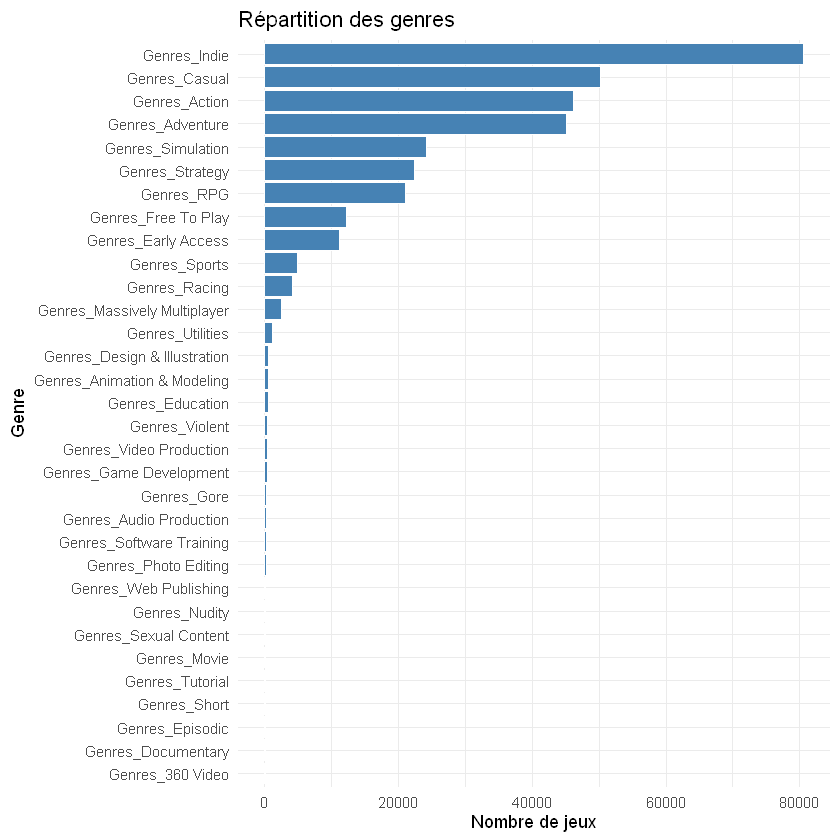

In [42]:
nbr_genre=df_genres %>%
  summarise(across(everything(), sum)) %>%
  pivot_longer(everything(), names_to = "Genre", values_to = "Nombre")

ggplot(nbr_genre,aes(x =reorder(Genre, Nombre) , y = Nombre)) +
  geom_col(fill = "steelblue", color = "white") +
  coord_flip() +
  theme_minimal() +
  labs(
    title = "Répartition des genres",
    x = "Genre",
    y = "Nombre de jeux"
  )

Cet histogramme nous permet de se rendre compte de deux choses: il y a majorité de genre qui ne concentrent la plupart des individus (jeux) avec en tête le Genre Indépendant (Indie). En revanche on se rend aussi compte de la présence de genre niche qui ne sont que très peu représentés.

Nous avions initialement réalisé une MCA (Multiple Correspondence Analysis) sur l'ensemble des variables qualitatives pour voir si un ou plusieurs genres soient corrélés avec modalité d'une autre variable. Cependant, nous avons remarqué que la faible fréquence de certains genres biaisait nos axes factoriels. Pour corriger cela, nous avons isolé les genres pour leur appliquer une MCA dédiée, puis nous avons regroupé les catégories similaires via une CAH (Classification Ascendante Hiérarchique). Ce processus nous a permis d'obtenir des macro-genres regroupant plusieurs genre afin de rendre notre analyse plus pertinente et d'arriver à des conclusions plus intéressantes.

## MCA sur les genres de jeu vidéos

In [45]:
df_genres<-df_one_hot %>% select(-c(1:27)) 
head(df_genres)

,Genres_Accounting,Genres_Animation & Modeling,Genres_Audio Production,Genres_Design & Illustration,Genres_Education,Genres_Photo Editing,Genres_Software Training,Genres_Utilities,Genres_Video Production,Genres_Web Publishing,⋯,Genres_Movie,Genres_Documentary,Genres_Episodic,Genres_Short,Genres_Tutorial,Genres_360 Video,Genres_Gore,Genres_Nudity,Genres_Violent,Genres_Sexual Content
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0


In [47]:
df_genres_mca <- df_genres %>%
  mutate(across(everything(), as.factor))

  summary(df_genres_mca)

 Genres_Accounting Genres_Animation & Modeling Genres_Audio Production
 0:114483          0:114036                    0:114288               
 1:    30          1:   477                    1:   225               
 Genres_Design & Illustration Genres_Education Genres_Photo Editing
 0:113933                     0:114052         0:114333            
 1:   580                     1:   461         1:   180            
 Genres_Software Training Genres_Utilities Genres_Video Production
 0:114294                 0:113436         0:114175               
 1:   219                 1:  1077         1:   338               
 Genres_Web Publishing Genres_Game Development Genres_Early Access
 0:114401              0:114193                0:103422           
 1:   112              1:   320                1: 11091           
 Genres_Action Genres_Adventure Genres_Casual Genres_Free To Play Genres_Indie
 0:68358       0:69409          0:64321       0:102353            0:33903     
 1:46155       1:45104 

In [48]:
res.mca_genres <- MCA(df_genres_mca, graph = FALSE)

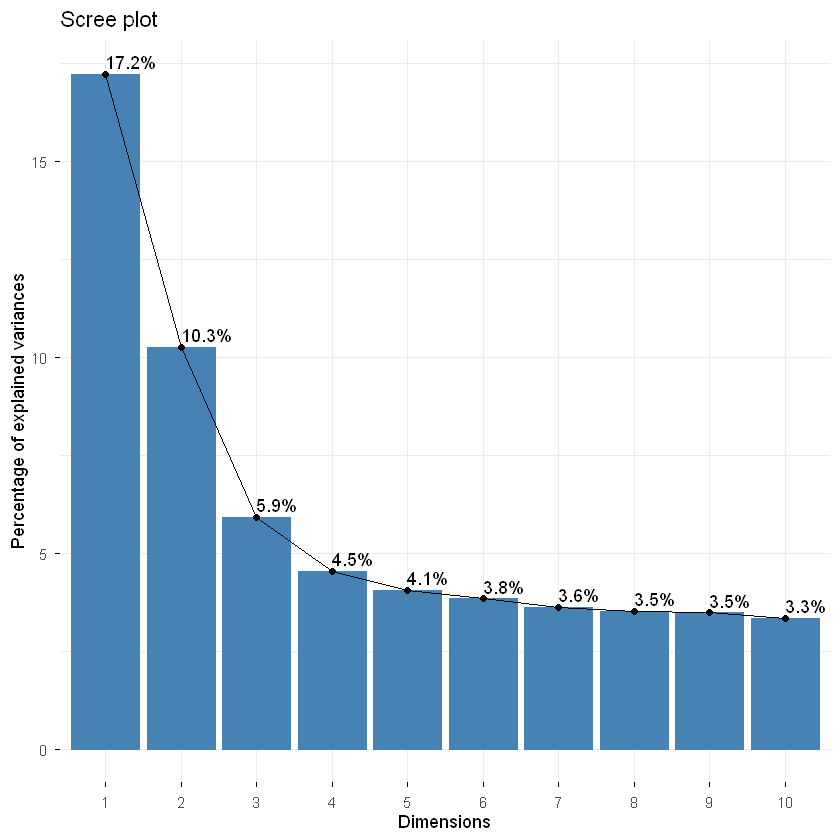

In [49]:
fviz_screeplot(res.mca_genres, addlabels=TRUE)

Les résultats de notre MCA sont intéressant les premiers axes principaux contiennent beaucoup d'informations, Le premier axe 17.2% de la variance expliquée, 10.3% pour la deuxième composante. A partir de la 4ieme composante principale on remarque un plateau on remarque donc un net coude à cet endroit là. On a donc décidé d'étudier nos genres à l'aide des 4 premiers axes de la MCA. 

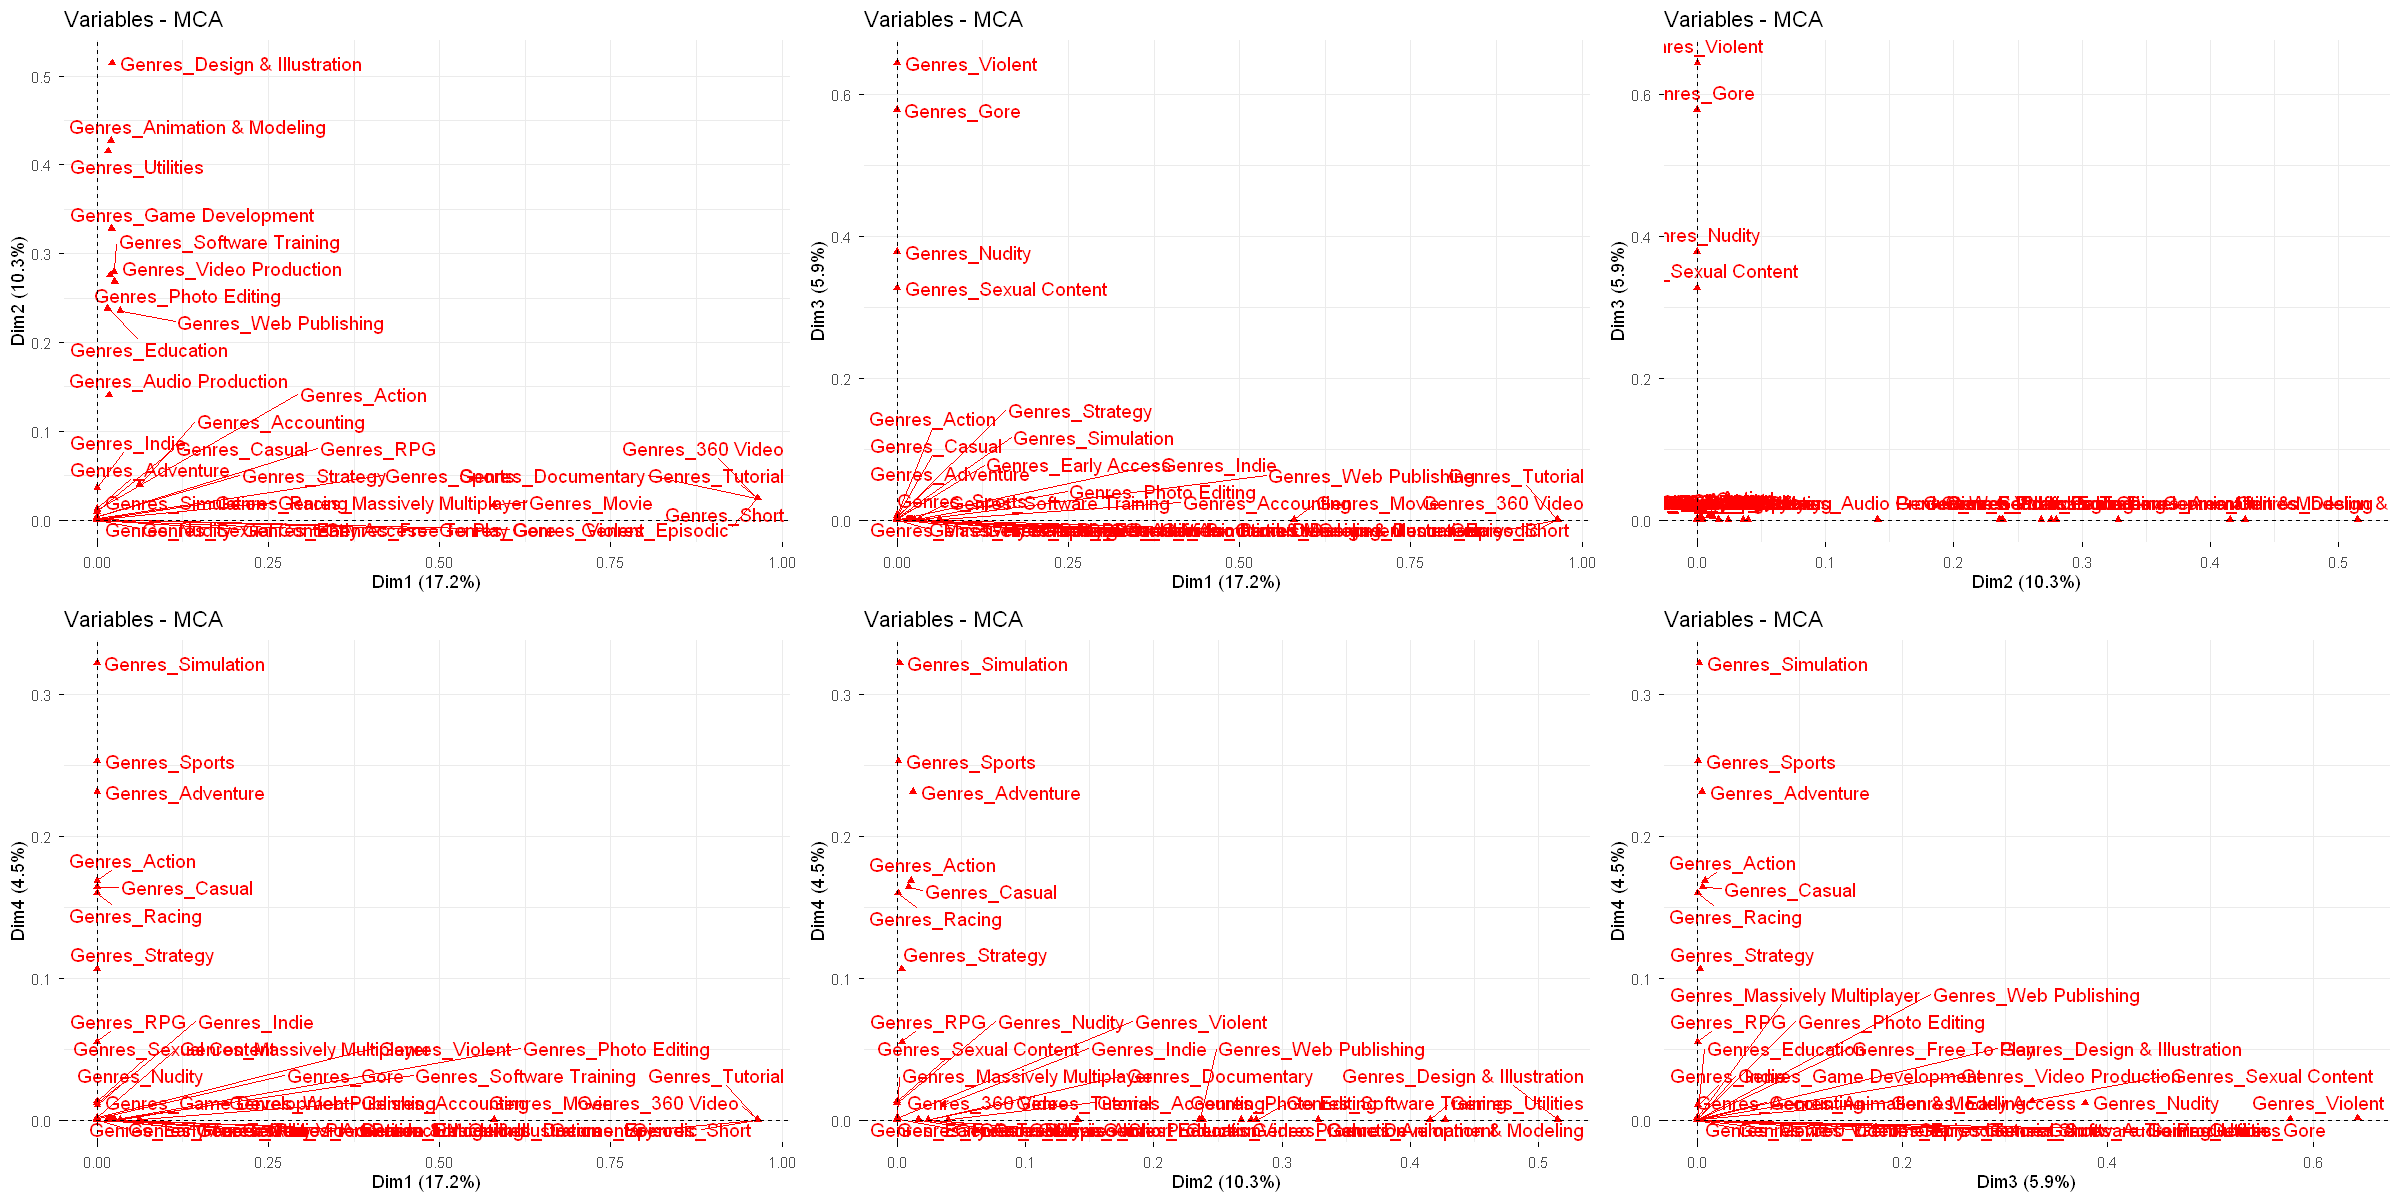

In [57]:
  options(repr.plot.width = 20, repr.plot.height = 10)
g1=fviz_mca_var(res.mca_genres,axes = c(1,2),repel=T,choice = "mca.cor")
g2=fviz_mca_var(res.mca_genres,axes = c(1,3),repel=TRUE,choice = "mca.cor")
g3=fviz_mca_var(res.mca_genres,axes = c(2,3),repel=F,choice = "mca.cor")
g4=fviz_mca_var(res.mca_genres,axes = c(1,4),repel=TRUE,choice = "mca.cor")
g5=fviz_mca_var(res.mca_genres,axes = c(2,4),repel=TRUE,choice = "mca.cor")
g6=fviz_mca_var(res.mca_genres,axes = c(3,4),repel=TRUE,choice = "mca.cor")

grid.arrange(g1,g2,g3,g4,g5,g6,ncol=3)

Sur ces représentations, on peut noter plusieurs choses:
- L'axe 1 semble être expliqué par des genre pour réaliser des vidéos comme *Tutorial*, *360.Video* etc... Ce qui regroupe un type d'applications qui partageraient les mêmes genres.
- On retrouve également  une agglomération de genres au niveau de l'axe 2, en effet, on retrouve plutôt des logiciels de création plutôt que des jeu vidéos.
- Sur l'axe 3 on retrouve un net écart entre des genres dits "mature" comme *Violent*, *Gore*, *Sexual* content ou encore *Nudity*. Ce qui pourra nous être utile pour les regrouper.
- Et enfin sur l'axe 4, expliqué seulement par 4.5% de la variance, on retrouve tous les genres plus "traditionnels" assez mélangé ce qui nous permet d'en déduire que nous ne pouvons pas forcément isoler d'autres groupes de genres ensemble.


Pour confirmer ce que nous venons d'affirmer on peut se pencher sur la contribution aux axes de chaque variable. Nous pouvons l'observer grâce aux histogrammes de la fonction *fviz_contrib* ou à la fonction *dimdesc*  qui classe les variables qui expliquent le mieux chaque axe en se basant sur un score statistique (la p-value) : plus ce score est petit, plus le lien entre la variable et l'axe est solide et fiable. C'est ce qui est fait dans les cellules suivantes pour les quatre premiers axes de la MCA.


In [51]:
explication_axe1 <- dimdesc(res.mca_genres, axes = 1)
explication_axe2 <- dimdesc(res.mca_genres, axes = 2)
explication_axe3 <- dimdesc(res.mca_genres, axes = 3)
explication_axe4 <- dimdesc(res.mca_genres, axes = 4)

L'Estimate indique la position et l'influence de la catégorie sur l'axe : une valeur élevée traduit une forte caractérisation de l'axe par ce genre. La **p.value**, quant à elle, confirme la solidité statistique de ce lien ; toutes les catégories retenues ici présentent une p.value proche de zéro, garantissant que ces regroupements ne sont pas dus au hasard.

Axe1

,Estimate,p.value
Genres_360 Video=Genres_360 Video_1,68.961312433,0.000000e+00
Genres_Tutorial=Genres_Tutorial_1,68.961312433,0.000000e+00
Genres_Short=Genres_Short_1,68.961312433,0.000000e+00
Genres_Episodic=Genres_Episodic_1,68.961312433,0.000000e+00
Genres_Documentary=Genres_Documentary_1,68.961312433,0.000000e+00
Genres_Movie=Genres_Movie_1,37.803666279,0.000000e+00
Genres_Game Development=Genres_Game Development_1,0.573892943,0.000000e+00
Genres_Web Publishing=Genres_Web Publishing_1,1.222616296,0.000000e+00
Genres_Video Production=Genres_Video Production_1,0.528136939,0.000000e+00
Genres_Utilities=Genres_Utilities_1,0.271622451,0.000000e+00


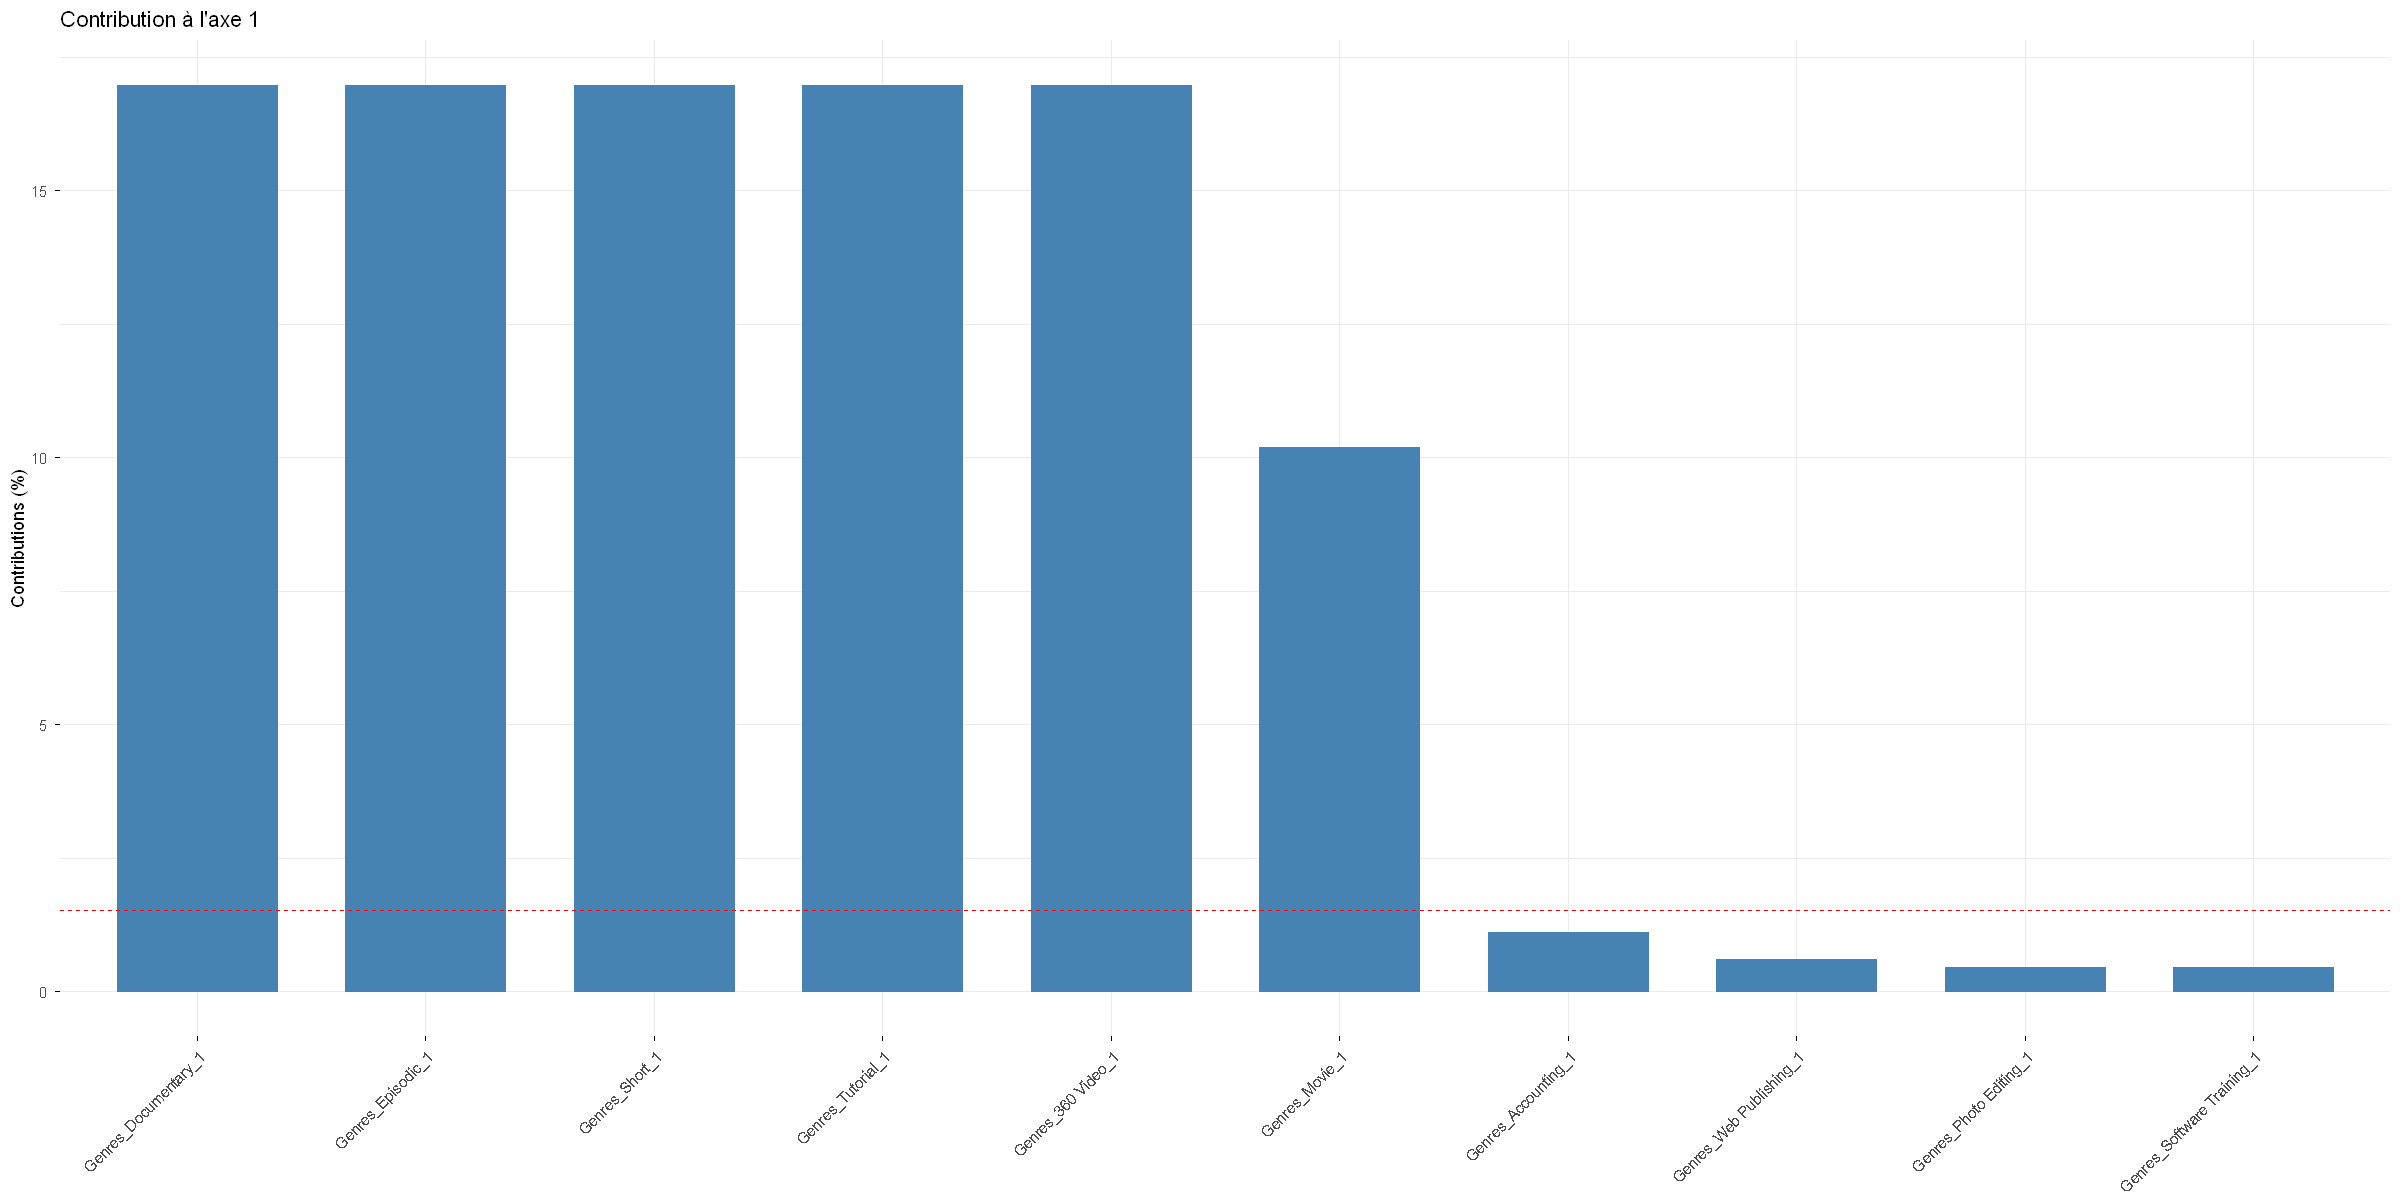

In [52]:
explication_axe1[[1]]$category

fviz_contrib(res.mca_genres,choice = "var",axes = 1,top=10,title ="Contribution à l'axe 1")

Axe2

,Estimate,p.value
Genres_360 Video=Genres_360 Video_0,8.442705926,0.000000e+00
Genres_Tutorial=Genres_Tutorial_0,8.442705926,0.000000e+00
Genres_Short=Genres_Short_0,8.442705926,0.000000e+00
Genres_Episodic=Genres_Episodic_0,8.442705926,0.000000e+00
Genres_Documentary=Genres_Documentary_0,8.442705926,0.000000e+00
Genres_Movie=Genres_Movie_0,4.982914956,0.000000e+00
Genres_Indie=Genres_Indie_0,0.066586686,0.000000e+00
Genres_Adventure=Genres_Adventure_0,0.036528468,1.918214e-313
Genres_Game Development=Genres_Game Development_1,1.737269770,0.000000e+00
Genres_Web Publishing=Genres_Web Publishing_1,2.486289956,0.000000e+00


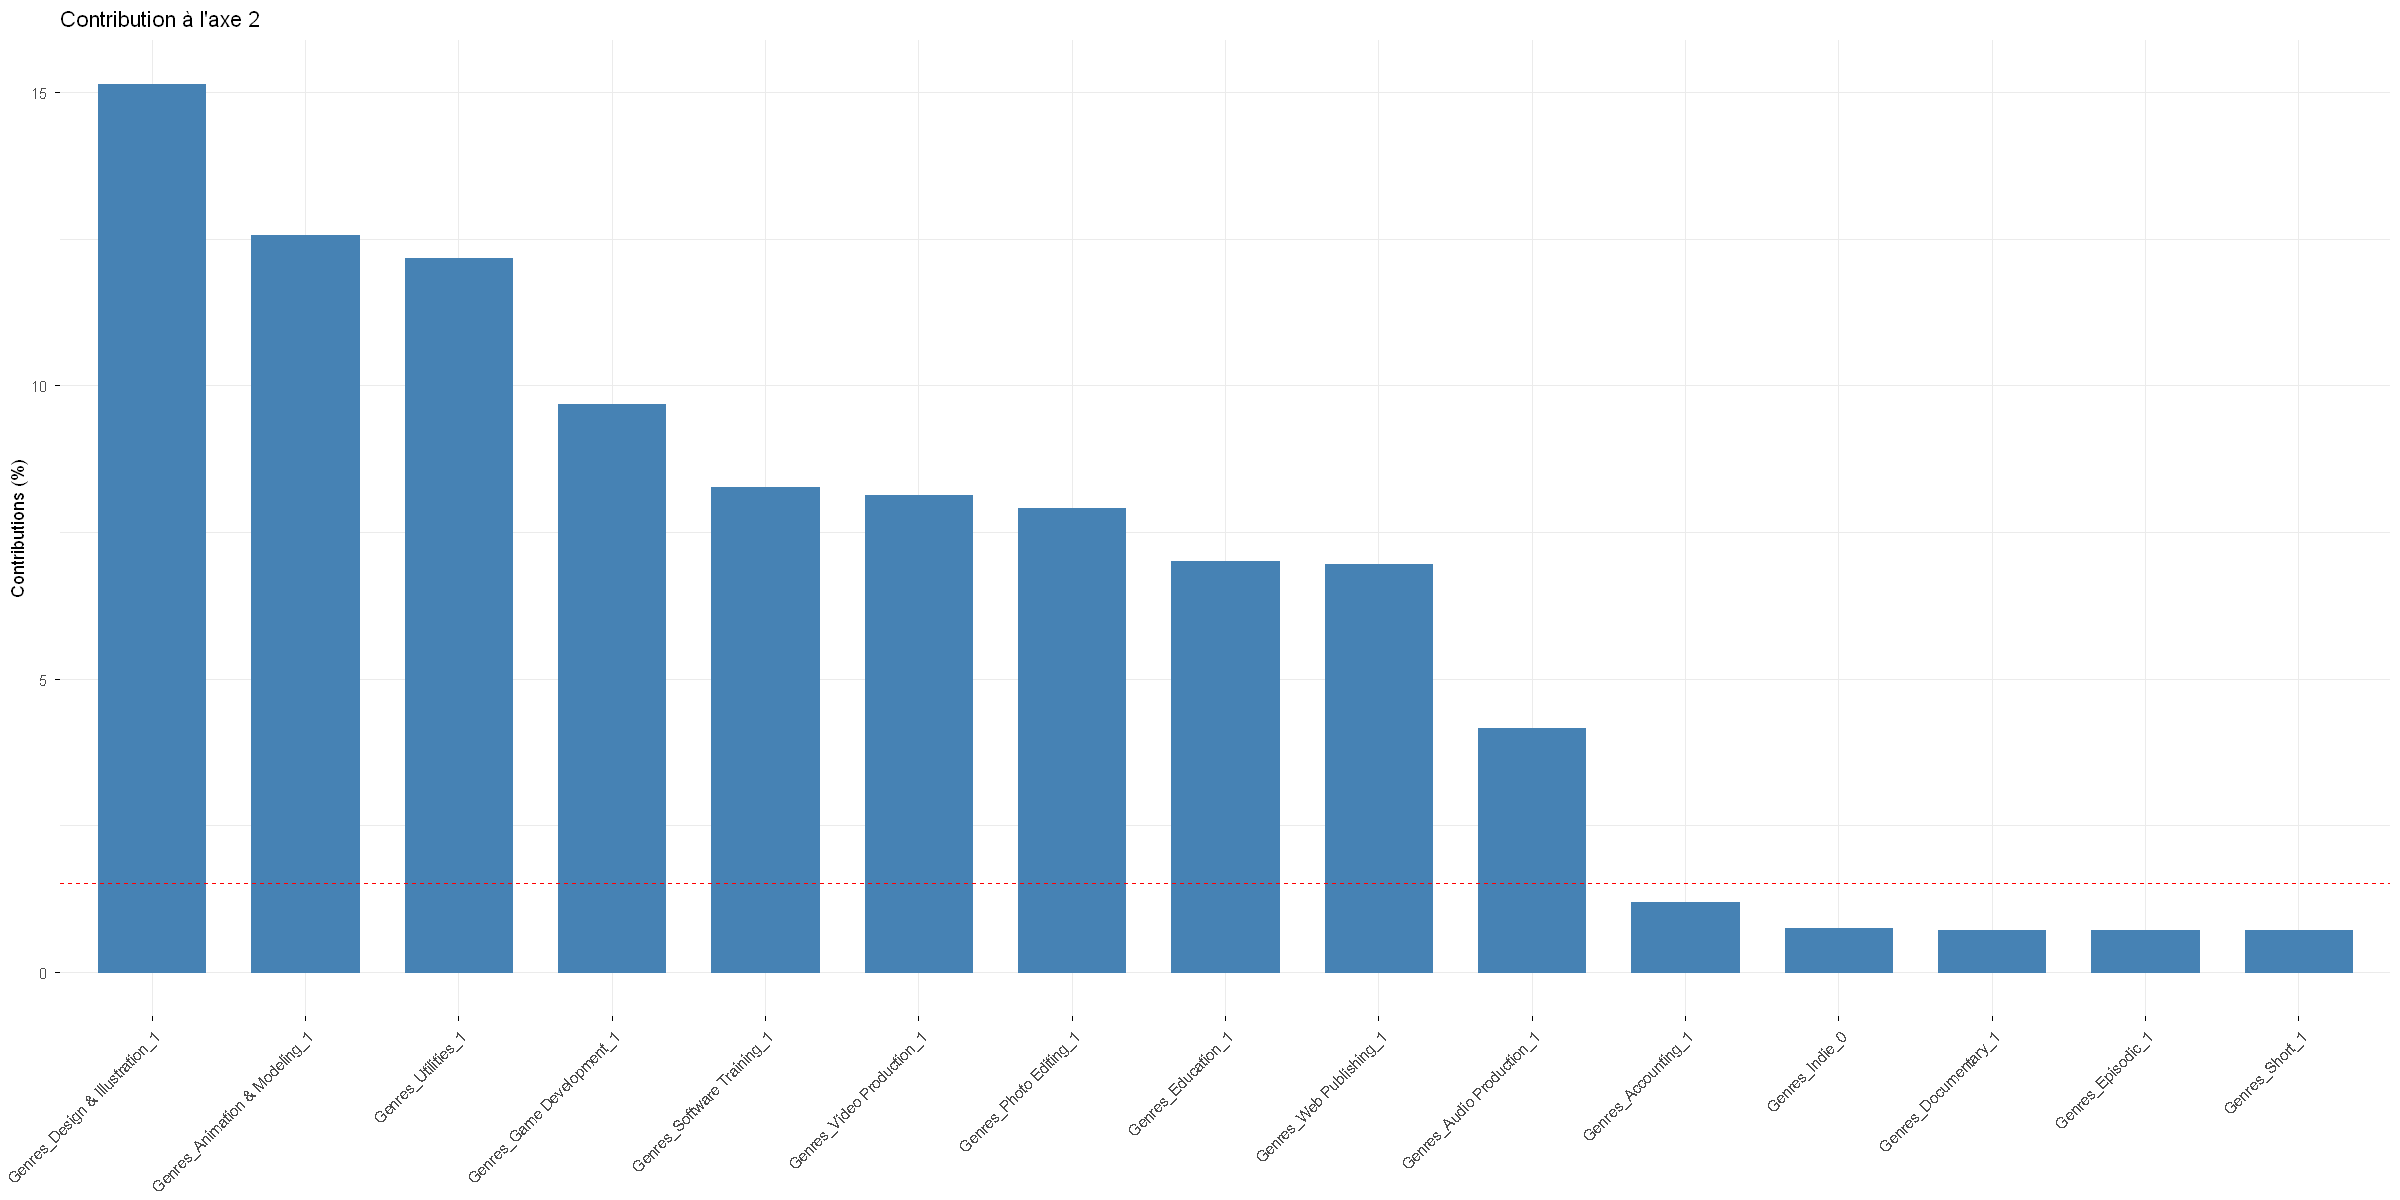

In [53]:
explication_axe2[[1]]$category

fviz_contrib(res.mca_genres,choice = "var",axes = 2,top=15,title ="Contribution à l'axe 2")

Axe3

,Estimate,p.value
Genres_Sexual Content=Genres_Sexual Content_1,2.508169985,0.000000e+00
Genres_Violent=Genres_Violent_1,1.627900363,0.000000e+00
Genres_Nudity=Genres_Nudity_1,2.610797126,0.000000e+00
Genres_Gore=Genres_Gore_1,1.957468659,0.000000e+00
Genres_Action=Genres_Action_1,0.021826046,1.223388e-195
Genres_Casual=Genres_Casual_0,0.018130244,1.416138e-138
Genres_Adventure=Genres_Adventure_1,0.017078499,1.793731e-119
Genres_Strategy=Genres_Strategy_0,0.016044624,3.514514e-70
Genres_Simulation=Genres_Simulation_0,0.013814081,2.420879e-55
Genres_Early Access=Genres_Early Access_1,0.015836955,7.817939e-39


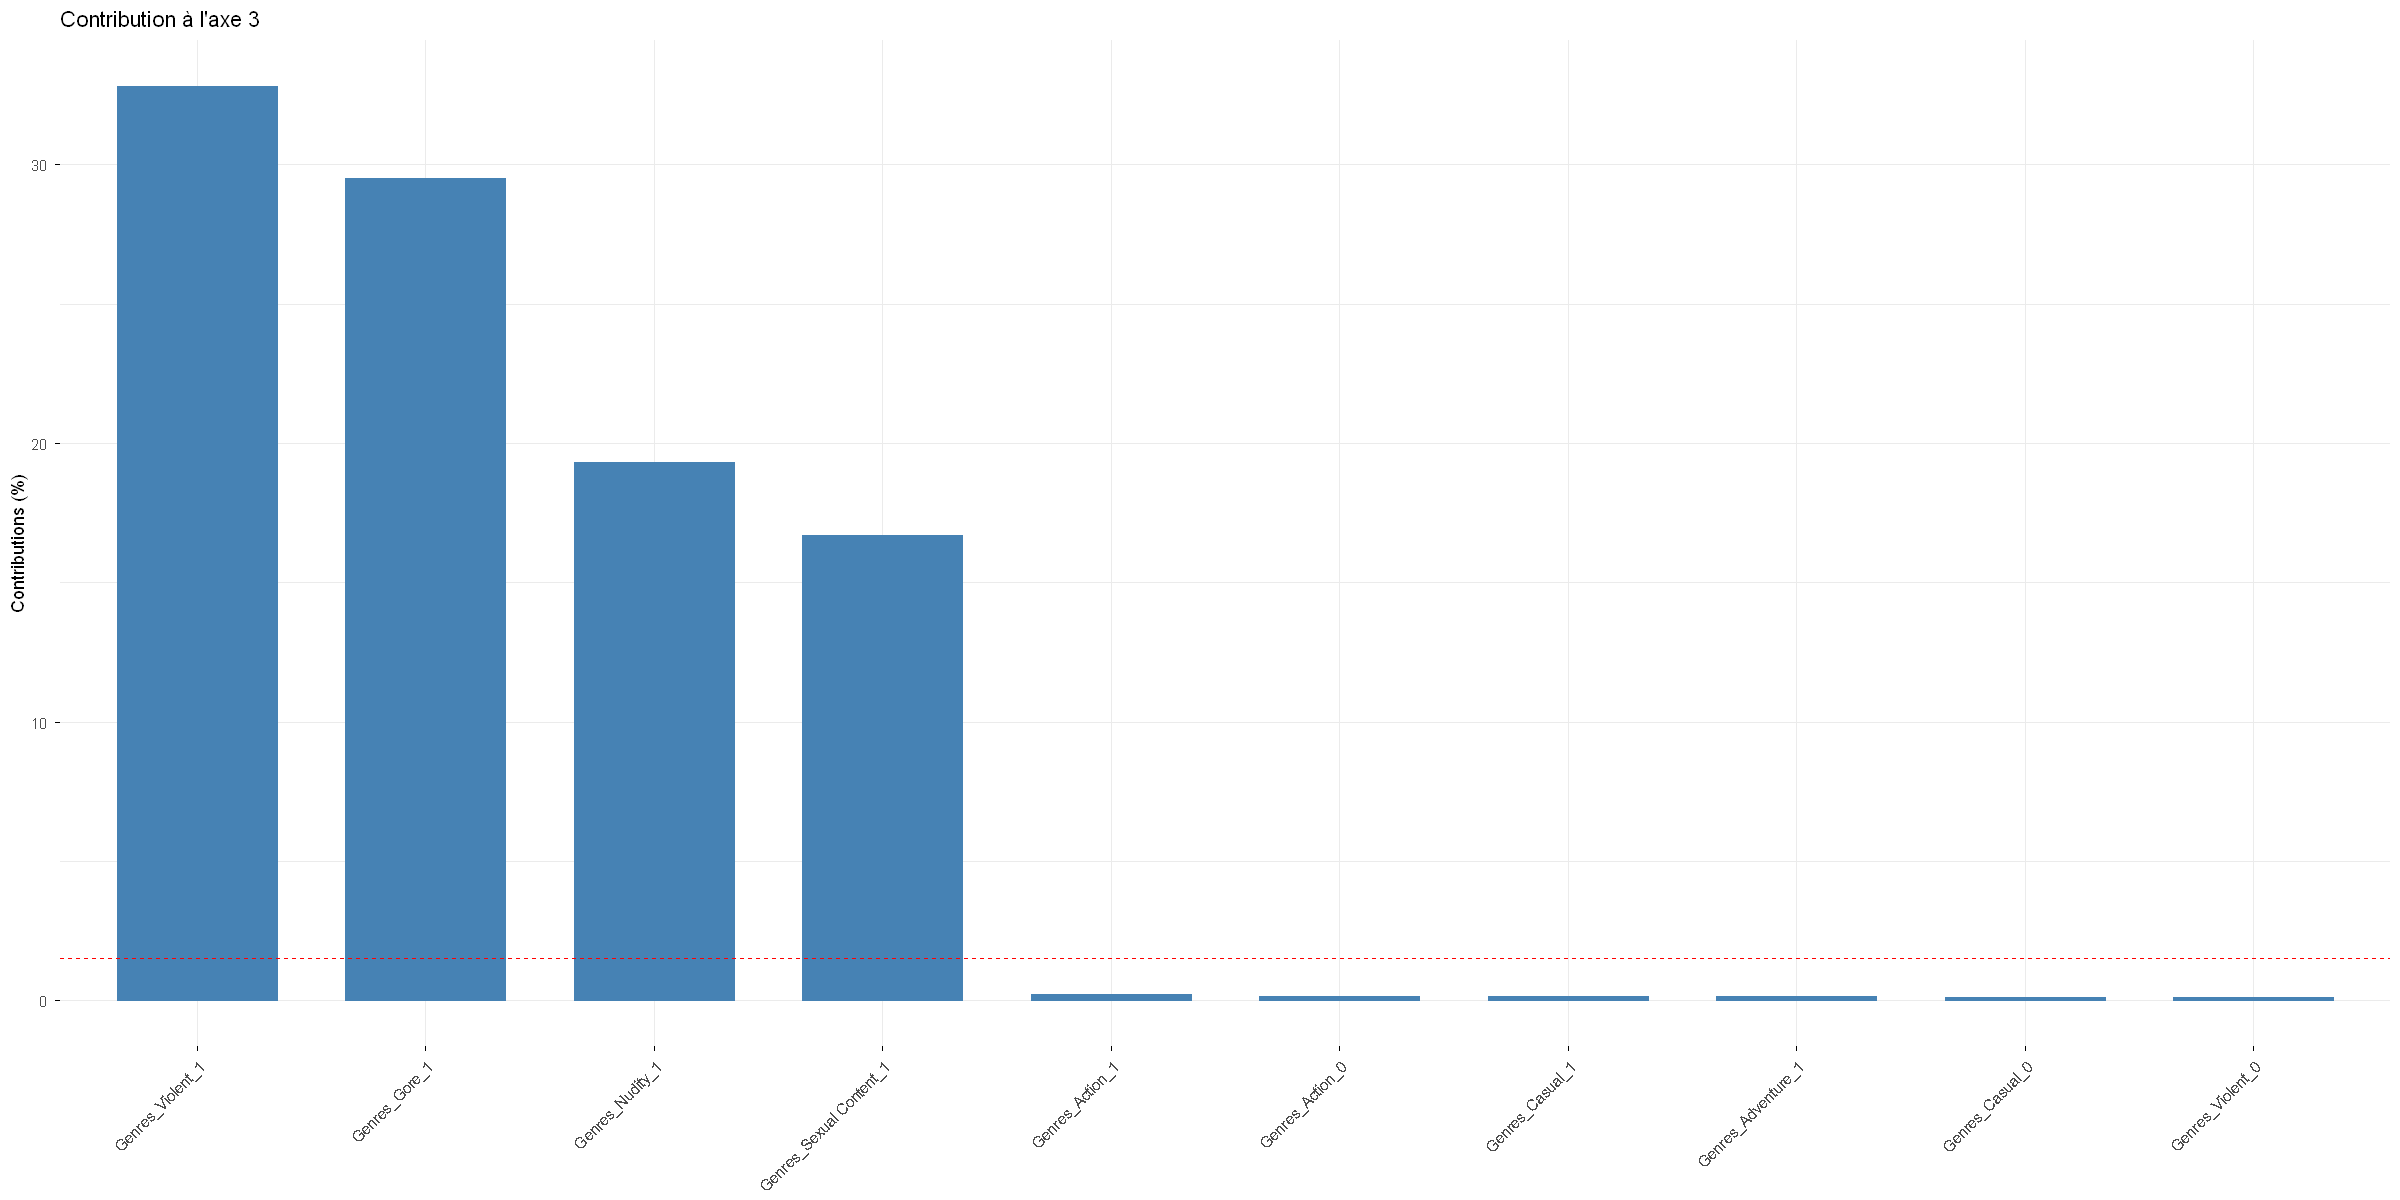

In [54]:
explication_axe3[[1]]$category

fviz_contrib(res.mca_genres,choice = "var",axes = 3,top=10,title ="Contribution à l'axe 3")

Axe4

,Estimate,p.value
Genres_Sexual Content=Genres_Sexual Content_1,0.440814549,0.000000e+00
Genres_Strategy=Genres_Strategy_1,0.087565987,0.000000e+00
Genres_Sports=Genres_Sports_1,0.265234632,0.000000e+00
Genres_Simulation=Genres_Simulation_1,0.148238279,0.000000e+00
Genres_RPG=Genres_RPG_0,0.064518218,0.000000e+00
Genres_Racing=Genres_Racing_1,0.229681003,0.000000e+00
Genres_Casual=Genres_Casual_1,0.086923308,0.000000e+00
Genres_Adventure=Genres_Adventure_0,0.104805651,0.000000e+00
Genres_Action=Genres_Action_0,0.089074870,0.000000e+00
Genres_Nudity=Genres_Nudity_1,0.403800093,2.902743e-297


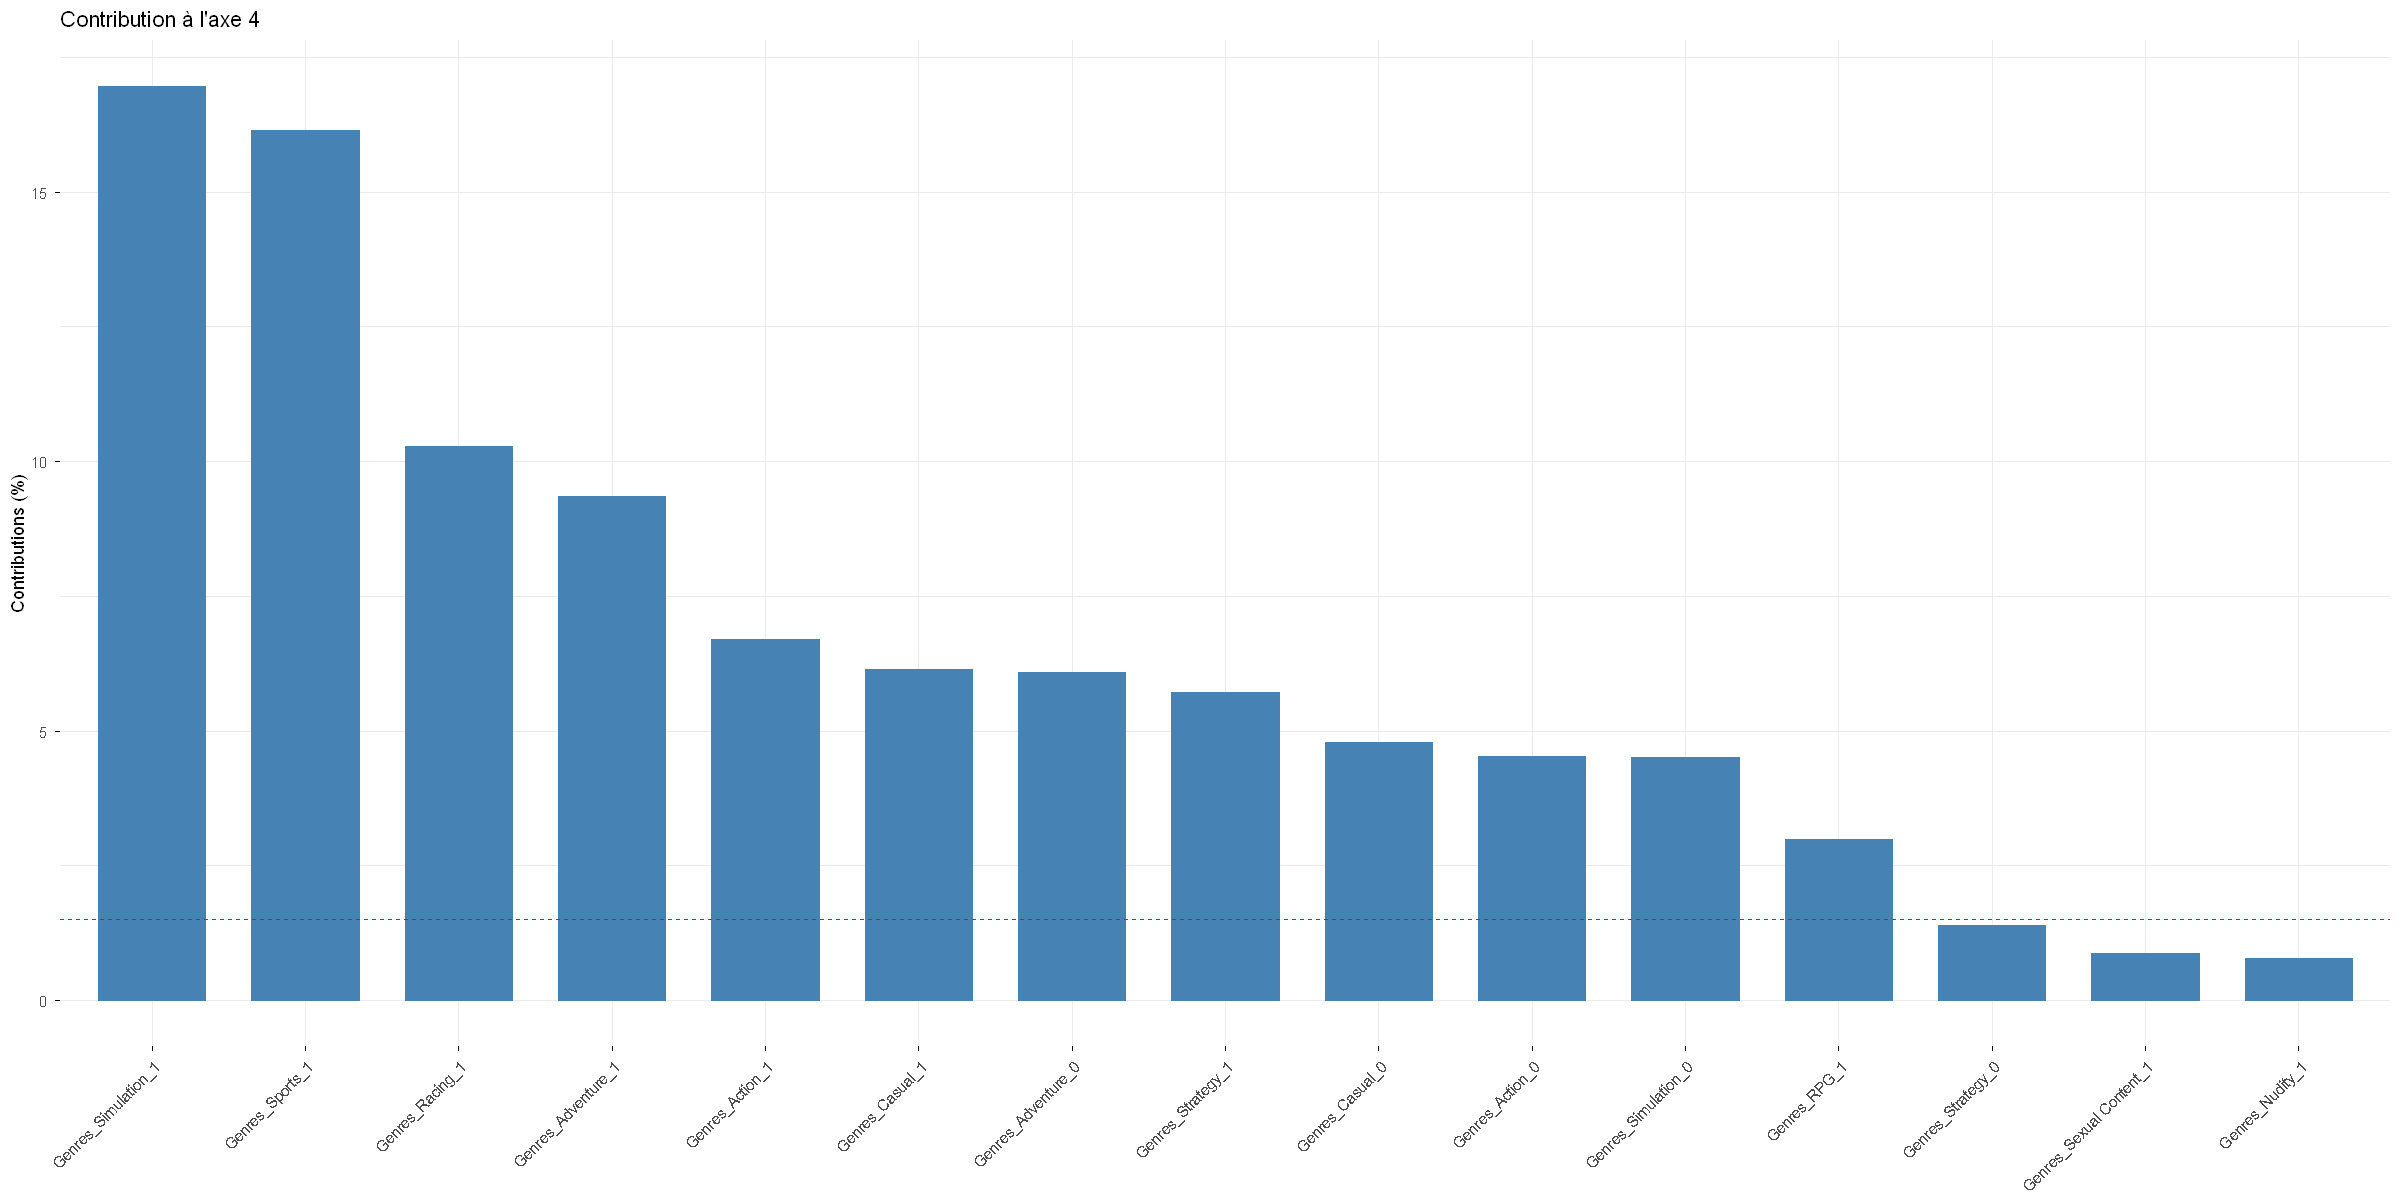

In [55]:
explication_axe4[[1]]$category

fviz_contrib(res.mca_genres,choice = "var",axes = 4,top=15,title ="Contribution à l'axe 4")

L'analyse des contributions valide nos précédentes observations graphiques. La principale précision apportée concerne la quatrième dimension de la MCA. Si cette tendance n'était que discrète visuellement, les contributions la confirment : bien que les coefficients soient faibles, cet axe s'avère pertinent car il oppose les jeux "techniques" ou "compétitifs" (comme *Simulation*, *Sports* ou *Racing*) aux jeux "narratifs" ou "d'action" (*Aventure*, *Action*).
Nous avons toutefois choisi de ne pas fusionner ces genres. D'une part, chacun d'eux possède déjà un volume d'individus suffisant. D'autre part, cette opposition n'apparaissant que sur le quatrième axe, elle constitue une tendance moins flagrante que les regroupements mis en évidence sur les premières dimensions.

Nous avons voulu confirmer nos choix de regroupement en faisant du clustering sur les coordonnées des genres sur l'espace MCA. C'est ce que nous réalisons dans la partie suivante. 

## Clustering CAH sur l'espace de MCA

On va réaliser le clustering ascendant hiérarchique sur les coordonnées de la MCA grâce à la fonction de *factomineR*: *HCPC*.


In [59]:
coord_genres <- res.mca_genres$var$coord[,1:4]
res.hcpc_vars <- HCPC(as.data.frame(coord_genres), nb.clust = -1, graph = FALSE)

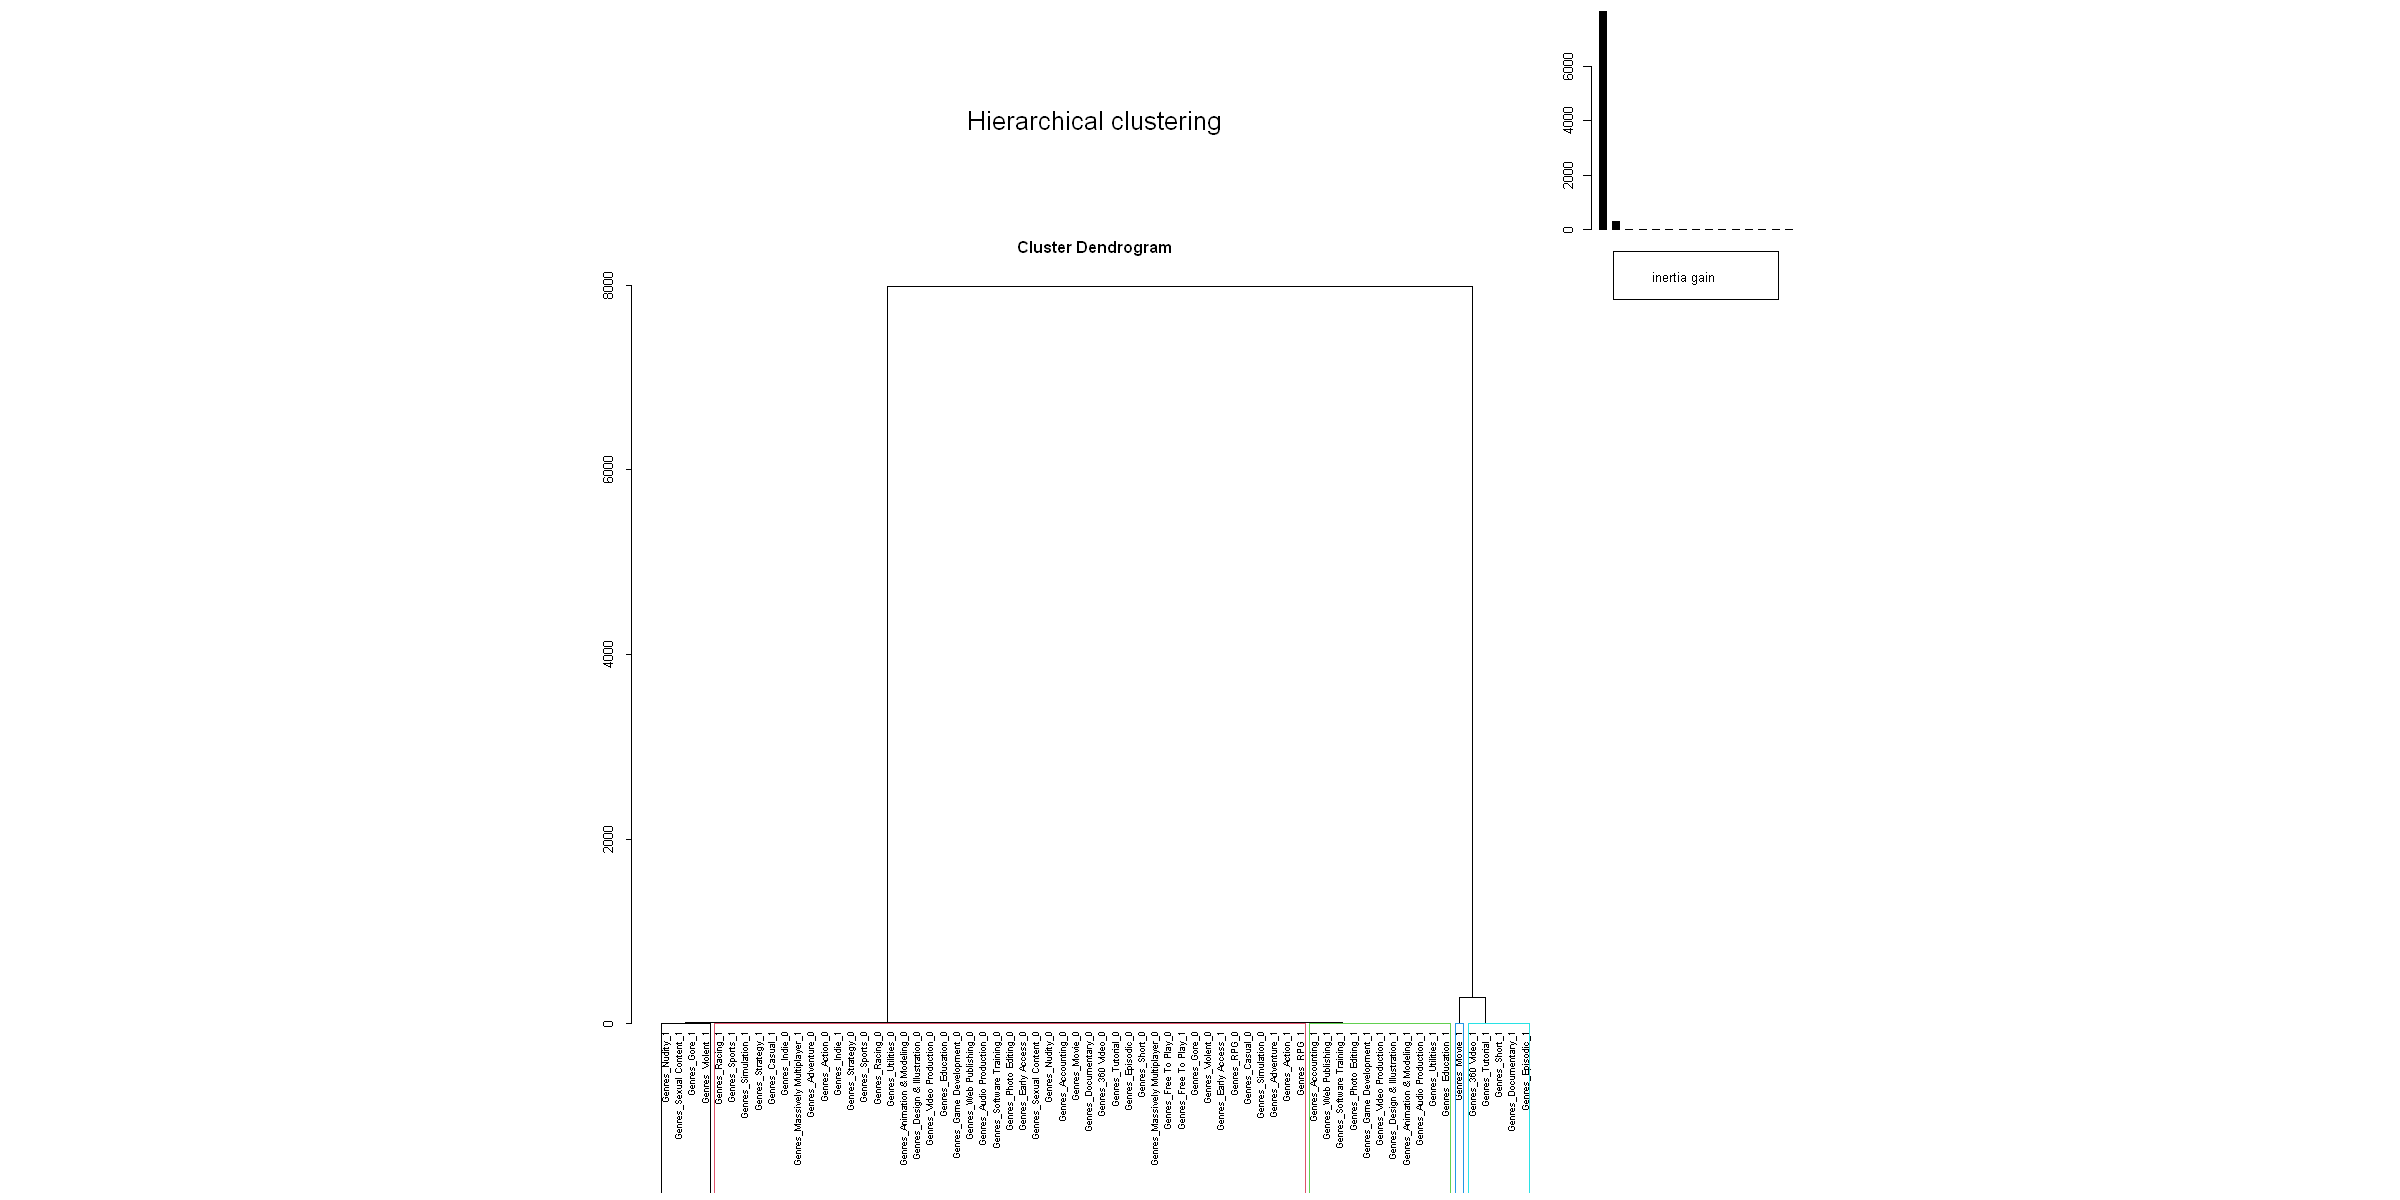

In [60]:
plot(res.hcpc_vars,choice = "tree",cex = 0.7,tcl = -0.3)

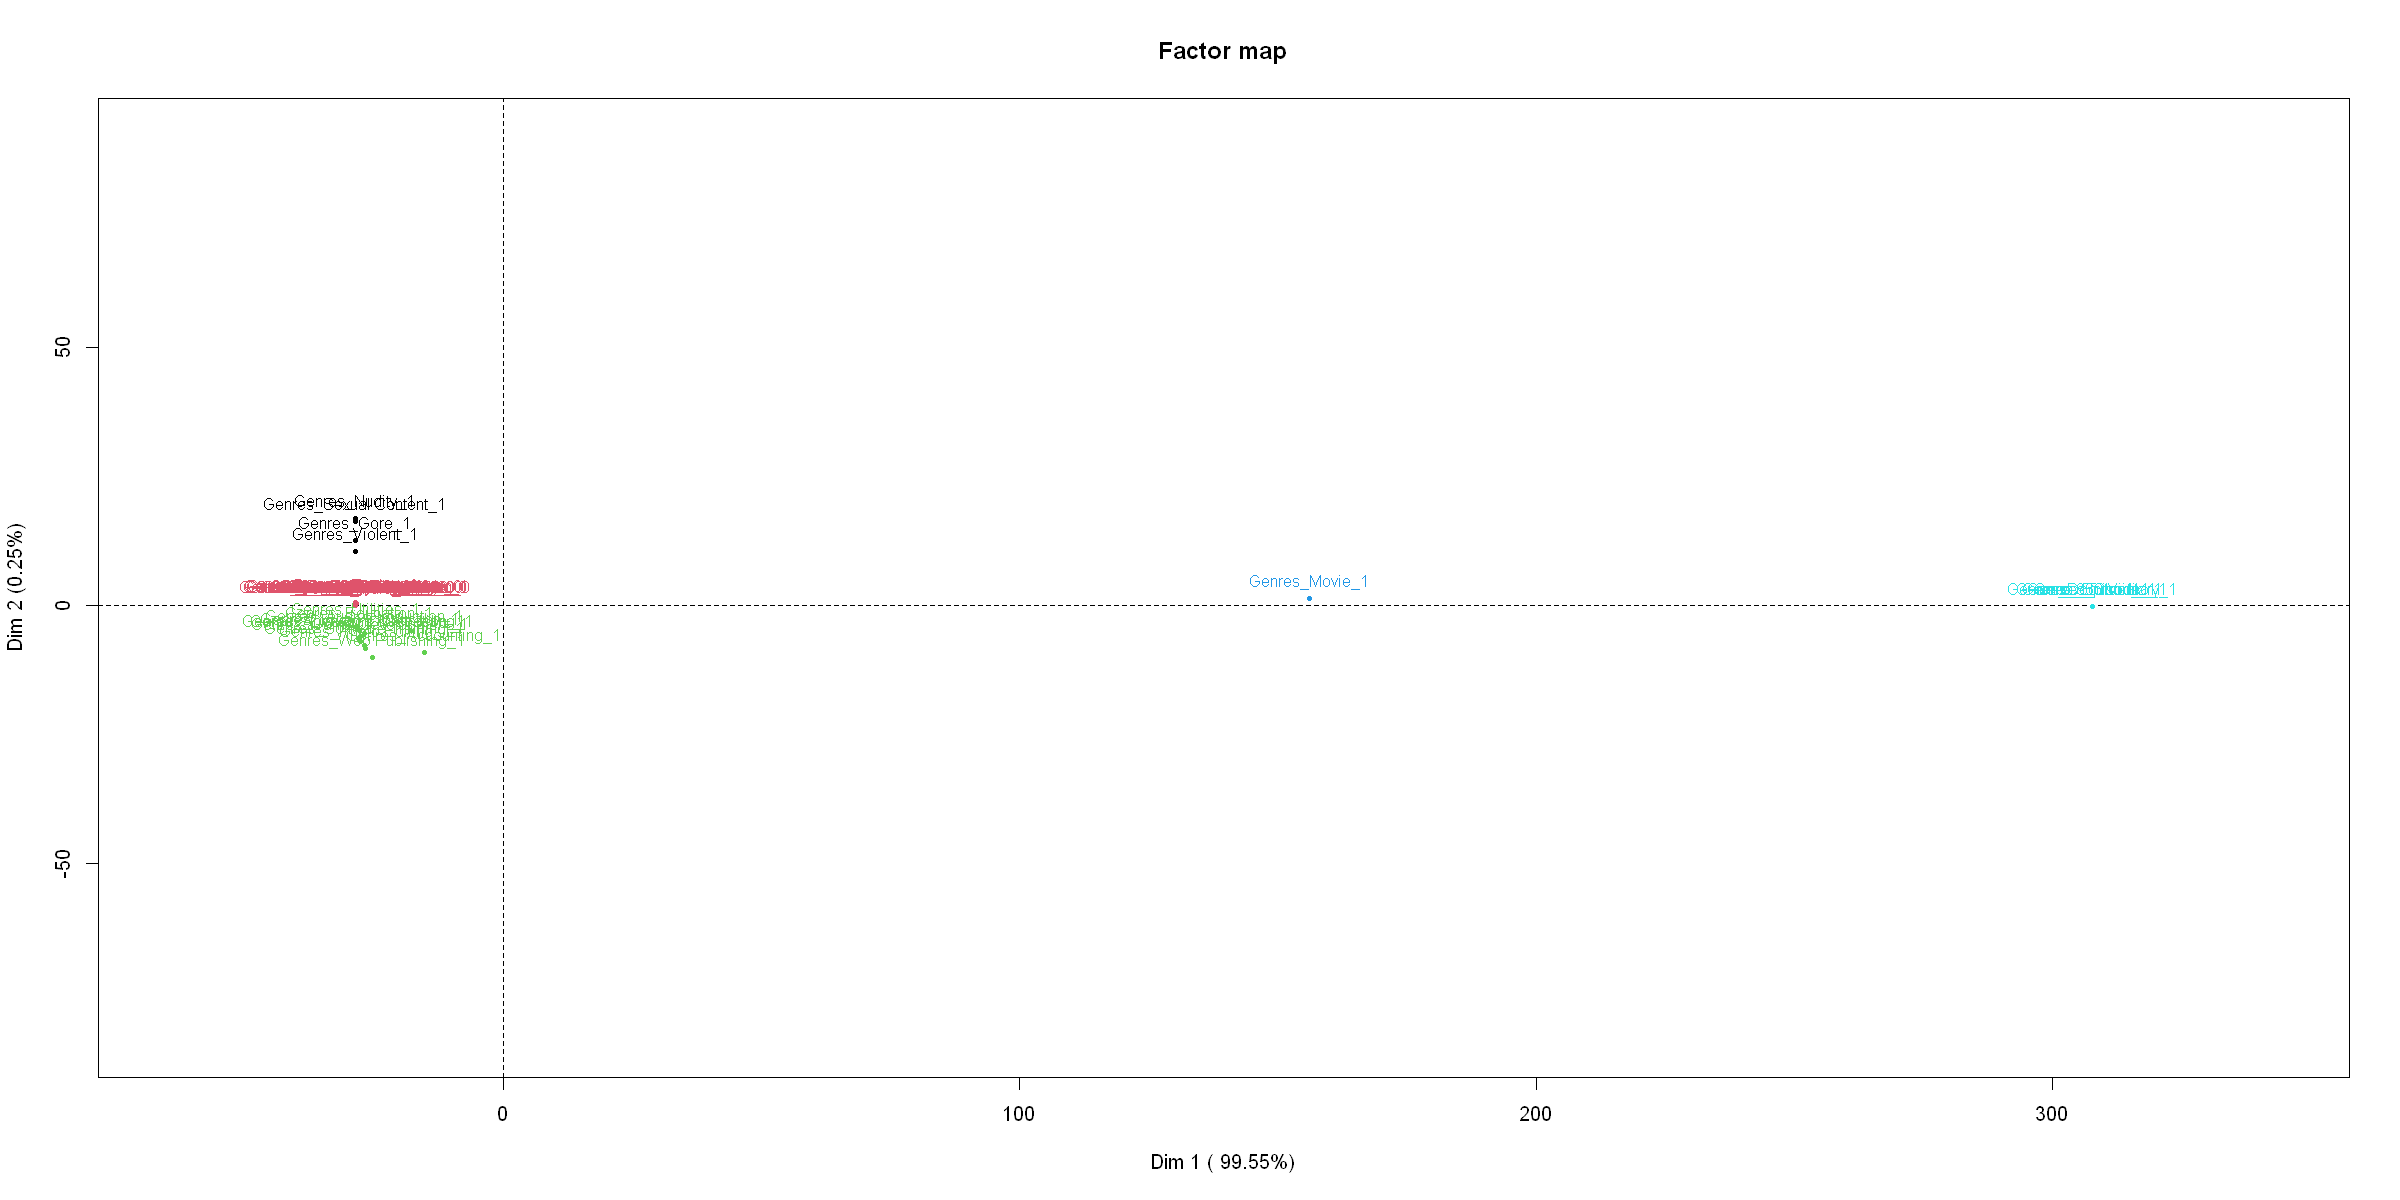

In [61]:
plot(res.hcpc_vars, choice = "map", draw.tree = FALSE)

On voit que la fontion *HCPC* a choisi  5 clusters dont un avec qu'un seul genre (Movie). On décide de le regrouper avec le groupe "Vidéo". Le reste des clusters représente ce que l'on a trouvé avec la MCA.

En résumé, la MCA et ce clustering a révélé que les genres ne sont pas des catégories isolées, mais des groupes liés par des similitudes. Nous avons en évidence trois pôles cohérents : les formats multimédias, les outils de création et les contenus adultes. Ces résultats justifient le regroupement de ces genres en trois nouveaux genres (Video, Outils et Mature). Cette simplification permet de réduire le nombre de variable de 33 à 15 genres.

### Création des nouveaux genres

In [62]:
df_final <- df_one_hot %>%
  mutate(
    # Création du genre "Mature"
    Genre_Mature = if_else(Genres_Gore == "1" |
                           Genres_Nudity == "1"|
                           `Genres_Sexual Content` == "1"|
                           Genres_Violent == "1", "1", "0"),
     # Création du genre "Video" 
     Genre_Video = if_else(Genres_Episodic == "1" |
                           Genres_Documentary == "1"|
                           Genres_Short == "1"|
                           Genres_Movie == "1"|
                           `Genres_360 Video` == "1"|
                           Genres_Tutorial == "1", "1", "0"),
    
    # Création du genre "Outils" 
    Genre_Outils = if_else( `Genres_Video Production` == "1" | 
                           `Genres_Design & Illustration` =="1"|
                           `Genres_Animation & Modeling` == "1" |
                           `Genres_Game Development` == "1"|
                           `Genres_Audio Production` == "1"|
                           `Genres_Photo Editing` == "1"|
                          `Genres_Software Training` == "1"|
                           Genres_Education == "1" |
                           Genres_Utilities == "1" |
                           `Genres_Web Publishing` == "1", "1", "0")
  ) %>%

  mutate(Genre_Mature = as.factor(Genre_Mature),
         Genre_Video = as.factor(Genre_Video),
        Genre_Outils = as.factor(Genre_Outils))


In [63]:
cols_to_remove <- c("Genres_Gore", "Genres_Violent", "Genres_Video Production","Genres_Sexual Content","Genres_Nudity", 
                    "Genres_Design & Illustration", "Genres_Animation & Modeling","Genres_Game Development", 
                    "Genres_Audio Production","Genres_Photo Editing", "Genres_Software Training", 
                    "Genres_Education", "Genres_Utilities", "Genres_Web Publishing","Genres_Episodic",
                   "Genres_Documentary","Genres_Short","Genres_Movie","Genres_360 Video","Genres_Tutorial")

df_mca_new <- df_final %>%
  select(-all_of(cols_to_remove))
summary(df_mca_new)

     Name              Release.date    Estimated.owners  Required.age   
 Length:114513      2025-2026:21812   0-20K    :75337   0      :113288  
 Class :character   2024     :18104   0        :13649   17     :   782  
 Mode  :character   2023     :13337   20K-50K  :11395   13     :   175  
                    2022     :11403   50K-100K : 5349   18     :   164  
                    2021     :10441   100K-200K: 3450   16     :    31  
                    2020     : 8746   200K-500K: 2845   10     :    26  
                    (Other)  :30670   (Other)  : 2488   (Other):    47  
    Discount       Windows          Mac          Linux       Metacritic.score
 Min.   :  0.00   False:    44   False:93260   False:98841   Min.   : 0.000  
 1st Qu.:  0.00   True :114469   True :21253   True :15672   1st Qu.: 0.000  
 Median :  0.00                                              Median : 0.000  
 Mean   : 19.62                                              Mean   : 2.703  
 3rd Qu.: 45.00           

In [85]:
df_mca_ready <- df_mca_new
df_mca_ready[,-c(1:27)] <- lapply(df_mca_new[,-c(1:27)], as.factor)

data_quali_new=df_mca_ready%>%
  select(where(is.factor)) 

In [86]:
summary(data_quali_new)

    Release.date    Estimated.owners  Required.age     Windows      
 2025-2026:21812   0-20K    :75337   0      :113288   False:    44  
 2024     :18104   0        :13649   17     :   782   True :114469  
 2023     :13337   20K-50K  :11395   13     :   175                 
 2022     :11403   50K-100K : 5349   18     :   164                 
 2021     :10441   100K-200K: 3450   16     :    31                 
 2020     : 8746   200K-500K: 2845   10     :    26                 
 (Other)  :30670   (Other)  : 2488   (Other):    47                 
    Mac          Linux       Genres_Accounting Genres_Early Access
 False:93260   False:98841   0:114483          0:103422           
 True :21253   True :15672   1:    30          1: 11091           
                                                                  
                                                                  
                                                                  
                                              

Même en réduisant le nombre de genres la MCA entre toutes les variables qualitatives reste très peu interprétable. C'est pour cela que nous avons etudié la relation entre les genres et les variables qualitatives une à une grâce à une CA (Correspondance Analysis).

## CA Genres-Realease.date

Pour cela, nous allons réaliser une table de contingence croisant les genres et les années de sortie. Initialement, nous avions mené cette analyse avec l'ensemble des genres. Cependant, la présence de catégories sous-représentées étirait nos axes factoriels, ce qui masquait les véritables relations sous-jacentes. Nous avons donc choisi de réaliser notre CA en excluant les genres *Mature*, *Video* et *Accounting*.

In [71]:
tab_contingence <- data_quali_new %>%
  group_by(Release.date) %>%
  summarise(across(starts_with("Genre"), 
                   ~ sum(as.numeric(as.character(.)), na.rm = TRUE))) %>%
  as.data.frame()

rownames(tab_contingence) <- tab_contingence$Release.date
tab_contingence$Release.date <- NULL

tab_filtre <- tab_contingence[, !(colnames(tab_contingence) %in% c("Genre_Mature", "Genre_Video", "Genres_Accounting")), drop = FALSE]

Pour savoir si les variables sont dépendantes et ainsi savoir si notre analyse par correspondance à du sens d'être fait nous réalisons un test d'indépendance du Khi-deux.

In [72]:
test_khi2 <- chisq.test(tab_filtre)
print(test_khi2)



	Pearson's Chi-squared test

data:  tab_filtre
X-squared = 3197.2, df = 144, p-value < 2.2e-16



On obtient une p-value $< 2.2 \times 10^{-16}$, ce qui indique que les genres et les dates de sortie sont statistiquement liés ; réaliser une CA est donc justifié. Avant de passer à la réduction de dimensions, nous pouvons étudier les résidus du test, ce qui nous donnera un avant-goût des résultats de la CA.

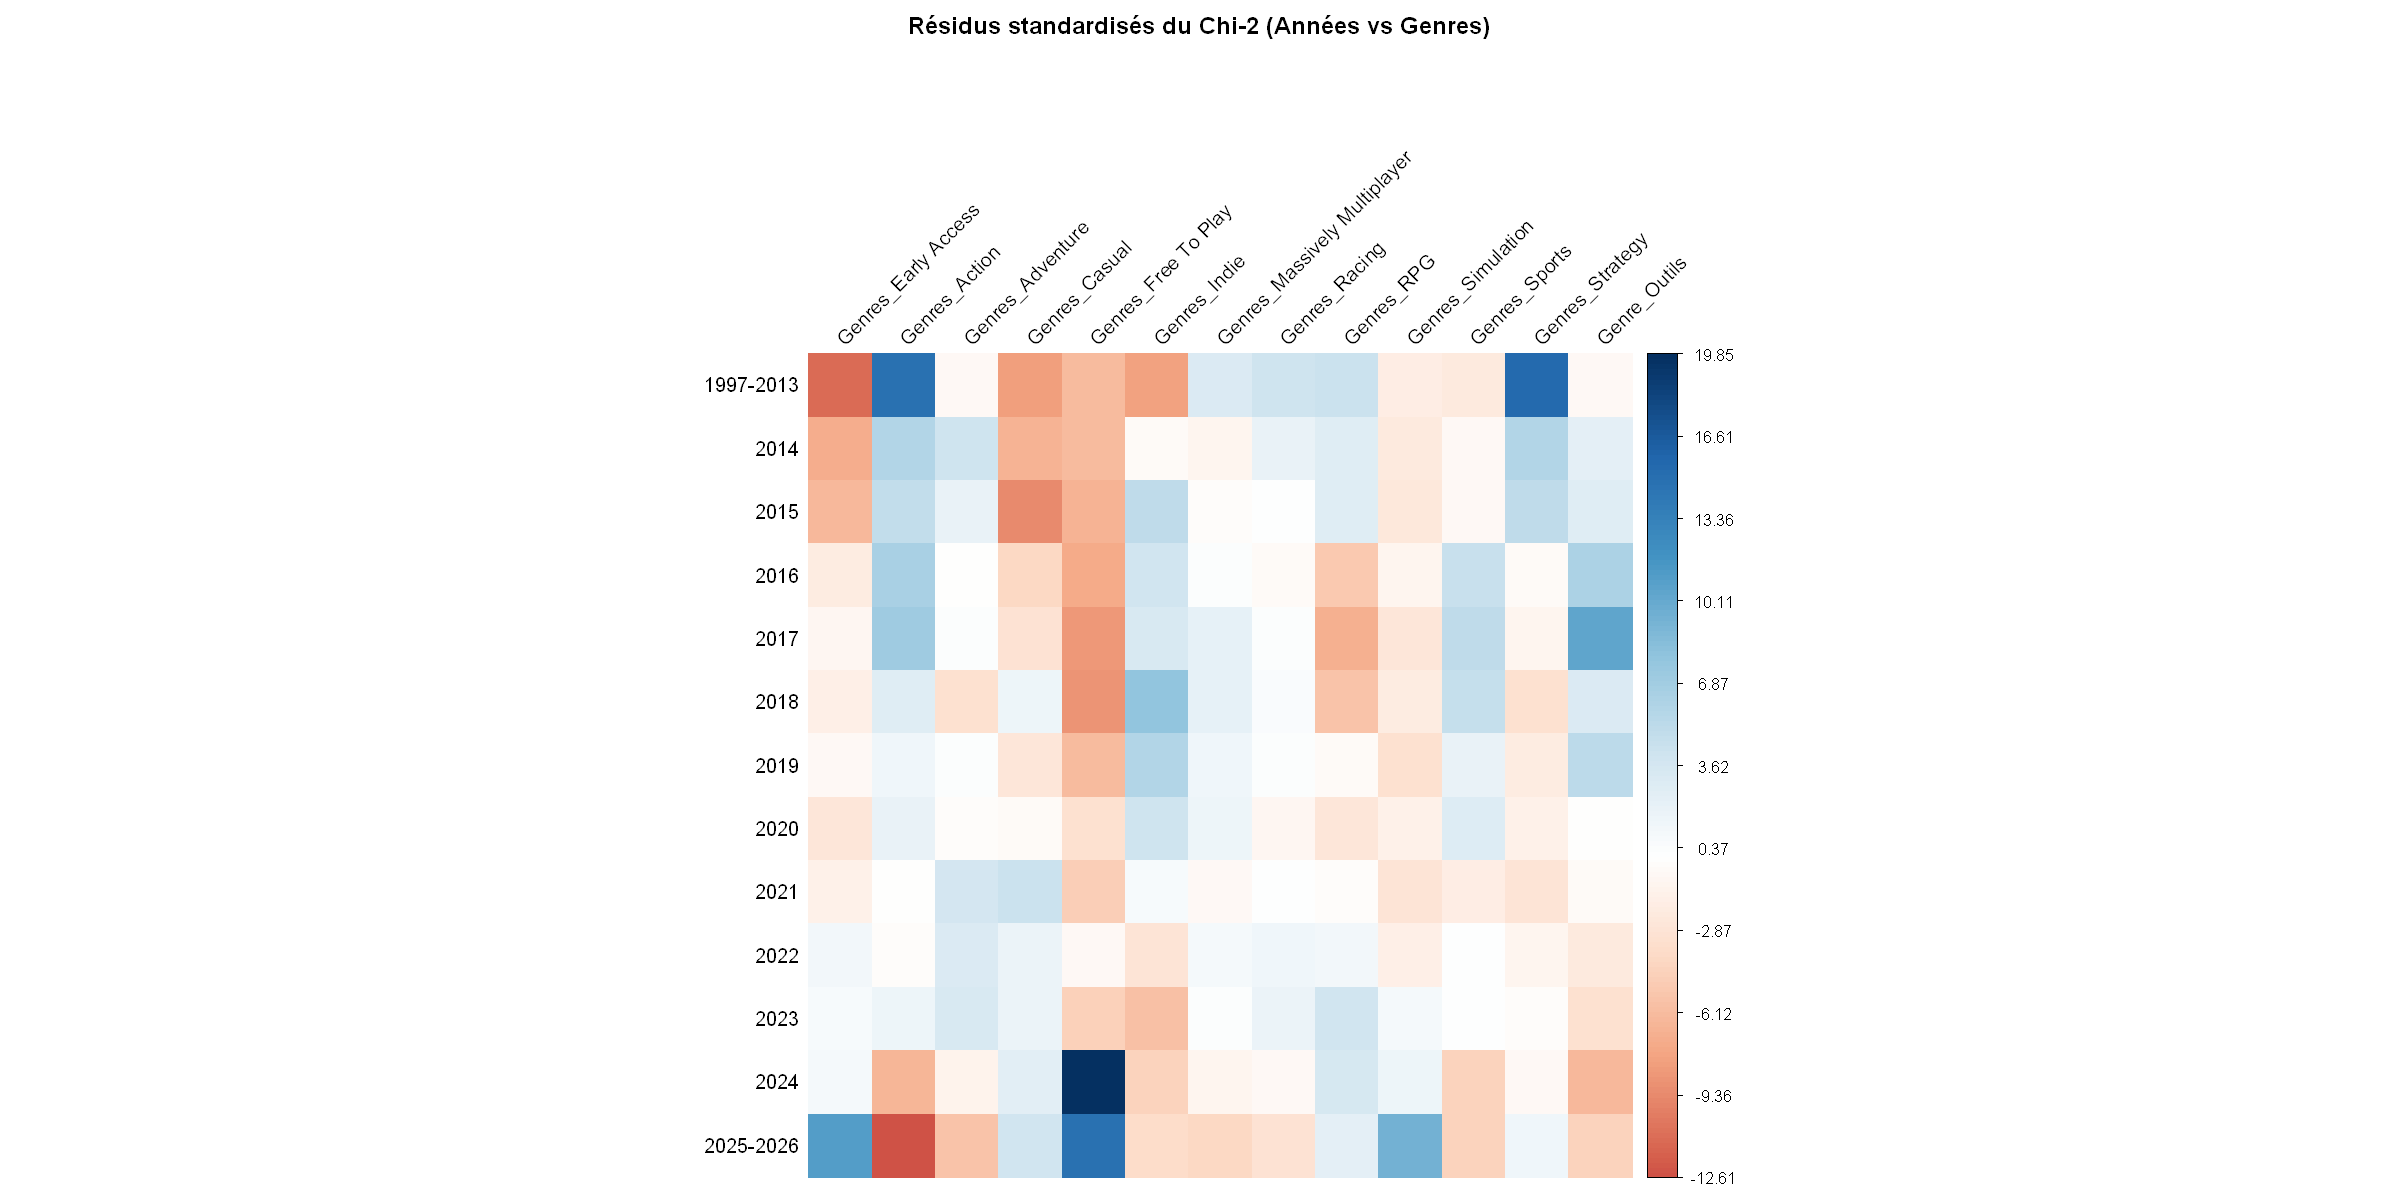

In [73]:
residus <- test_khi2$stdres
corrplot(residus, 
         is.cor = FALSE,method = "color",tl.srt = 45,tl.col = "black",mar = c(0,0,2,0),title = "Résidus standardisés du Chi-2 (Années vs Genres)")

Pour interpréter ces résidus, il faut regarder l'intensité des couleurs présentes. Plus la case est bleu foncé, plus l'association est positive (sur-représentation) et, inversement, plus la case est orange, plus la sous-représentation est marquée. Les conclusions sur les résidus sont détaillées dans la cellule Markdown suivante avec celles de la CA.

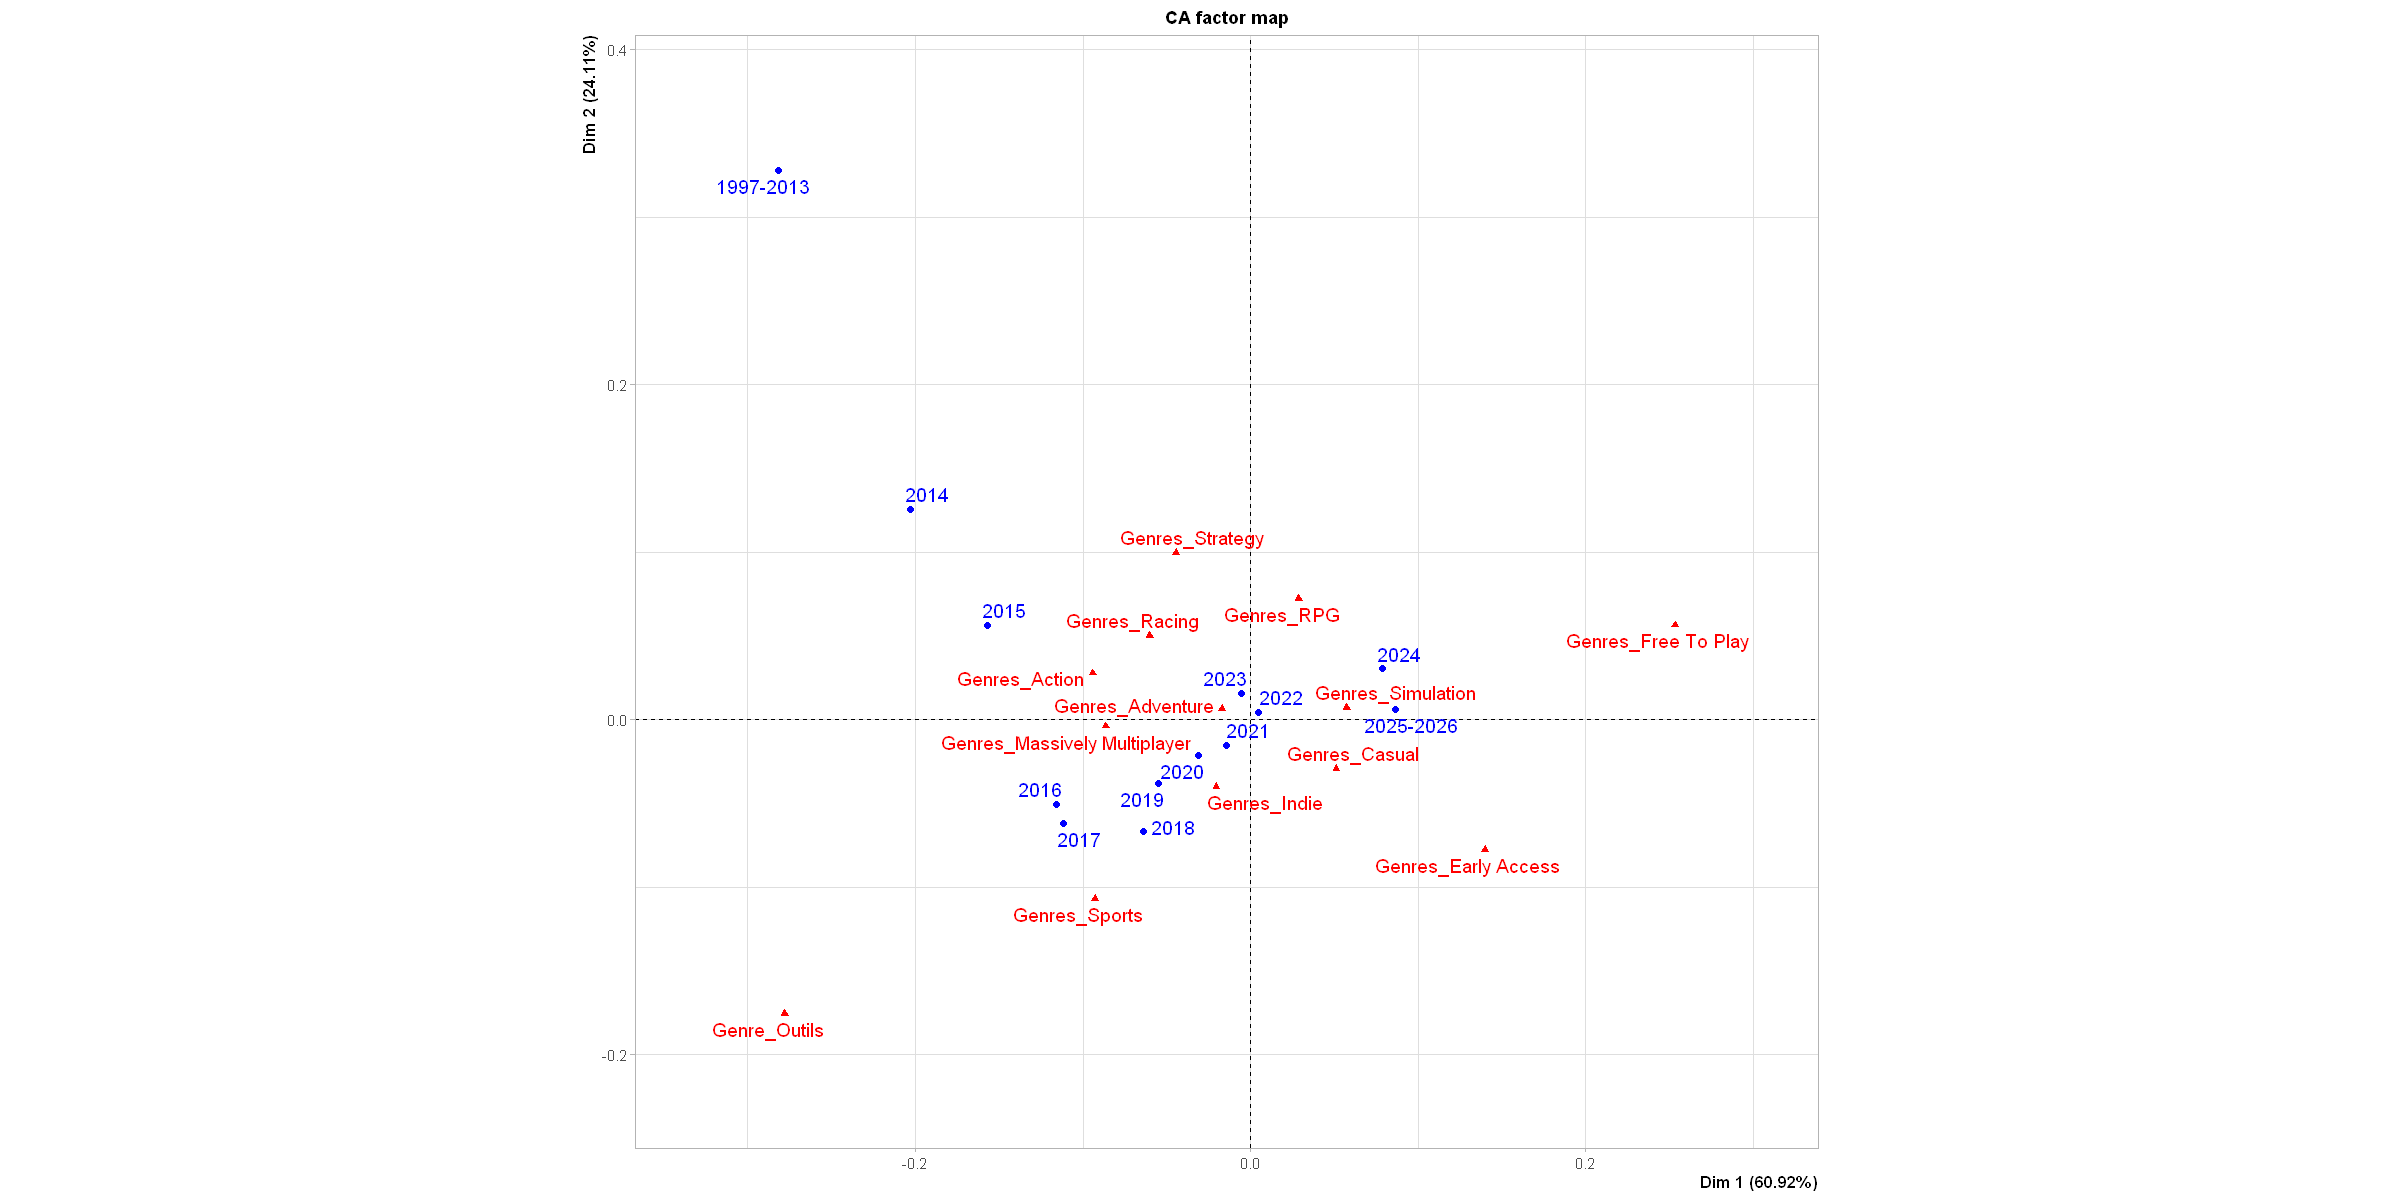

In [74]:
res.ca_zoom <- CA(tab_filtre)

L’analyse montre que la manière dont les jeux sont publiés sur Steam a bien changé en 20 ans :

**1997 - 2013**: Durant cette période, la majorité des nouveaux jeux publiés appartiennent aux genres *Action* et *Strategy*. Ces catégories présentent les résidus les plus élevés, ce qui montre que la publication se concentrait alors sur ces genres de jeux traditionnels.

**2016 - 2020**: On observe un changement avec une augmentation nette de la publication de jeux Indie (indépendants). C'est aussi à ce moment que la publication de logiciels et outils se distingue le plus, montrant que Steam a commencé à publier autre chose que de simples jeux vidéo.

**2024 - 2026**: De nos jours, la publication est massivement dominée par le Free to Play et l'Early Access. Le résidu pour le Free to Play atteint son maximum en 2024 (19.85), prouvant que ce modèle de publication est devenu prioritaire. Cela permet de publier des jeux gratuitement pour attirer beaucoup de monde, ou de les sortir avant qu'ils ne soient finis (Early Access) afin de limiter les risques financiers.

## CA Genres-Estimated.owners

**A mettre la CA de lila**

## CA Genres-Required.Age

## CA Genres-Systeme d'exploitation

Nous appliquons ensuite la même démarche analytique pour étudier la relation entre les genres et les systèmes d'exploitation (Linux, Mac, Windows). Le processus reste identique : création du tableau de contingence, réalisation du test d'indépendance du Khi-deux, puis exécution de l'Analyse des Correspondances (CA).

In [76]:
cols_genres <- c( "Genres_Early Access", "Genres_Action", 
                 "Genres_Adventure", "Genres_Casual", "Genres_Free To Play", 
                 "Genres_Indie", "Genres_Massively Multiplayer", "Genres_Racing", 
                 "Genres_RPG", "Genres_Simulation", "Genres_Sports", 
                 "Genres_Strategy", "Genre_Mature")

cols_os <- c("Windows", "Mac", "Linux")

# 2. Construction du tableau de contingence
# On cherche directement la valeur "TRUE" (qu'elle soit un texte ou un label de factor)
tab_contingence_os <- sapply(cols_os, function(os) {
  sapply(cols_genres, function(genre) {
    # On compare au label "TRUE"
    sum(as.character(data_quali_new[[genre]]) == "1" & 
        as.character(data_quali_new[[os]]) == "True", na.rm = TRUE)
  })
})

rownames(tab_contingence_os) <- cols_genres
colnames(tab_contingence_os) <- cols_os



In [77]:
test_khi2_os <- chisq.test(tab_contingence_os)
print(test_khi2_os)


	Pearson's Chi-squared test

data:  tab_contingence_os
X-squared = 1009, df = 24, p-value < 2.2e-16



La p-valeur étant inférieure à $0.05$, nous rejetons l'hypothèse d'indépendance. Les variables sont statistiquement liées, ce qui justifie l'utilisation d'une CA.

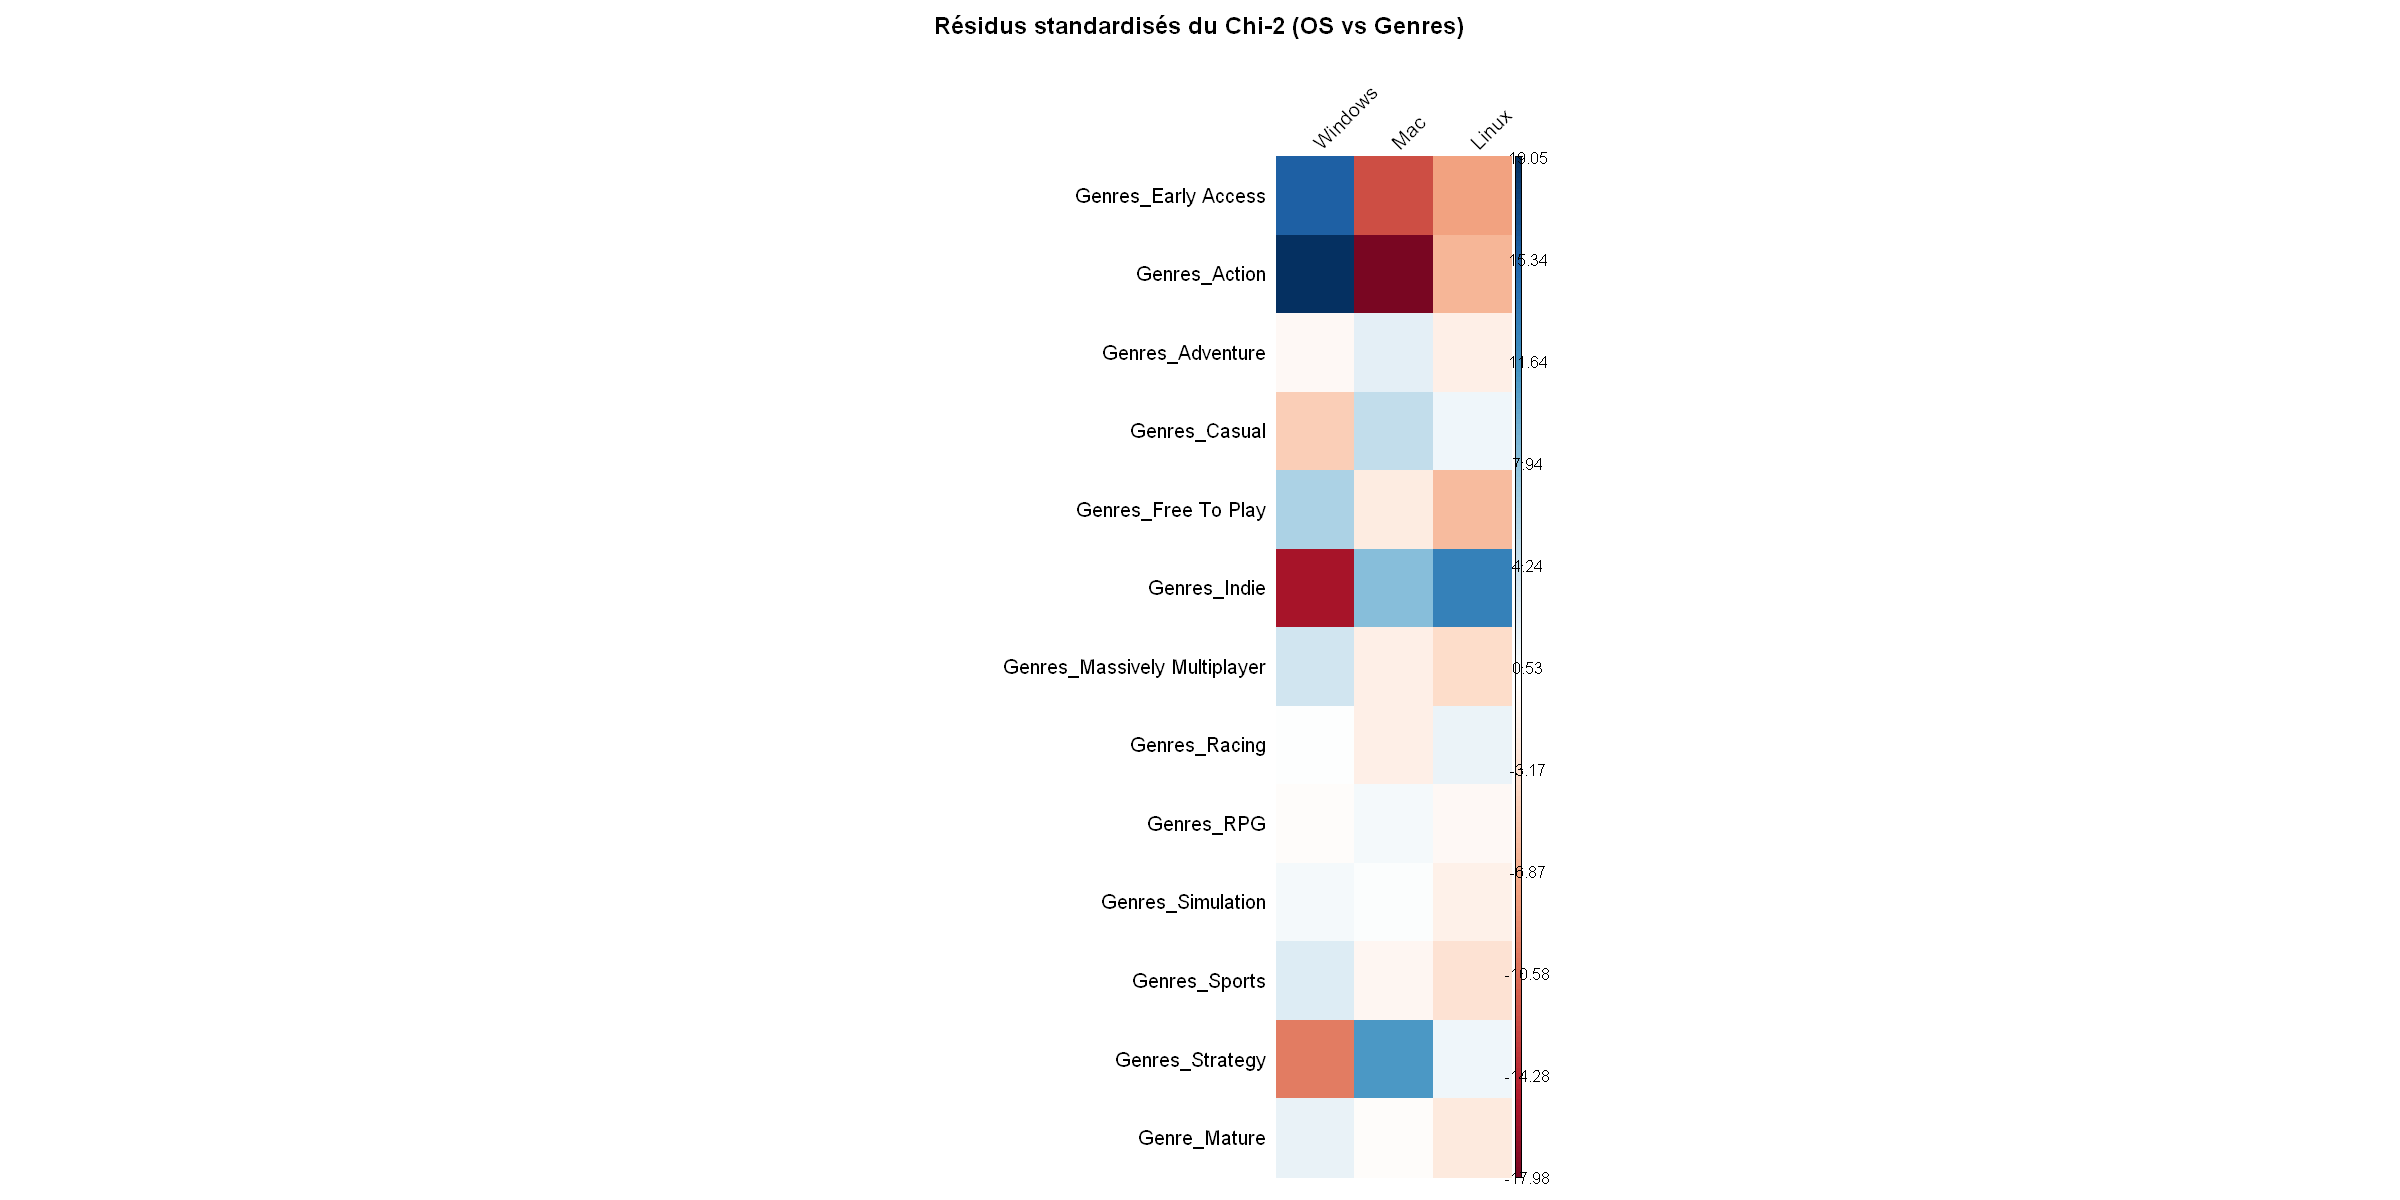

In [80]:
residus_os <- test_khi2_os$stdres
corrplot(residus_os, 
         is.cor = FALSE,method = "color",tl.srt = 45,tl.col = "black",mar = c(0,0,2,0),title = "Résidus standardisés du Chi-2 (OS vs Genres)")

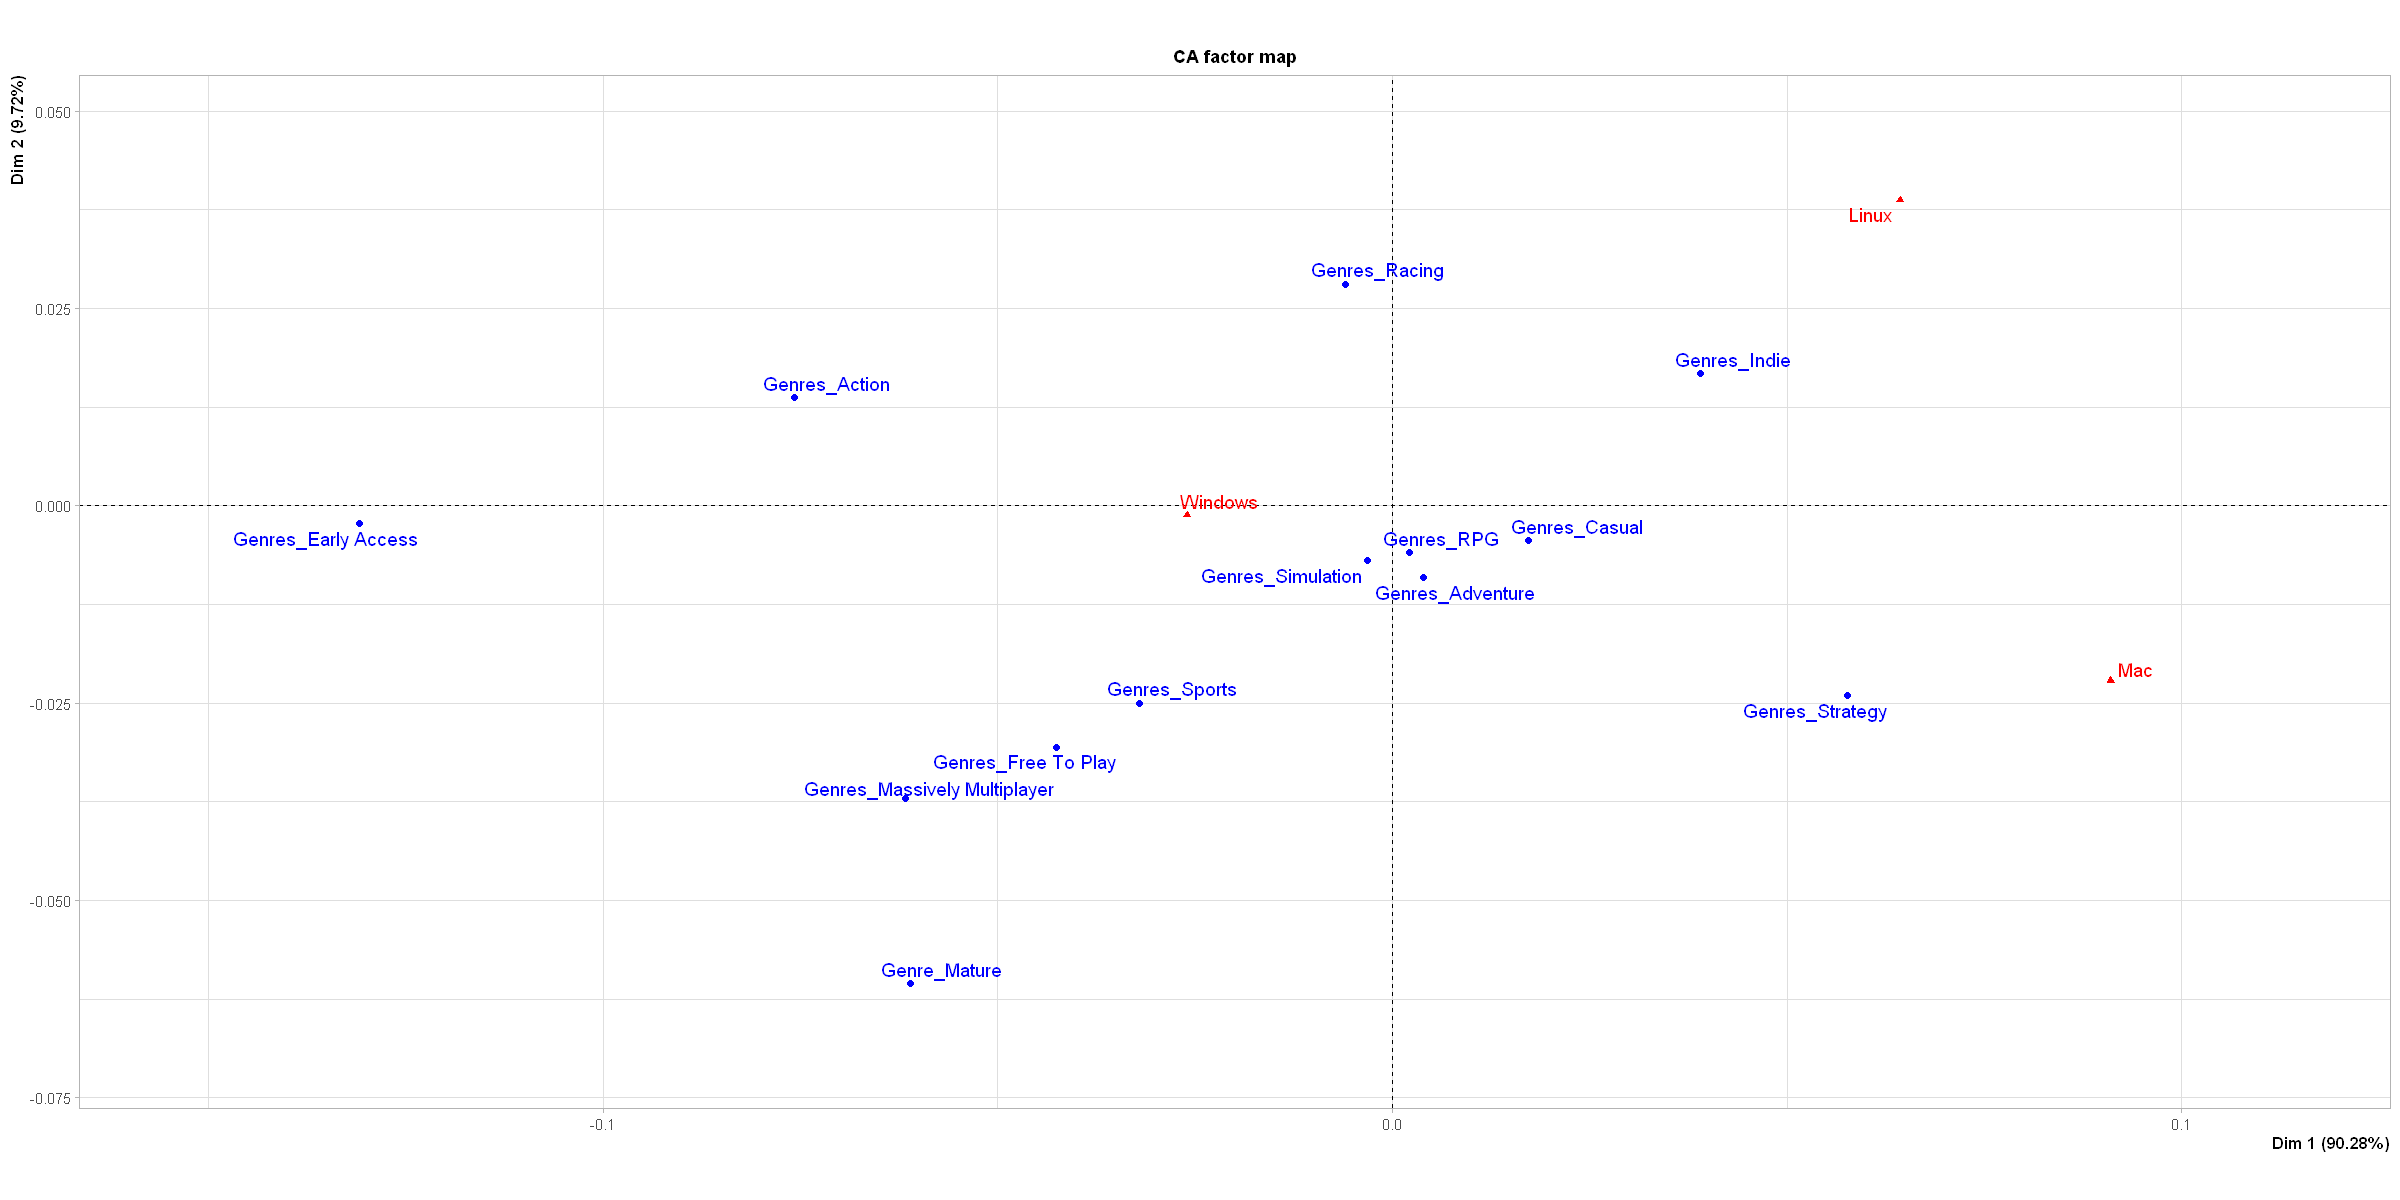

In [79]:
res.ca_os<- CA(tab_contingence_os)

L'observation conjointe de la carte des résidus et de la CA montre que la modalité Windows, située au centre du plan factoriel, représente la norme de publication des jeux. L'axe principal (90,28 % de la variance) sépare logiquement ces jeux standards des jeux multiplateformes : on y observe que les genres Indie et Strategy sont significativement sur-représentés sur Mac et Linux, tandis que les genres Action et Early Access y affichent une forte sous-représentation.

Après avoir exploré l'influence des variables qualitatives sur les genres, nous souhaitons désormais analyser l'impact des variables quantitatives. Pour ce faire, nous allons réaliser une FAMD (Factor Analysis of Mixed Data) croisant les genres avec nos variables quantitatives.

## FAMD Genres-variables quantitatives

In [87]:
df_famd<-df_mca_ready %>%select(-Name,- Categories,-Tags,-Language,- Developers,-Publishers)

In [88]:
summary(df_famd)

    Release.date    Estimated.owners  Required.age       Discount     
 2025-2026:21812   0-20K    :75337   0      :113288   Min.   :  0.00  
 2024     :18104   0        :13649   17     :   782   1st Qu.:  0.00  
 2023     :13337   20K-50K  :11395   13     :   175   Median :  0.00  
 2022     :11403   50K-100K : 5349   18     :   164   Mean   : 19.62  
 2021     :10441   100K-200K: 3450   16     :    31   3rd Qu.: 45.00  
 2020     : 8746   200K-500K: 2845   10     :    26   Max.   :100.00  
 (Other)  :30670   (Other)  : 2488   (Other):    47                   
  Windows          Mac          Linux       Metacritic.score
 False:    44   False:93260   False:98841   Min.   : 0.000  
 True :114469   True :21253   True :15672   1st Qu.: 0.000  
                                            Median : 0.000  
                                            Mean   : 2.703  
                                            3rd Qu.: 0.000  
                                            Max.   :97.000  
     

Pour observer comment les autres variables qualitatives se projettent sur l’espace de la FAMD, nous les intégrons en tant que variables supplémentaires. De plus, les genres *Video* et *Mature* sont également passés en variables supplémentaires en raison de leur sous-représentation. Nous sommes arrivés à ces conclusions de manière empirique, à la suite des FAMD successives que nous avons réalisées.

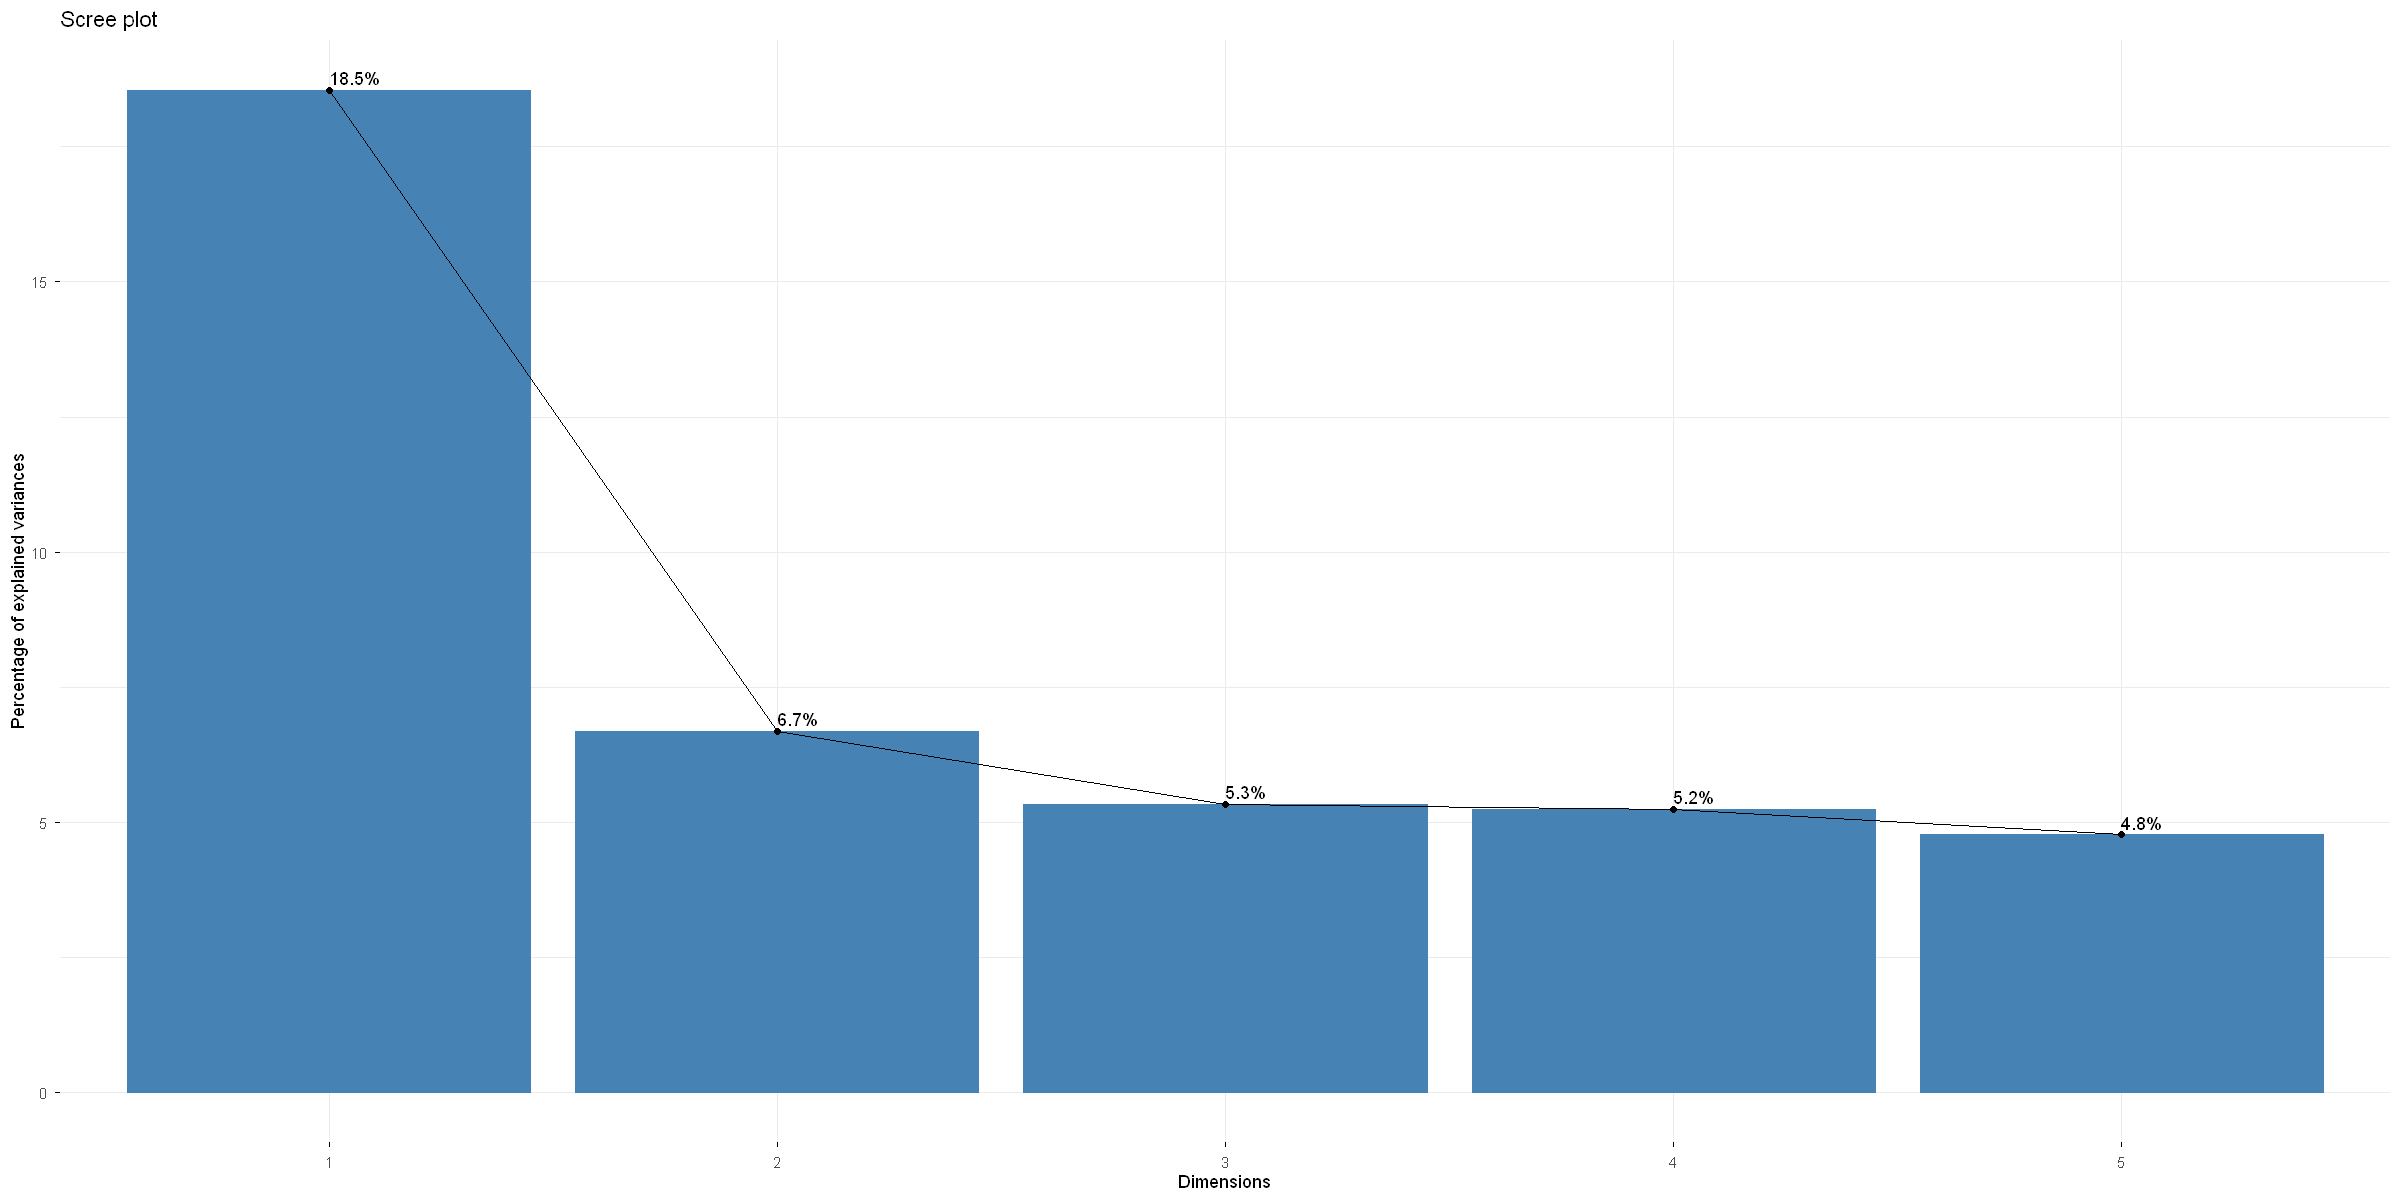

In [89]:

res.famd <- FAMD(df_famd,sup.var=c(1:3,5:7,35,36), graph = FALSE)
fviz_eig(res.famd,addlabels = T)

Nous retenons les deux premières dimensions de la FAMD car, dès la troisième, on observe un plateau. Cela indique que l'ajout de dimensions supplémentaires n'apporte plus d'information significative pour l'analyse.

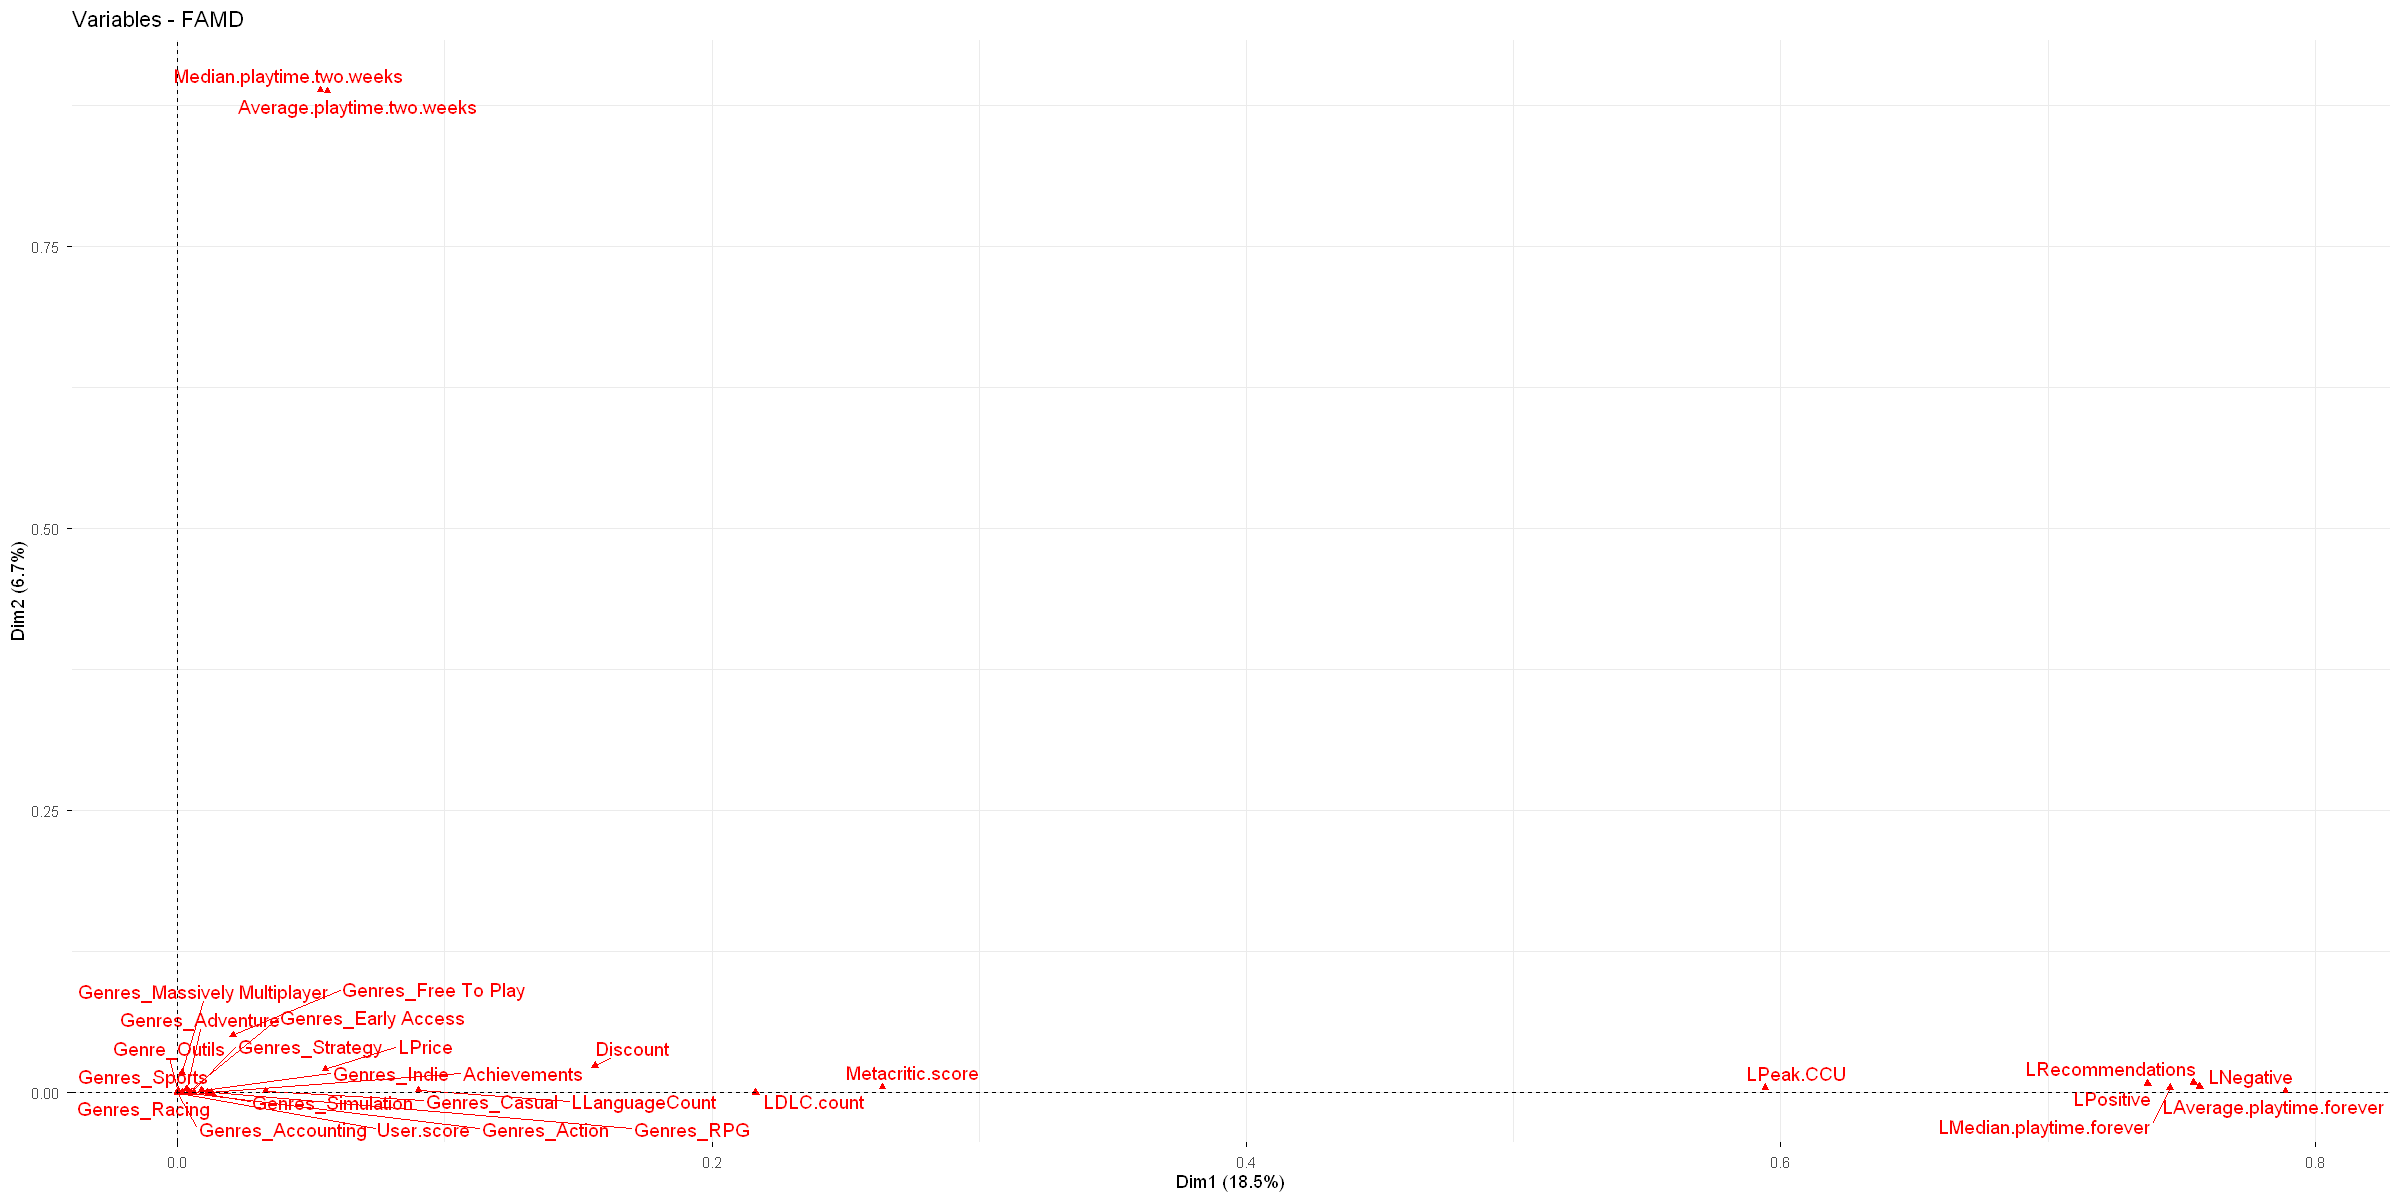

In [94]:
fviz_famd_var(res.famd, repel = T,axes=c(1,2))

### Contribution aux axes

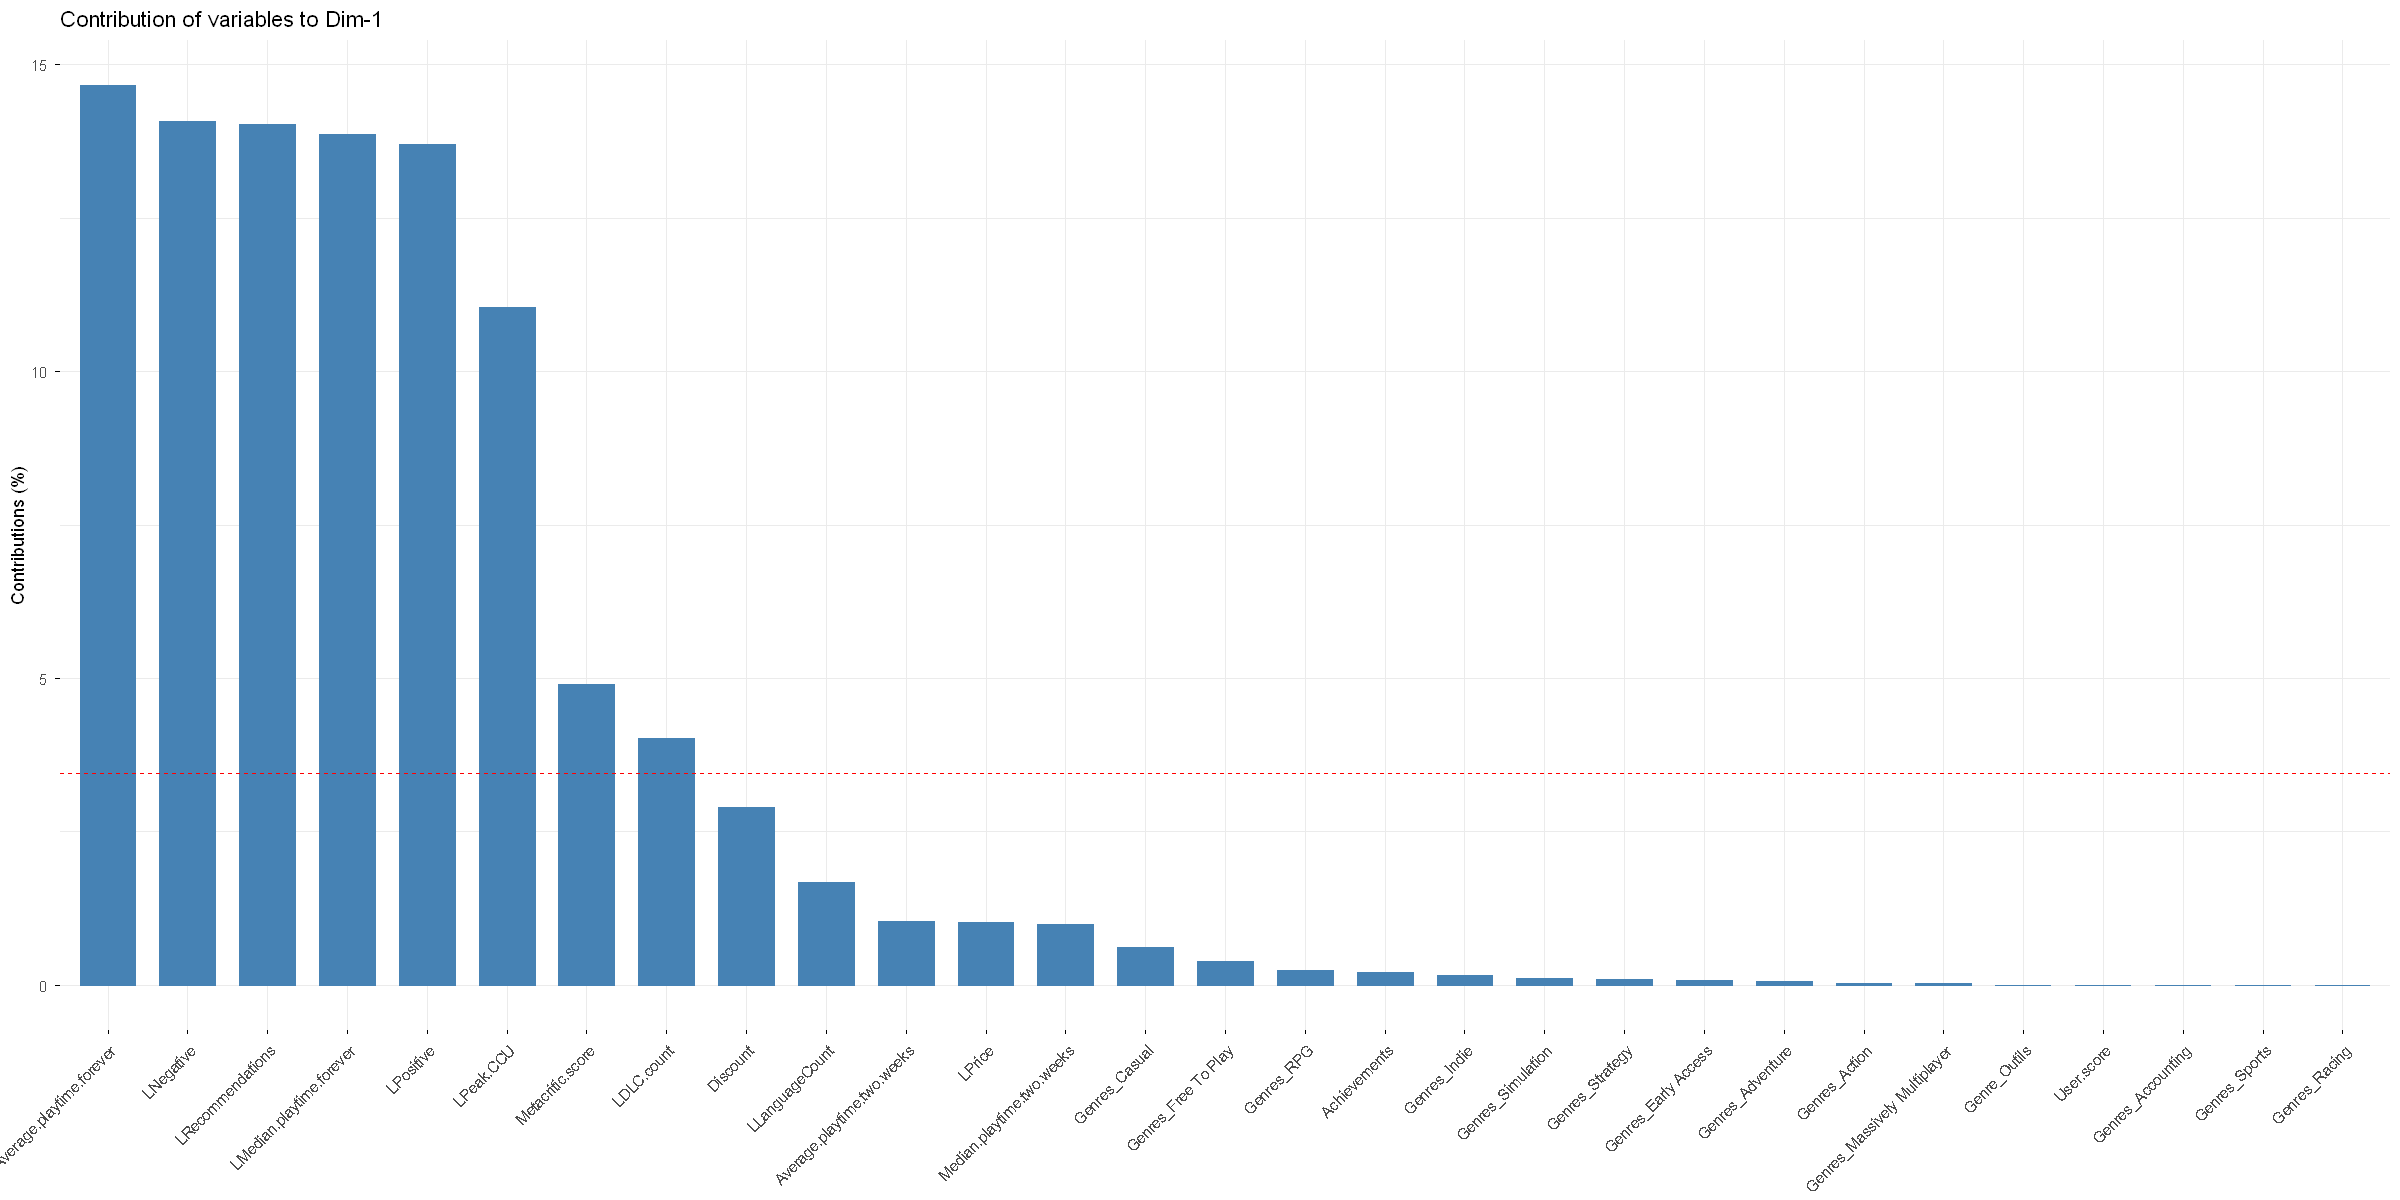

In [ ]:
fviz_contrib(res.famd, choice = "var", axes = 1) 

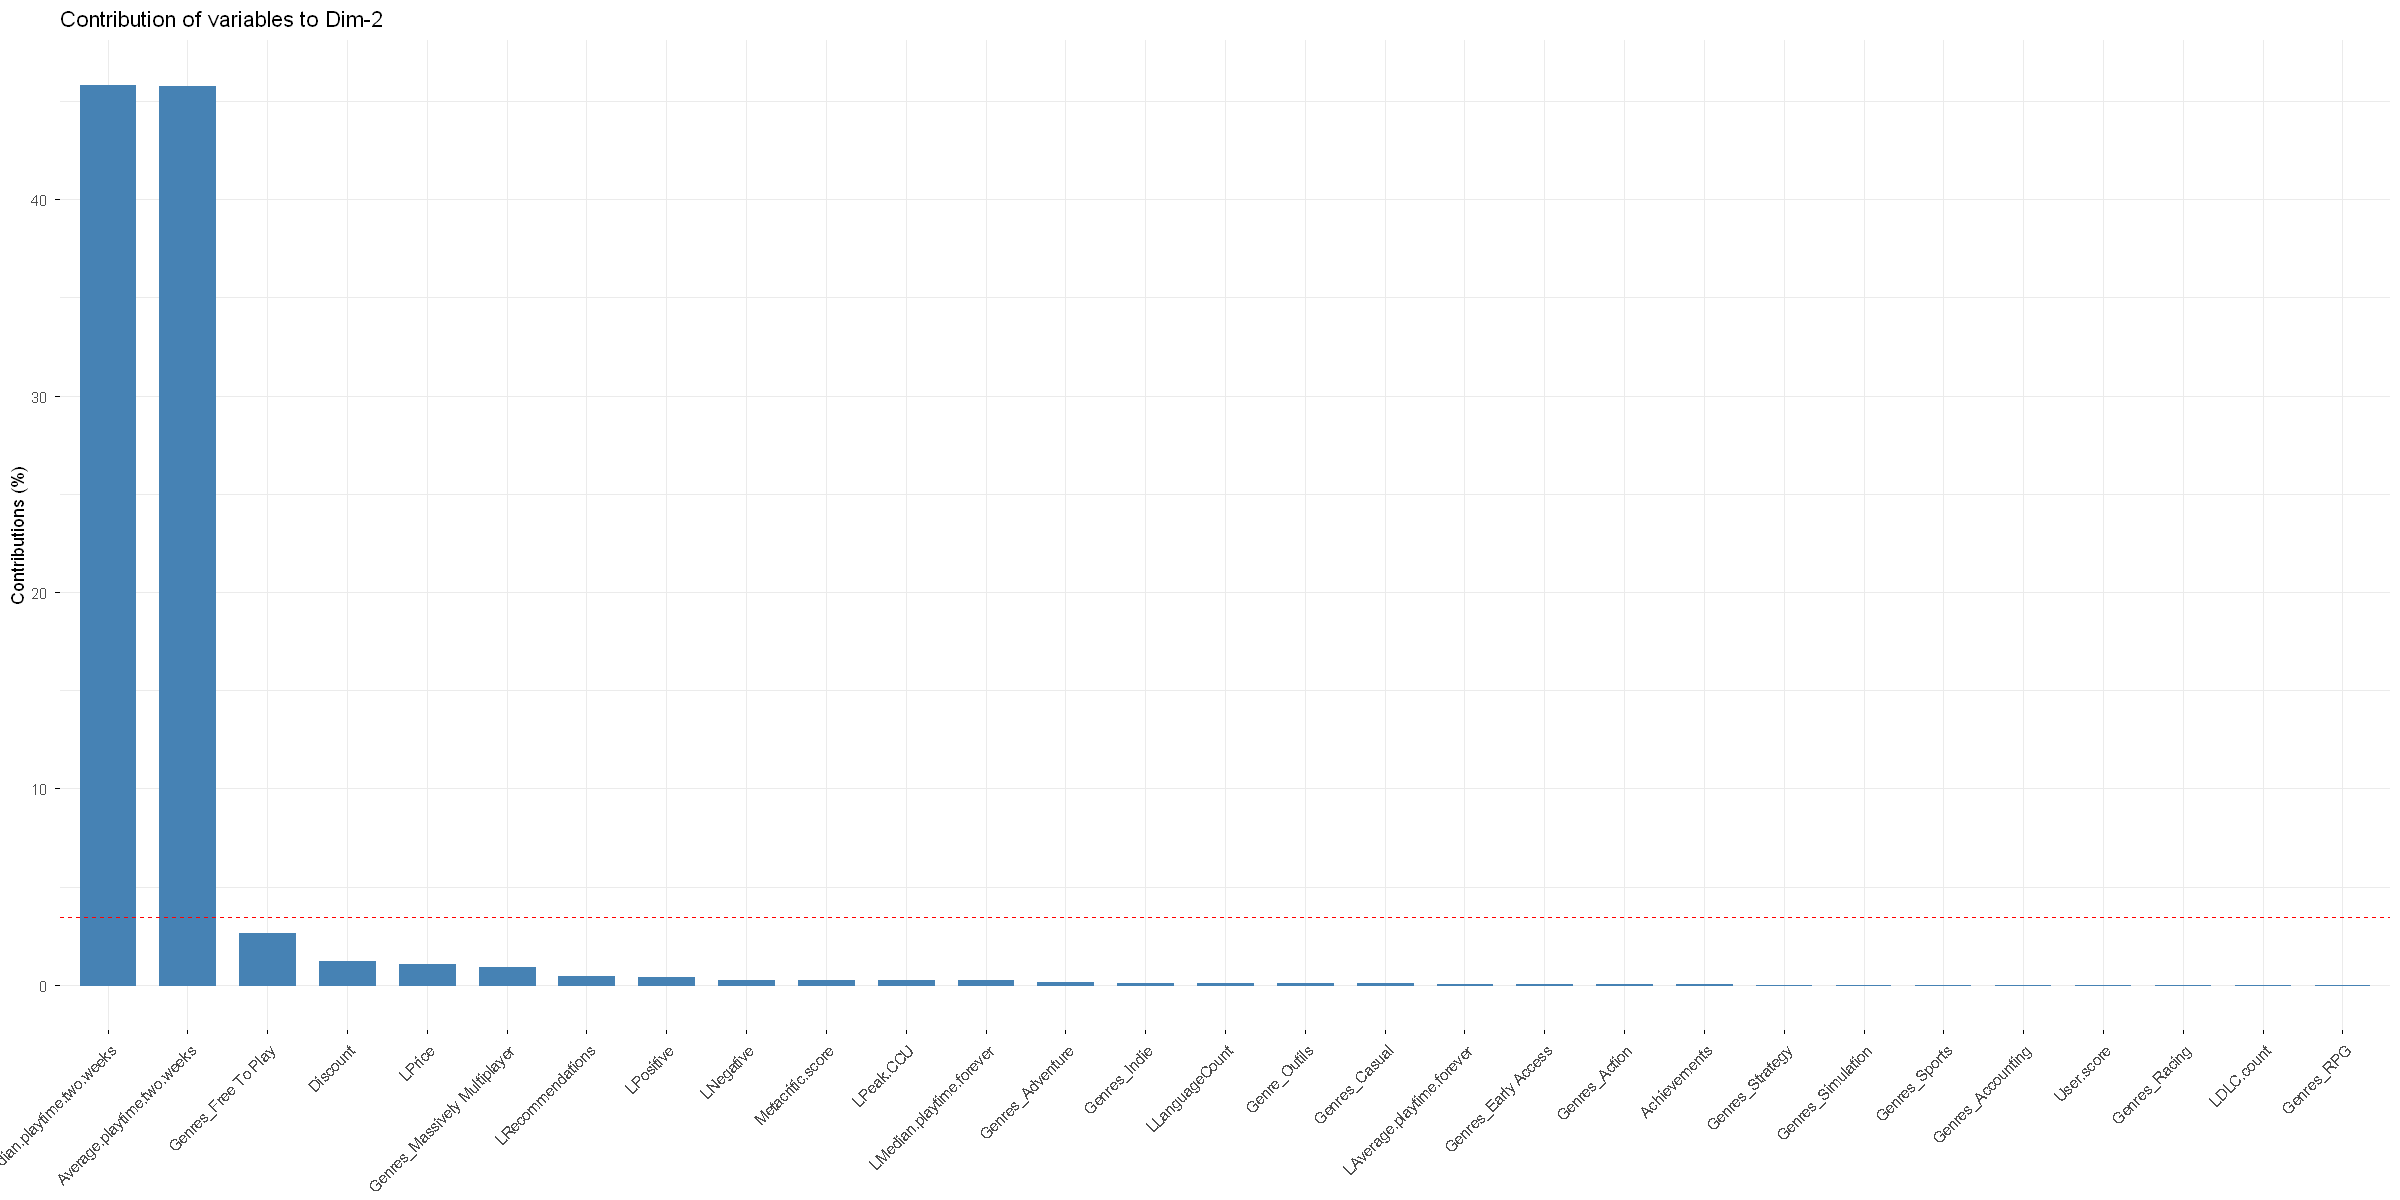

In [92]:
fviz_contrib(res.famd, choice = "var", axes = 2)


Cette **FAMD** permet d'identifier deux axes principaux qui expliquent l'ensemble des jeux sur Steam :

Axe 1 (18,5%): C'est la dimension la plus forte. Elle regroupe les variables de réussite massive (nombre de recommandations, évaluations positives et temps de jeu total). Cet axe montre que le succès ne dépend pas d'un genre spécifique, car tous les genres restent regroupés au centre de cette dimension.

Axe 2 (6,7%): Cette dimension isole les jeux récemment joués (temps de jeu sur les deux dernières semaines). Elle différencie les jeux qui génèrent une activité intense en ce moment de ceux qui ont un succès historique mais sont moins pratiqués ces deux dernières semaines.

On peut donc conclure qu'il n'existe pas de genre intrinsèquement lié au "succès".


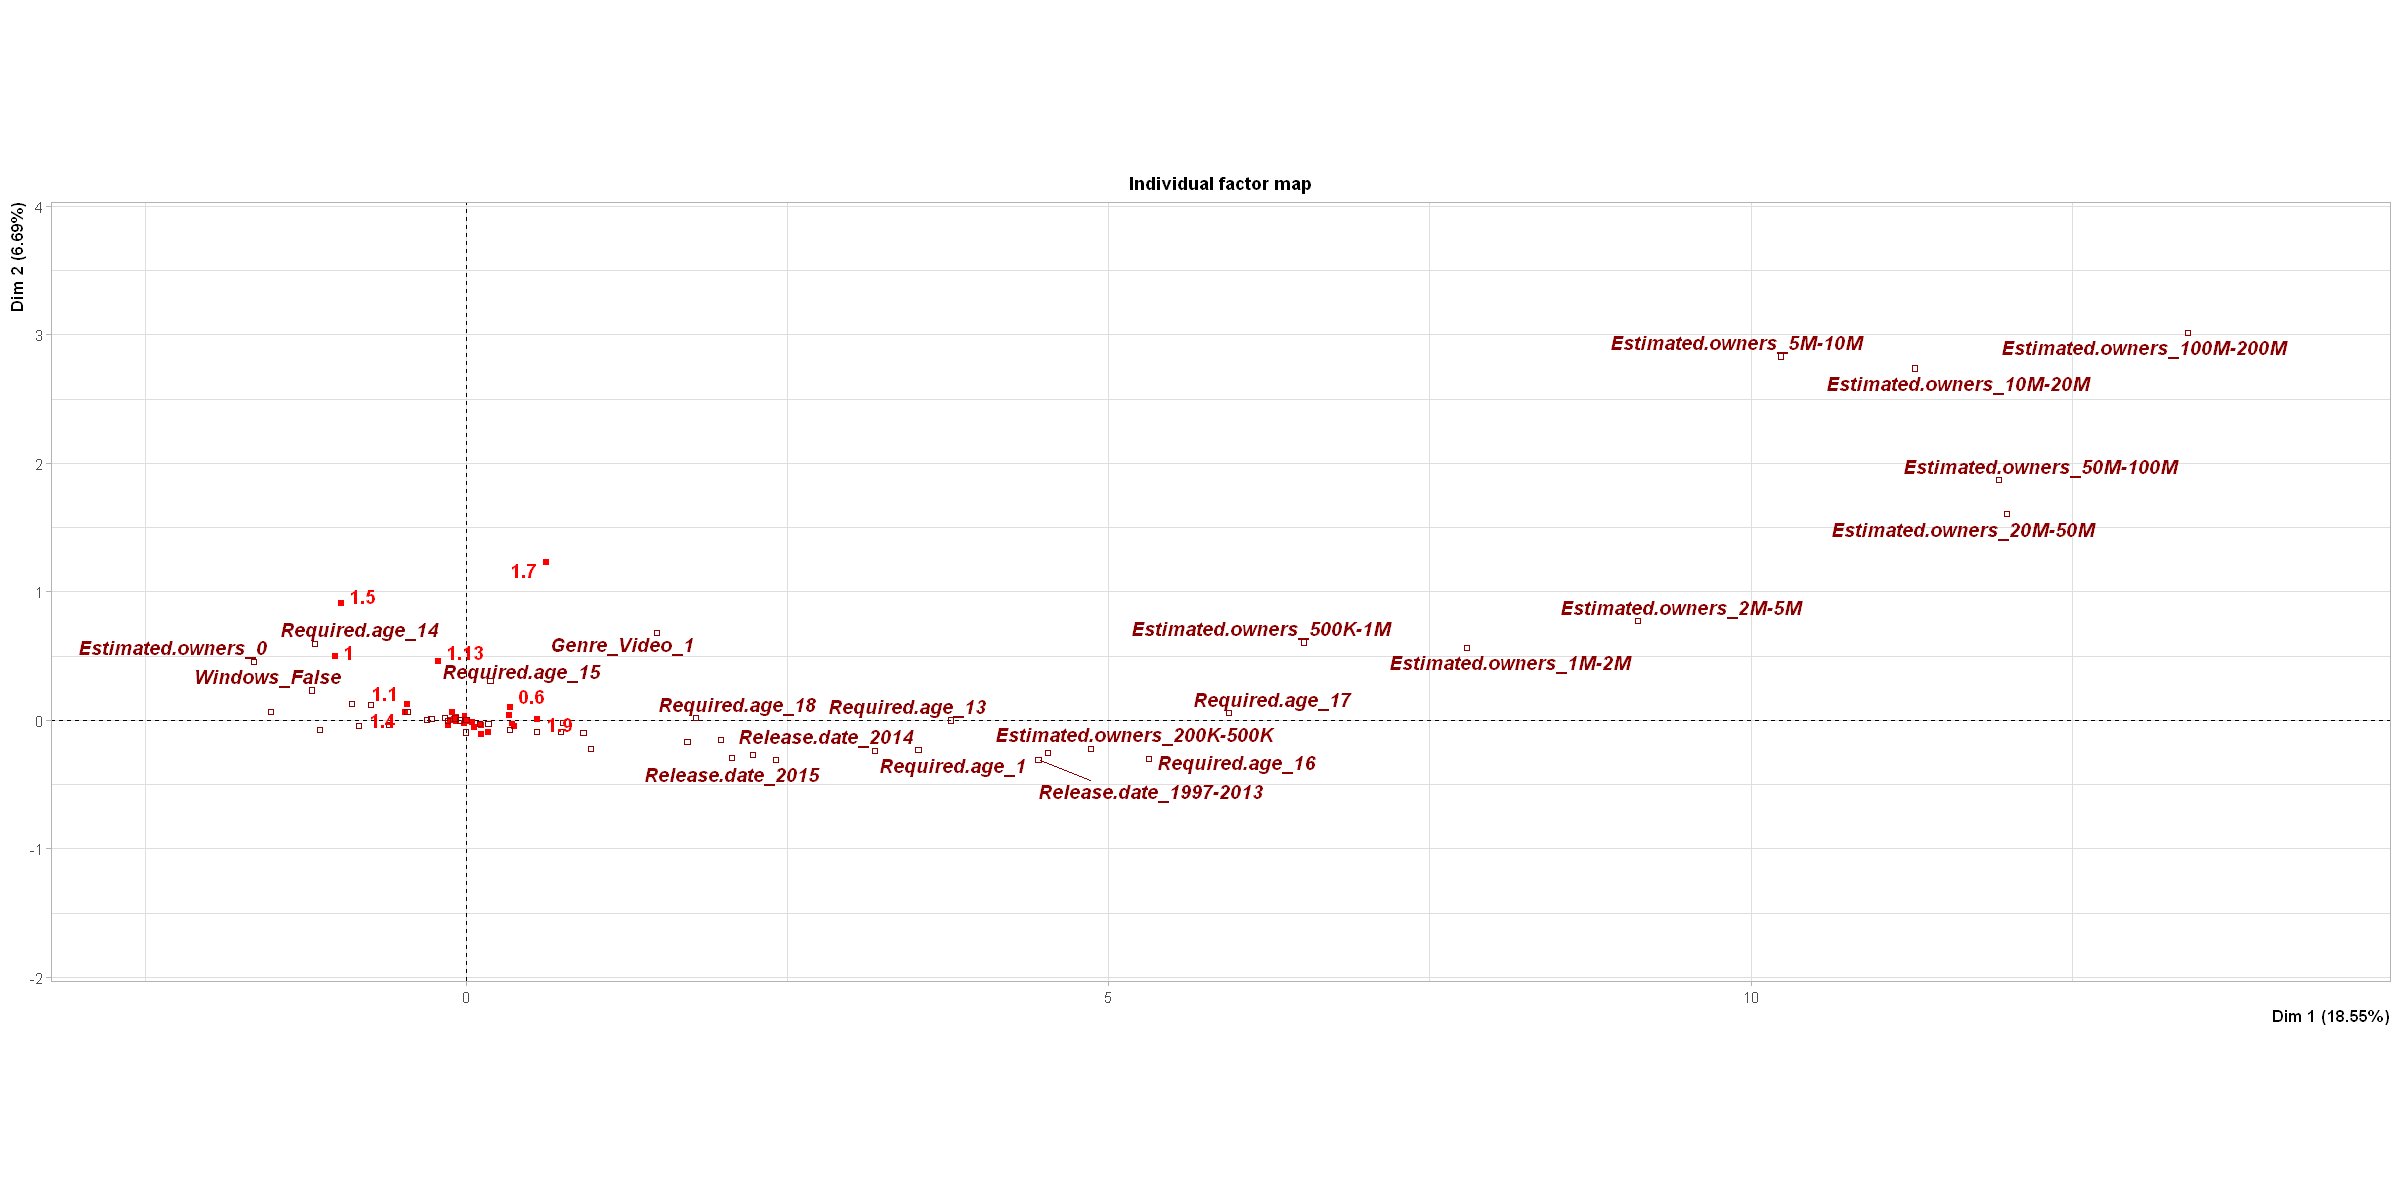

In [95]:

options(repr.plot.width = 20, repr.plot.height = 10)
plot(res.famd, choice = "quali", invisible = "ind")


La projection des **variables supplémentaires** valide la cohérence de l'analyse : l'axe 1 montre bien que plus on va vers la droite, plus les jeux ont de succès (Estimated.owners), tout en révélant que ces individus sont souvent des jeux pour adultes (Required.age 17 ou 18). L'axe 2 montre que les plus gros succès commerciaux sont aussi les jeux les plus joués en ce moment, ce qui permet de les distinguer des vieux succès historiques qui ont beaucoup de possesseurs mais moins de joueurs actifs. L'ancienneté joue aussi un rôle dans le succès, car les jeux sortis il y a longtemps (Release.date avant 2013) ont eu plus de temps pour accumuler des millions de joueurs et se placer le plus à droite de l'axe 1.

## Clustering GMM

À la suite de cette réduction de dimension, nous utilisons un modèle de mélange gaussien (GMM) pour regrouper les jeux et vérifier si des profils types se dessinent parmi les différentes observations.

In [112]:
set.seed(123)
#on récupère les coordonnées des 2 premières dimensions de la FAMD
donnees_gmm <- res.famd$ind$coord[, 1:2]
mod_gmm <- Mclust(donnees_gmm)

In [113]:
summary(mod_gmm)

---------------------------------------------------- 
Gaussian finite mixture model fitted by EM algorithm 
---------------------------------------------------- 

Mclust VVV (ellipsoidal, varying volume, shape, and orientation) model with 9
components: 

 log-likelihood      n df       BIC       ICL
      -158428.9 114513 53 -317475.2 -366561.9

Clustering table:
    1     2     3     4     5     6     7     8     9 
38408  5068 33633  2489  2325  6633  6035 19546   376 

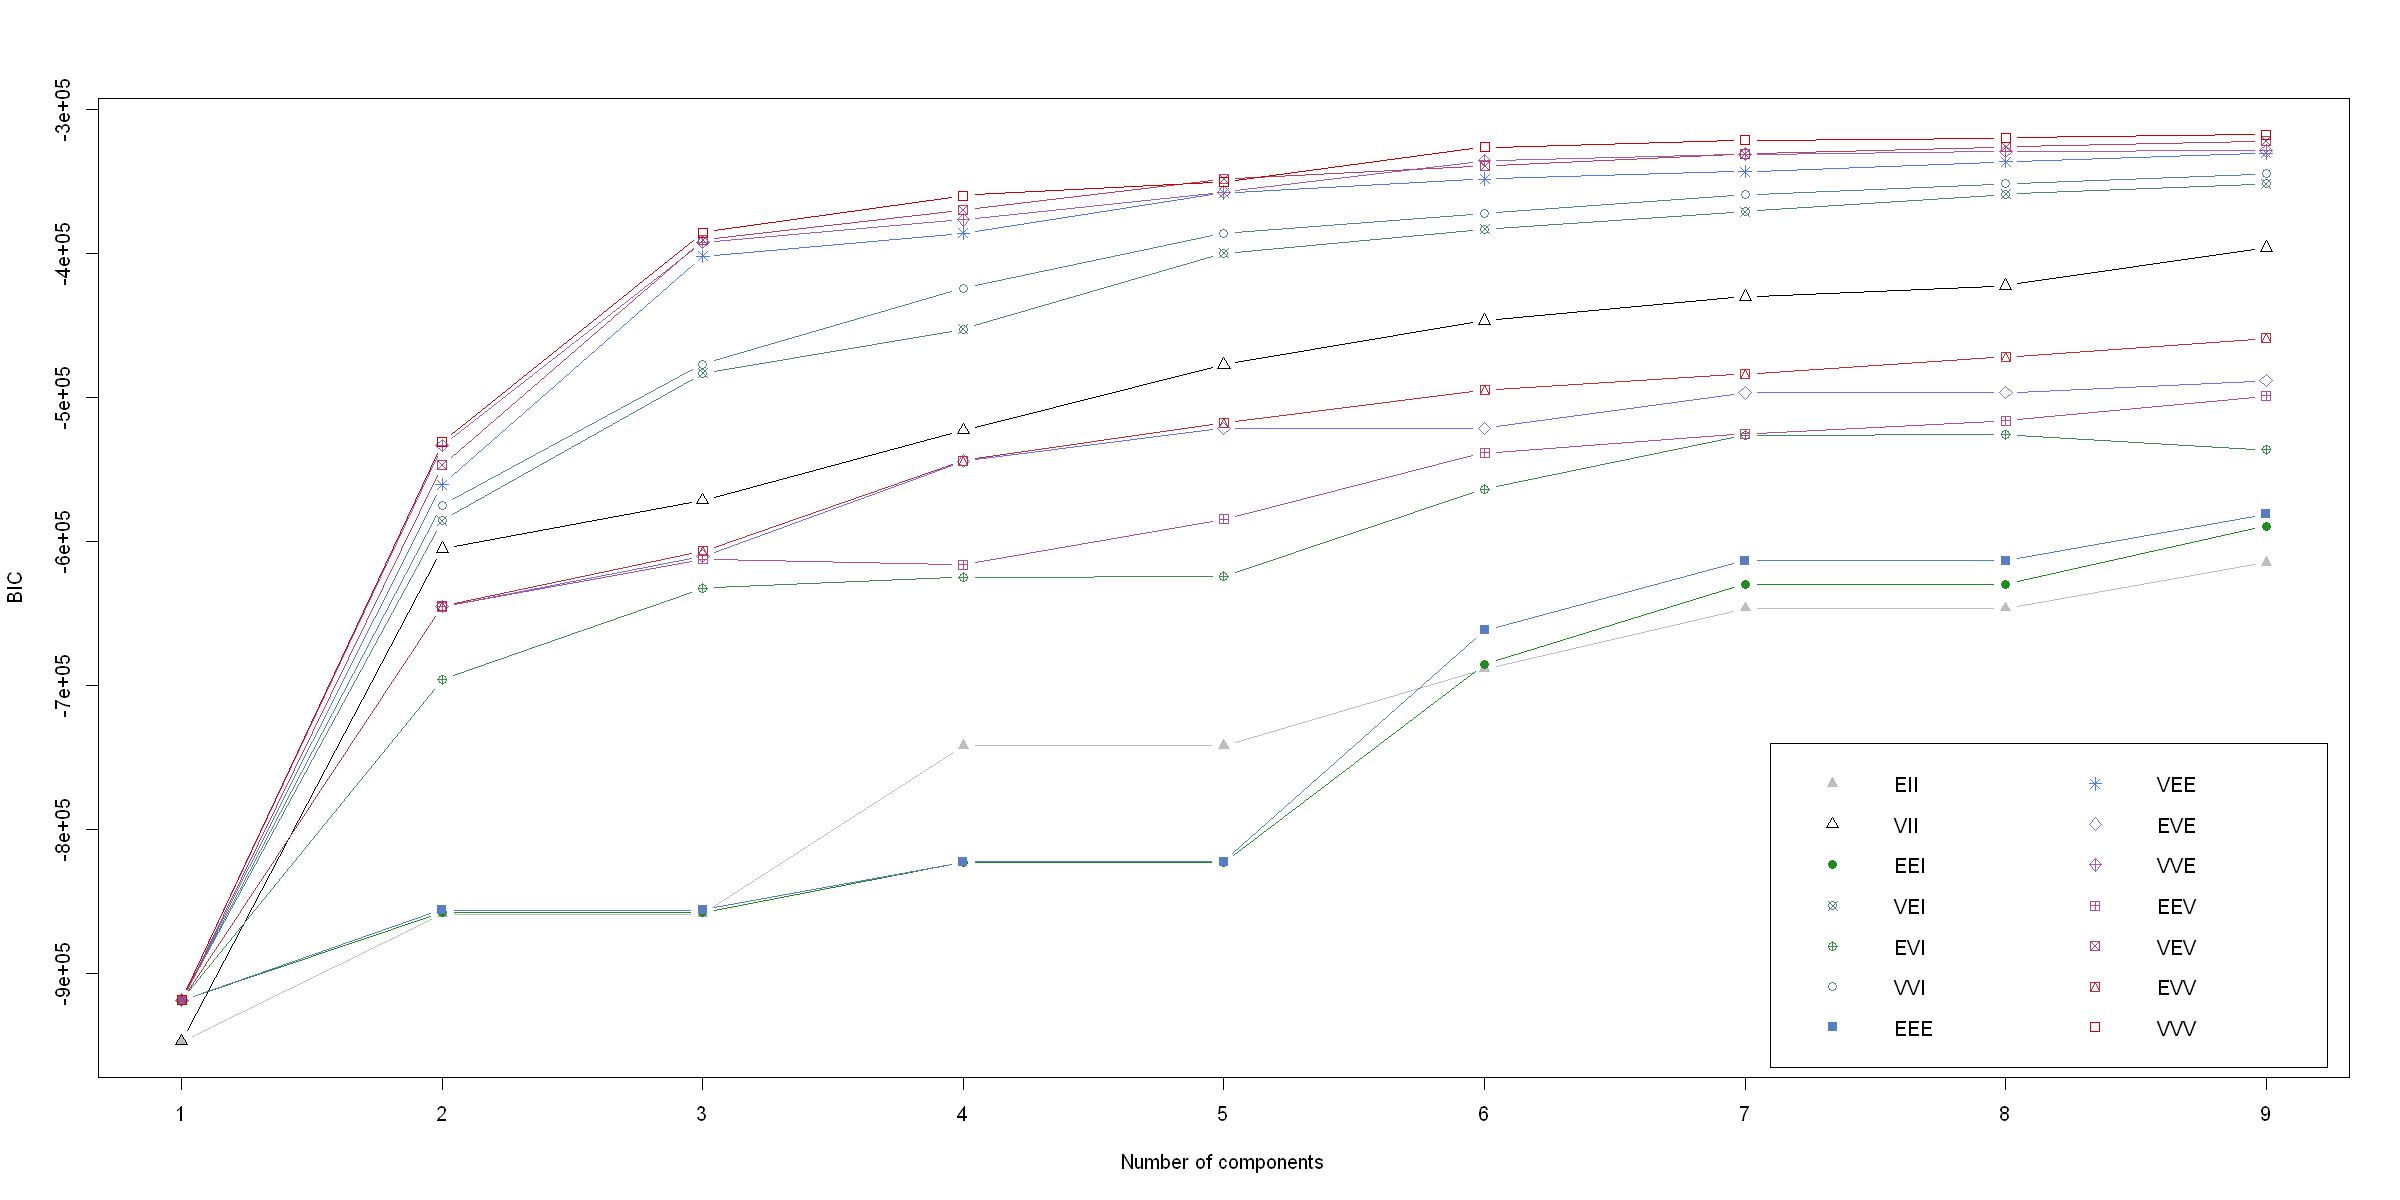

In [114]:
plot(mod_gmm, what = "BIC")

Pour définir le nombre de clusters, on a utilisé le critère BIC avec la fonction *Mclust*, on observe que le modèle VVV (courbe rouge supérieure), définie avec des clusters avec une structure ellipsoïdale à volume, forme et orientation variables, est la plus adaptée pour nos données de FAMD. On constate que la courbe atteint son maximum à 9 clusters.


In [115]:
# Ajouter le numéro de cluster aux données d'origine
donnees_finales <- df_famd
donnees_finales$cluster_gmm <- mod_gmm$classification

In [116]:
#  Synthèse des variables quantitatives (Moyennes par cluster)

cols_quanti <- colnames(df_famd)[sapply(df_famd, is.numeric)]


tab_quanti <- aggregate(donnees_finales[, cols_quanti], 
                        by = list(Cluster = donnees_finales$cluster_gmm), 
                        FUN = mean)
print("--- Profil Moyen des Clusters (Quantitatif) ---")
print(round(tab_quanti, 2))

[1] "--- Profil Moyen des Clusters (Quantitatif) ---"
  Cluster Discount Metacritic.score User.score Achievements
1       1     9.84             0.00       0.00         8.45
2       2     2.06             0.07       0.01         8.15
3       3    24.63             0.06       0.03        13.98
4       4     4.69             0.59       0.05        14.94
5       5    34.76            23.85       0.02        60.17
6       6     0.02             0.00       0.00         6.43
7       7    44.37            26.51       0.03        54.53
8       8    33.67             4.24       0.09        40.55
9       9    29.45            19.82       0.00        53.41
  Average.playtime.two.weeks Median.playtime.two.weeks LPositive LNegative
1                       0.00                      0.00      0.64      0.20
2                       0.02                      0.02      2.02      1.31
3                       0.00                      0.00      2.36      1.37
4                      14.18                  

Nous pouvons noter ces conclusion à partir du profils moyen des variables quantitatives:


- **Cluster 9** : Ce cluster regroupe les valeurs maximales du jeu de données pour l'engagement et l'audience. On y observe les pics de joueurs les plus hauts (LPeak.CCU : 5.09), le temps de jeu récent le plus élevé (Average.playtime.two.weeks : 2318.29) et le plus grand nombre de langues (LLanguageCount : 2.05). Le prix moyen y est élevé (LPrice : 1.84) et le contenu additionnel est le plus présent (LDLC.count : 0.91).

- **Cluster 8** : Ce groupe se distingue spécifiquement par l'investissement des joueurs sur le long terme. Il affiche le nombre de succès le plus élevé (Achievements : 54.50) et un temps de jeu récent important (Average.playtime.two.weeks : 137.13).

- **Cluster 3** : Ce cluster se caractérise par une forte reconnaissance critique (Metacritic.score : 23.44) et un volume de recommandations très élevé (LRecommendations : 7.39). C'est un segment à prix élevé (LPrice : 1.89) où les stratégies de remises sont très présentes (Discount : 40.53 %).

- **Cluster 6** : Ce groupe se détache par sa politique tarifaire, affichant le taux de remise moyen le plus élevé de l'échantillon (Discount : 42.33 %). Il maintient une base solide de retours positifs (LPositive : 5.39) et un engagement historique notable (LAverage.playtime.forever : 5.12).

- **Cluster 4** : Il représente un segment intermédiaire caractérisé par un équilibre entre le prix (LPrice : 1.52) et un nombre de succès notable (Achievements : 34.10), sans toutefois atteindre les sommets d'audience ou d'usage des clusters 8 ou 9 (LPeak.CCU : 0.30).

**Clusters non significatifs pour l'analyse:**
Clusters 1, 2, 5 et 7 : Ces groupes ne permettent pas d'extraire de conclusions probantes à ce stade. Ils affichent des valeurs nulles ou extrêmement faibles sur la quasi-totalité des indicateurs de performance, notamment pour les recommandations (LRecommendations entre 0.00 et 0.11), le temps de jeu récent (Average.playtime.two.weeks entre 0.00 et 0.54) ou les scores critiques (Metacritic.score entre 0.00 et 0.16). Aucune variable quantitative ne se détache suffisamment pour caractériser une dynamique propre, si ce n'est une absence d'activité et d'engagement mesurable sur la plateforme.


In [117]:

distribution_succes <- table(donnees_finales$cluster_gmm, donnees_finales$Estimated.owners)

prop.table(distribution_succes, margin =2) * 100

   
              0       0-20K     20K-50K    50K-100K   100K-200K   200K-500K
  1 43.58561067 40.31750667 13.30408074  7.64628903  3.24637681  1.47627417
  2  9.04828193  3.80689435  5.69548047  4.33725930  1.97101449  0.45694200
  3  8.03721884 37.52074014 27.48573936 14.45129931  7.44927536  3.23374341
  4  0.21979632  1.29551217  4.24747696  7.02935128  9.24637681  8.40070299
  5  0.00000000  0.26680117  0.81614743  2.76687231  7.79710145 15.60632689
  6 38.85998974  1.66983023  0.43878894  0.24303608  0.17391304  0.07029877
  7  0.00000000  0.89066461  7.38920579 18.48943728 33.73913043 50.61511424
  8  0.24910250 14.14311693 40.54409829 44.55038325 35.24637681 18.24253076
  9  0.00000000  0.08893372  0.07898201  0.48607216  1.13043478  1.89806678
   
        500K-1M       1M-2M       2M-5M      5M-10M     10M-20M     20M-50M
  1  0.43478261  0.00000000  0.25000000  0.00000000  0.00000000  0.00000000
  2  0.26086957  0.00000000  0.00000000  0.00000000  0.00000000  0.00000000
  3 


Cluster 9 : Il possède l'exclusivité des très grands succès mondiaux, concentrant 75 % des jeux du segment 100M-200M et 33.3 % du segment 50M-100M.

Cluster 8 : Il apparaît comme cluster dominant pour les succès établis, détenant la majorité des jeux entre 2M et 50M de possesseurs (avec un pic à 78 % des jeux du segment 10M-20M).

Cluster 3 : Il se positionne sur les succès intermédiaires, représentant plus de 43 % des jeux possédés par 500K-1M d'utilisateurs.

Clusters 1, 2 et 5 : Ils s'accaparent la quasi-totalité des jeux n'ayant aucune possession enregistrée ou restant sous la barre des 20K (le Cluster 1 représente 41.7 % des jeux à "0" possesseurs)


In [118]:

distribution_age <- table(donnees_finales$cluster_gmm, donnees_finales$Required.age)
prop.table(distribution_age, margin =2) * 100

   
              0           1           3           6           7          10
  1  33.7899866   0.0000000  50.0000000   0.0000000  40.0000000  23.0769231
  2   4.4506038   0.0000000  16.6666667   0.0000000   0.0000000   7.6923077
  3  29.5706518   0.0000000   0.0000000  25.0000000  60.0000000  19.2307692
  4   2.1741049   0.0000000   0.0000000  25.0000000   0.0000000   0.0000000
  5   1.8148436  50.0000000   0.0000000   0.0000000   0.0000000   7.6923077
  6   5.8443966   0.0000000   0.0000000   0.0000000   0.0000000   0.0000000
  7   4.9811101   0.0000000   0.0000000   0.0000000   0.0000000  26.9230769
  8  17.0759480  50.0000000  33.3333333  50.0000000   0.0000000  15.3846154
  9   0.2983546   0.0000000   0.0000000   0.0000000   0.0000000   0.0000000
   
             12          13          14          15          16          17
  1  30.4347826   9.7142857   0.0000000  33.3333333   6.4516129   4.0920716
  2  13.0434783   2.8571429 100.0000000   0.0000000   3.2258065   0.6393862
  3 

Cluster 1 : Il concentre 100 % des jeux restreints aux âges 20 et 21, et 31.7 % des jeux 18+.

Cluster 8 : Présente une forte concentration sur les jeux matures avec 26.2 % du segment 17+ et 32.2 % du segment 16+.

Cluster 7 : Se distingue de manière isolée en détenant 100 % des jeux dont l'âge requis est fixé à 14.

Cluster 9 : Reste très marginal sur les restrictions d'âge, avec seulement 4.9 % des jeux du segment 17+.

In [119]:
distribution_date <- table(donnees_finales$cluster_gmm, donnees_finales$Release.date)
prop.table(distribution_date, margin =2) * 100

   
      1997-2013        2014        2015        2016        2017        2018
  1  0.99320439  0.65919578  2.71891244  6.40251268 15.48081798 22.12068270
  2  0.15682175  0.26367831  0.71971212  2.31940082  3.44769309  5.34874345
  3  5.17511762  8.23994726 15.31387445 21.43029717 29.72790265 38.47601129
  4  1.67276529  3.55965722  5.11795282  6.20922928  5.54334967  4.26018008
  5 10.08886566  6.85563612  4.83806477  3.23749698  2.80547575  2.29807822
  6  0.00000000  0.00000000  0.03998401  0.04832085  0.16900456  0.33597635
  7 37.84631469 19.18259723 12.71491403  9.37424499  7.14889302  5.41593872
  8 42.13277574 60.71193144 57.97680928 50.44696787 35.37265506 21.50248622
  9  1.93413487  0.52735662  0.55977609  0.53152935  0.30420821  0.24190297
   
           2019        2020        2021        2022        2023        2024
  1 26.12537973 27.17813858 31.35714970 33.84197141 37.04731199 37.42819266
  2  6.83512842  7.87788703  4.53979504  4.52512497  4.22133913  5.12593902
  3 

Cluster 6 : Il représente les jeux dont la sortis date, détenant près de 50 % des jeux sortis entre 1997 et 2014. Sa part chute drastiquement pour les sorties récentes (3.1 % en 2025-2026).

Cluster 5 : Il domine la période de croissance intermédiaire, avec environ 40 % des jeux sortis entre 2018 et 2021.

Cluster 1 : Il caractérise le flux de publications le plus récent, sa part ne cessant de croître pour atteindre 54.4 % des sorties prévues ou réalisées en 2025-2026.

Cluster 3 : À l'instar du cluster 6, il est plus présent dans les anciennes publications (24.6 % avant 2013) que dans les nouvelles.

In [120]:

colonnes_genres <- c("Genres_Action", "Genres_Adventure", "Genres_RPG", "Genres_Indie",
                     "Genres_Casual","Genres_Free To Play","Genres_Early Access",
                     "Genres_Massively Multiplayer", "Genre_Outils")

# Fonction pour calculer le profil des genres d'un cluster donné
profil_genre <- function(cluster_id) {
  sub <- donnees_finales[donnees_finales$cluster_gmm == cluster_id, colonnes_genres]
  # Conversion et calcul de la moyenne
  colMeans(apply(sub, 2, function(x) as.numeric(as.character(x))), na.rm = TRUE)
}

# On applique la fonction aux clusters utiles (3, 4, 6, 8, 9)
comparaison_genres <- sapply(c(1:9), profil_genre)
colnames(comparaison_genres) <- paste("Cluster", c(1:9))

# On affiche le tableau en pourcentage (arrondi)
print(round(comparaison_genres * 100, 2))


                             Cluster 1 Cluster 2 Cluster 3 Cluster 4 Cluster 5
Genres_Action                    39.75     38.79     40.64     39.86     50.19
Genres_Adventure                 36.10     31.41     42.88     31.38     37.20
Genres_RPG                       12.55     22.93     19.85     22.90     31.44
Genres_Indie                     76.71     55.05     69.75     63.08     45.85
Genres_Casual                    53.64     39.17     41.77     39.49     21.94
Genres_Free To Play               0.00     69.00      0.01     61.91     21.85
Genres_Early Access              11.77     15.90      8.86     15.91      9.63
Genres_Massively Multiplayer      0.00     27.53      0.00     23.18     16.30
Genre_Outils                      0.33     13.73      1.49      7.55      2.37
                             Cluster 6 Cluster 7 Cluster 8 Cluster 9
Genres_Action                    39.02     40.51     40.48     39.89
Genres_Adventure                 35.90     40.35     44.08     39.63
Gen

Pour avoir une représentation graphique plus lisible pour la répartition des genres on peut faire l'affichage suivant en barplot. 

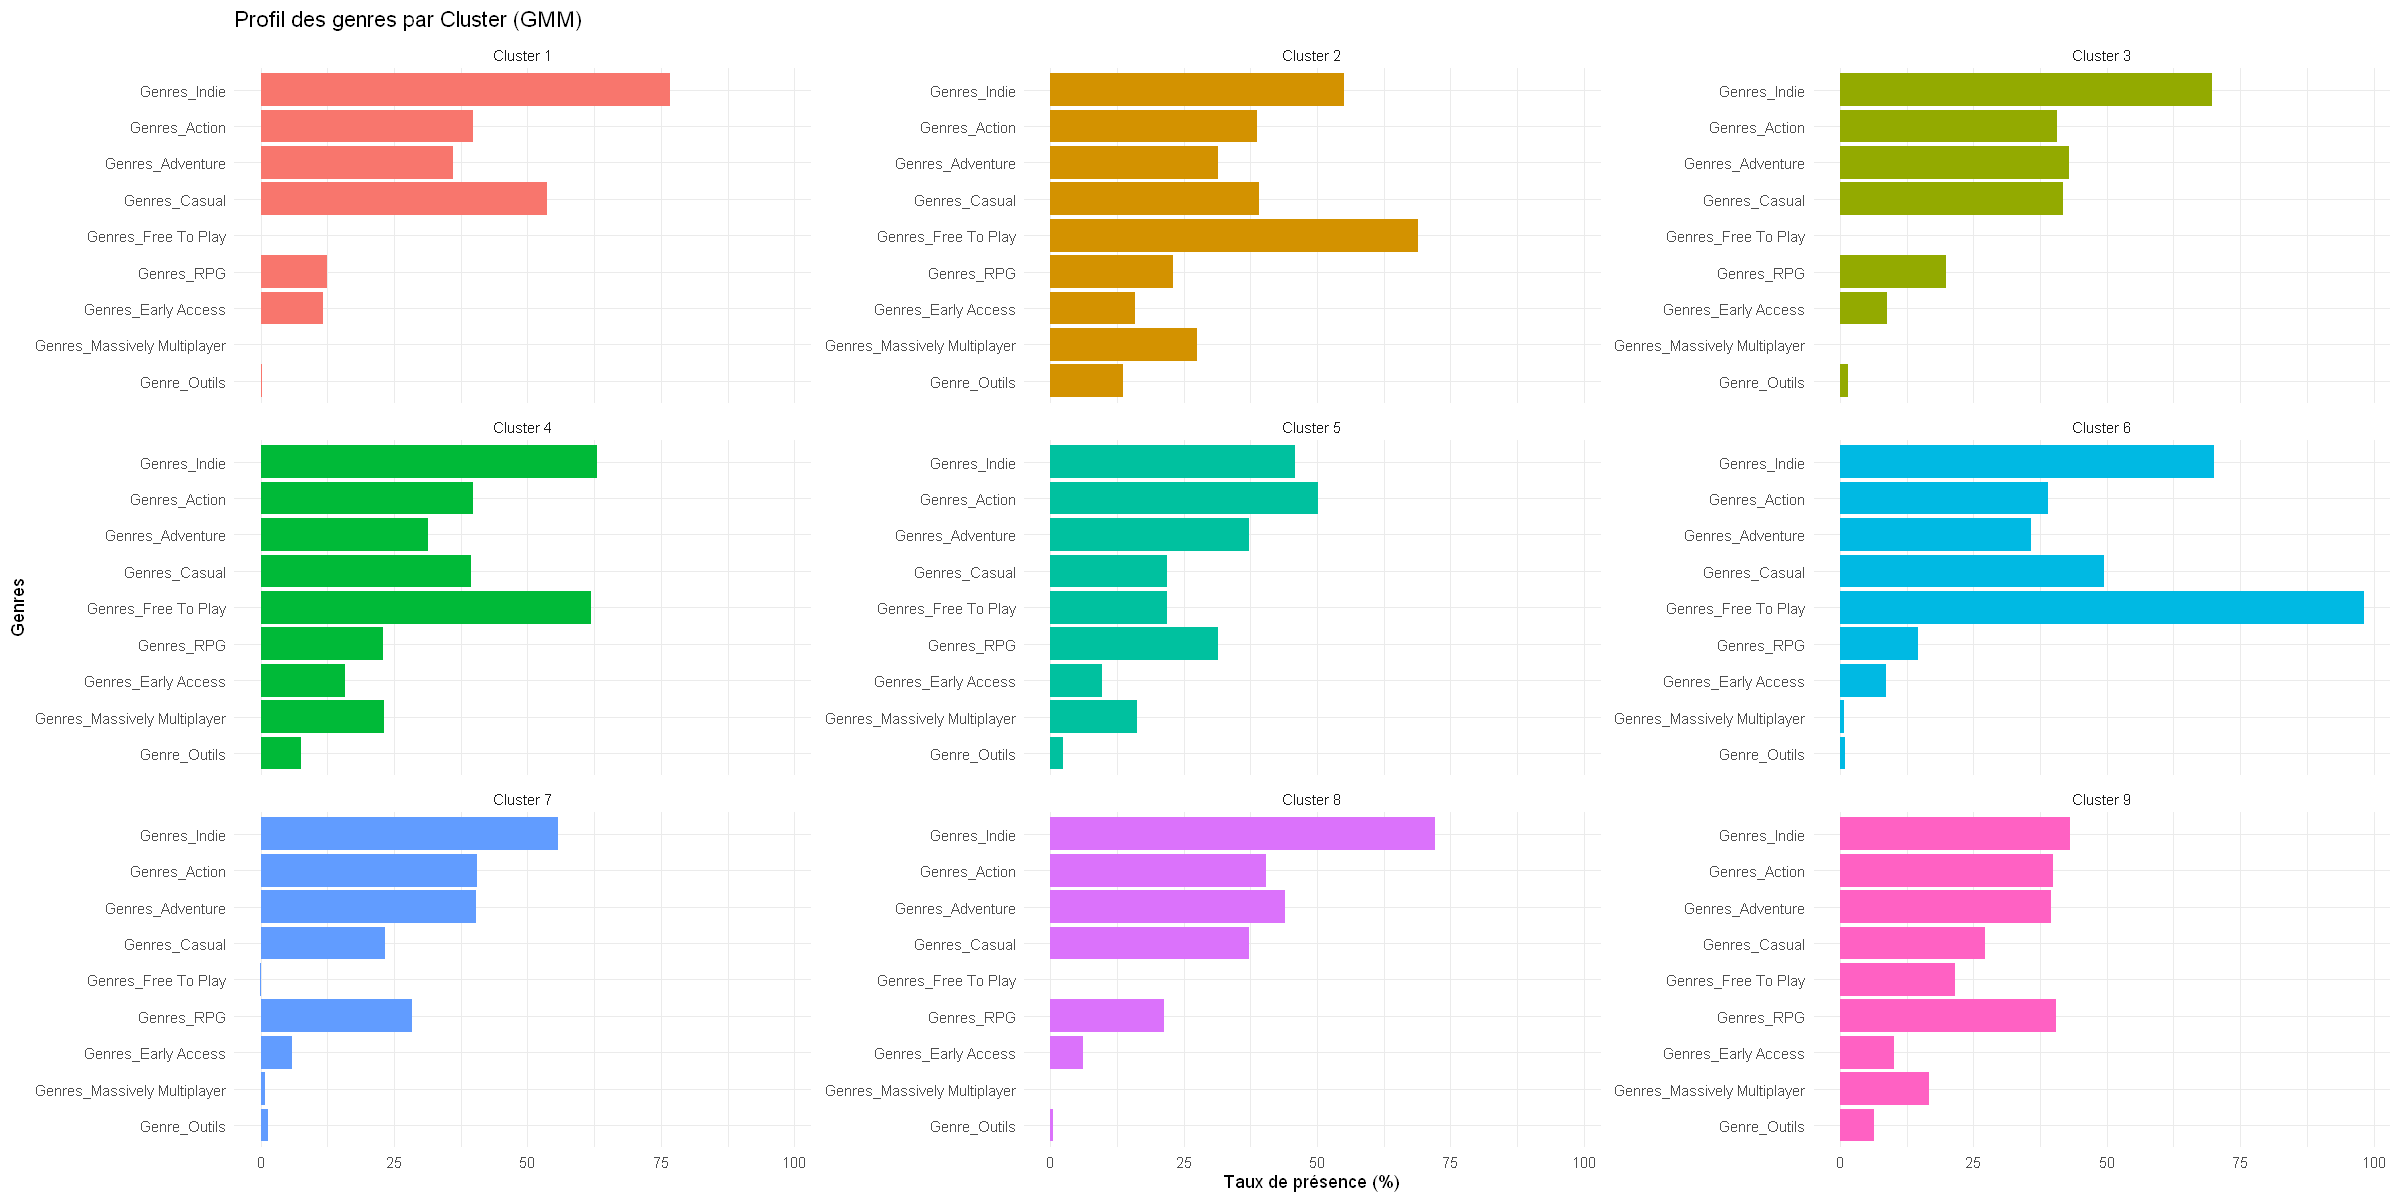

In [121]:
df_plot <- as.data.frame(comparaison_genres * 100)
df_plot$Genre <- rownames(df_plot)
df_long <- pivot_longer(df_plot, cols = starts_with("Cluster"), 
                        names_to = "Cluster", values_to = "Pourcentage")


ggplot(df_long, aes(x = reorder(Genre, Pourcentage), y = Pourcentage, fill = Cluster)) +
  geom_bar(stat = "identity") +
  coord_flip() + 
  facet_wrap(~Cluster, scales = "free_y") + 
  theme_minimal() +
  labs(title = "Profil des genres par Cluster (GMM)",
       x = "Genres",
       y = "Taux de présence (%)") +
  theme(legend.position = "none")


1. Le Pôle d'Excellence : Les "Blockbusters" et Hits Établis (Clusters 9 et 3)
Ce segment représente l'élite de la plateforme.

Profil Quantitative : Le Cluster 9 domine tous les indicateurs de performance (LPeak.CCU : 5.09, Average.playtime.two.weeks : 2318.29). Le Cluster 3 se distingue par la meilleure reconnaissance critique (Metacritic.score : 23.44).

Influences Qualitatives : Ces clusters capturent l'intégralité des très gros succès commerciaux (75 % du segment 100M-200M d'owners pour le Cluster 9).

ADN Éditorial : Ce sont les groupes les moins dépendants du label Genres_Indie (seulement 43.4 % pour le Cluster 9). Ils sont portés par des genres à forte valeur ajoutée comme le Genres_RPG (40.2 %) et l'Adventure, souvent associés à des prix élevés (LPrice : 1.84 à 1.89) et une forte internationalisation.

2. Le Pôle d'Engagement Communautaire : Les "Piliers de Rétention" (Cluster 8)
Ce cluster illustre un modèle basé sur la fidélisation plutôt que sur la simple vente.

Profil Quantitative : Il affiche le record de succès (Achievements : 54.50) et un temps de jeu récent très solide (137.13).

Influences Qualitatives : Il domine les segments de succès "soutenus" (78 % des jeux ayant entre 10M et 20M d'owners).

ADN Éditorial : Sa force réside dans les genres Genres_Action (46.83 %) et Genres_RPG (28.88 %), mixant titres payants et modèles Genres_Free To Play (36.94 %).

3. Le Pôle Historique et Commercial (Cluster 6)
Ce segment représente la "mémoire" de Steam.

Profil Quantitative : Caractérisé par des stratégies de promotion agressives (Discount : 42.33 %) pour maintenir la visibilité d'un catalogue ancien.

Influences Qualitatives : Il regroupe près de 50 % des jeux sortis entre 1997 et 2014.

ADN Éditorial : Très ancré dans le duo classique Genres_Action (42.78 %) et Genres_Adventure (47.44 %), avec très peu d'accès anticipés.

4. La Masse Critique : Le "Ventre Mou" et les Niches (Clusters 1, 2, 5, 7)
Ces groupes représentent la majorité des publications, mais la plus faible part de revenus.

Le Cluster 1 (Flux récent) : Incarne l'hyper-croissance actuelle de Steam. Il capte 54.4 % des sorties très récentes (2025-2026) mais affiche un engagement quasi nul. Il est saturé par le modèle Genres_Indie (77.75 %) et Genres_Casual (54.49 %).

Les Clusters 2 et 7 (Niches Gratuites) : Isolent les modèles Genres_Free To Play (jusqu'à 97.28 % pour le Cluster 2) et le multijoueur de niche. Malgré une forte accessibilité, ils peinent à sortir de l'anonymat statistique en dehors de leur gratuité.

Synthèse Finale
L'étude démontre que la réussite sur Steam (Cluster 9) repose sur une rupture avec le modèle "Indie-Casual" massif. Le succès semble corrélé à la capacité d'un titre à s'extraire de la masse des sorties récentes (Cluster 1) par une combinaison de trois facteurs : une complexité de genre (RPG/Aventure), une portée internationale (Langues) et une profondeur de contenu (DLC/Achievements). À l'inverse, une grande partie du catalogue actuel (Clusters 1 et 5) reste invisible, noyée sous un volume de publications record qui ne rencontre pas son public


Pour vérifier les conclusions précédentes nous nous sommes ensuite demandés quelles étaient les caractéristiques intrinsèques à un jeux pour avoir du succès sur Steam. Nous passons donc à notre deuxième étude:

 **Quels sont les variables intrinsèques à un jeu qui caractérisent le succès sur Steam? Et parmi les jeux à succès, peut-on etablir des classes de succès?**

## Variables intrinsèque d'un jeux qui caractérisent le succès

Afin de repondre à cette question nous allons réaliser une FAMD sur les variables qui définissent une jeux comme son nombre de langues, son prix, son genre etc... Pour cette étude nous avons don restreint nos variables en supprimant tous les attributs liés aux conséquence qu'un jeu marche ou non comme *LPositive* ou *Average.playtime* amis aussi la variable *Windows* car ce système d'exploitation est commun à pratiquement l'entièreté des jeux sur Steam mais aussi la date de sortie car on ne peux pas sortir des jeux autrement que cette année. Et enfin nous n'avons pas pris en compte certaines variable car nous ne trouvons pas utile de les étudier. Pour voir si un axe expliquait le succès nous avons gardé en variables supplémentaires les variables *Estimated.owners* et *LRecommendations* car nous considérons que c'est ces variables la qui définissent le succès à l'échelle d'un jeux vidéos.

In [137]:
data_famd_succes<- df_mca_ready %>% select(-c(Required.age,Windows,Release.date,Name,Metacritic.score,Achievements,Average.playtime.two.weeks,User.score,Median.playtime.two.weeks,Developers,Publishers,
                                     Categories,Tags,Language,LPositive,LNegative,LAverage.playtime.forever,LMedian.playtime.forever,LPeak.CCU,Genre_Video))

summary(data_famd_succes)


  Estimated.owners    Discount         Mac          Linux      
 0-20K    :75337   Min.   :  0.00   False:93260   False:98841  
 0        :13649   1st Qu.:  0.00   True :21253   True :15672  
 20K-50K  :11395   Median :  0.00                              
 50K-100K : 5349   Mean   : 19.62                              
 100K-200K: 3450   3rd Qu.: 45.00                              
 200K-500K: 2845   Max.   :100.00                              
 (Other)  : 2488                                               
 LRecommendations     LPrice         LDLC.count     LLanguageCount  
 Min.   : 0.000   Min.   :0.0000   Min.   :0.0000   Min.   :0.0000  
 1st Qu.: 0.000   1st Qu.:0.6366   1st Qu.:0.0000   1st Qu.:0.6931  
 Median : 0.000   Median :1.3056   Median :0.0000   Median :0.6931  
 Mean   : 1.169   Mean   :1.3083   Mean   :0.1583   Mean   :1.2921  
 3rd Qu.: 0.000   3rd Qu.:1.9445   3rd Qu.:0.0000   3rd Qu.:1.7918  
 Max.   :15.390   Max.   :6.9087   Max.   :8.2172   Max.   :4.6444  
     

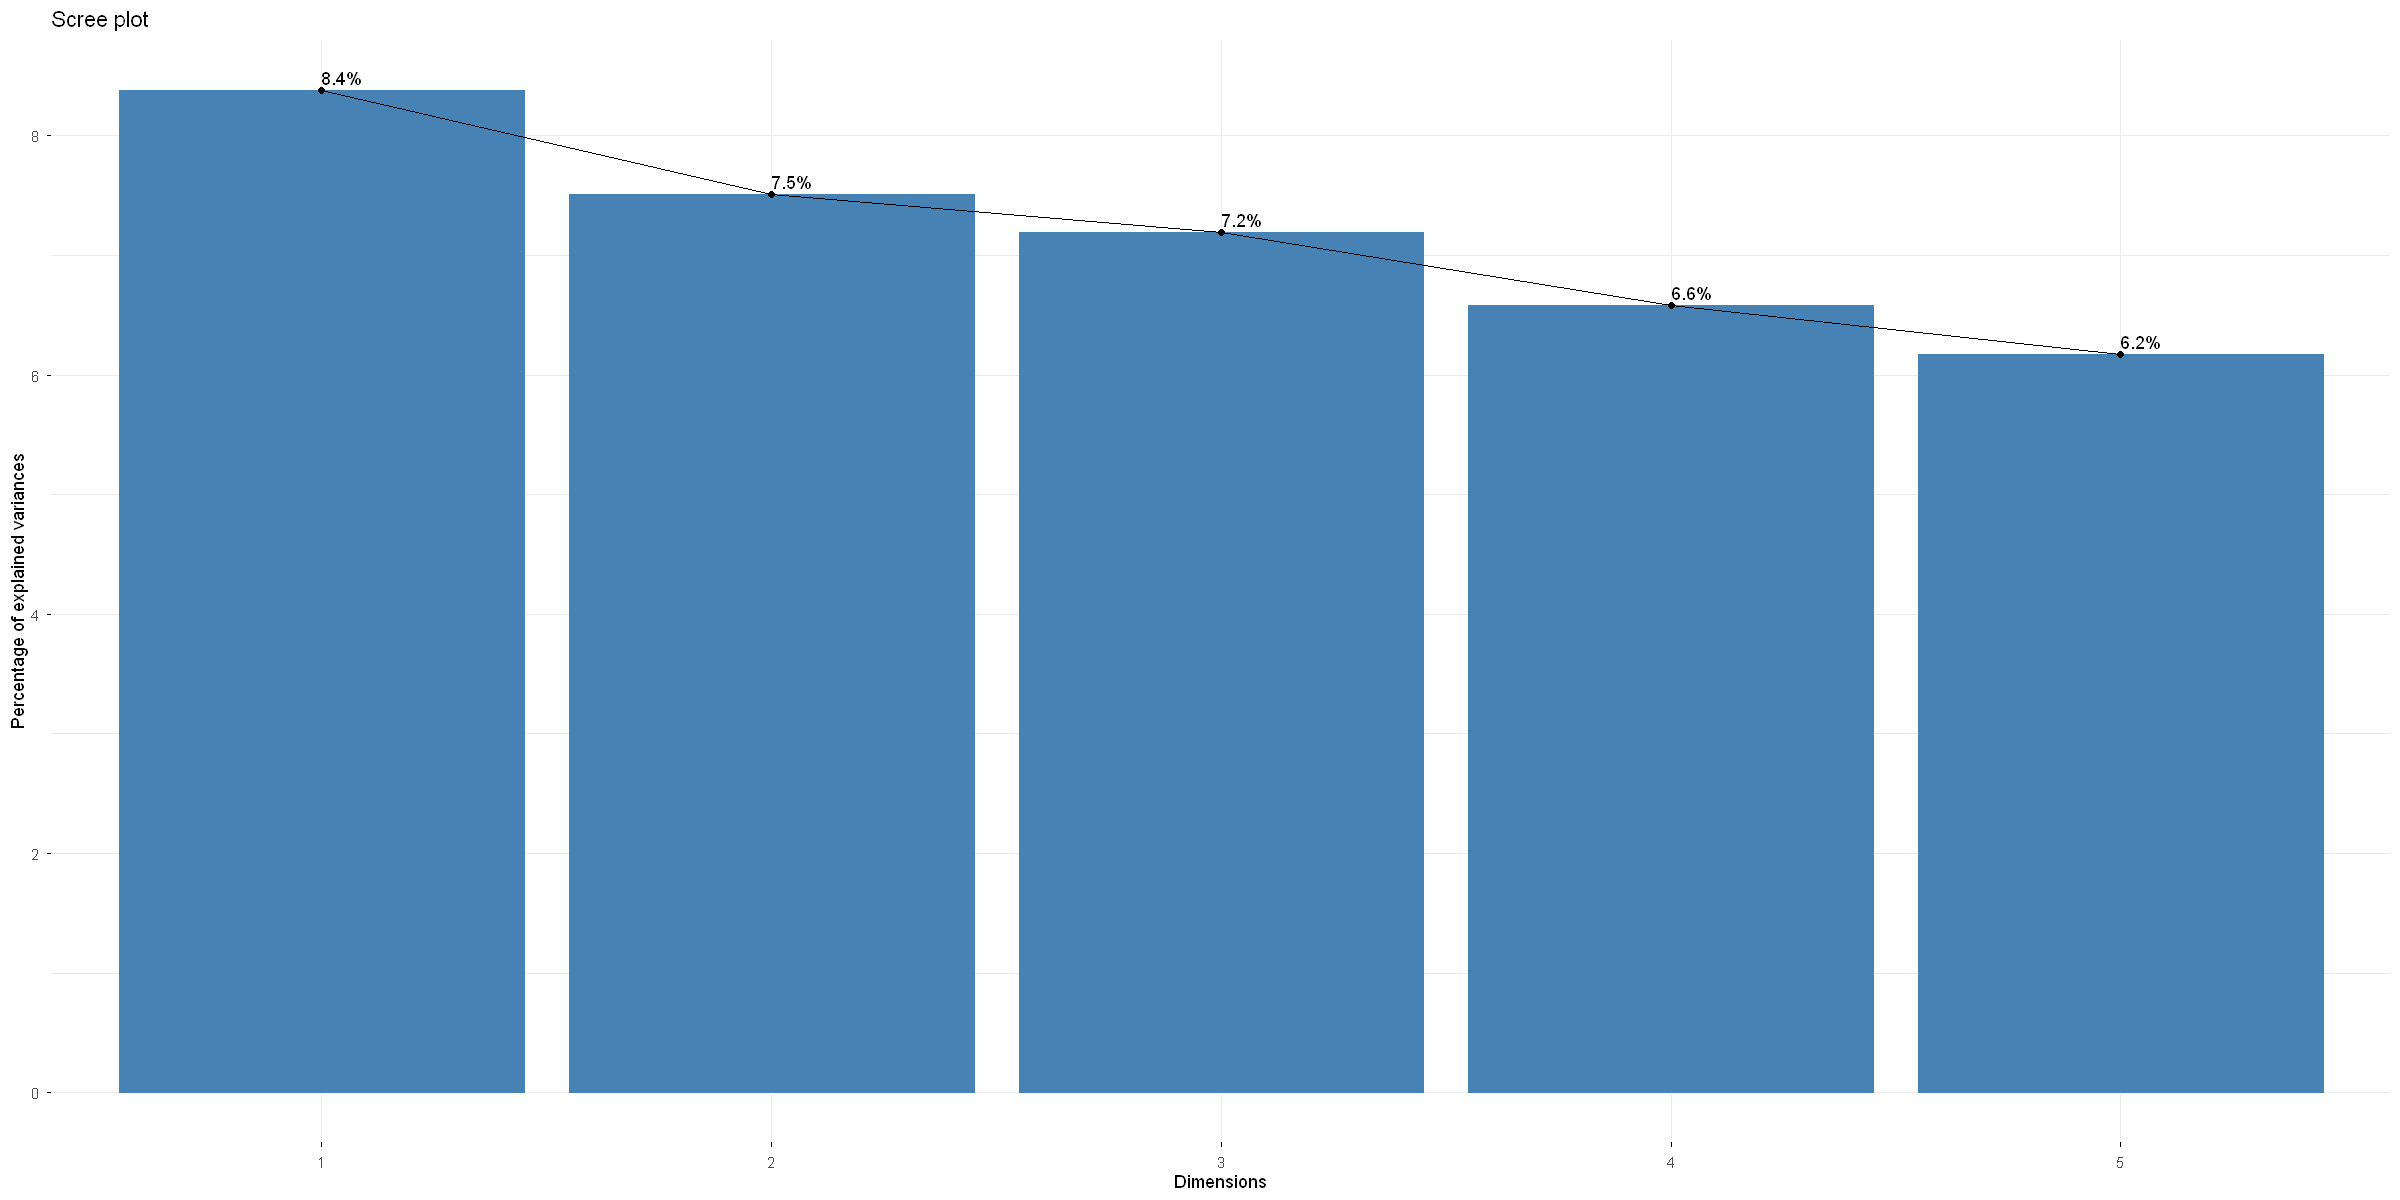

In [138]:
res_famd_succes=FAMD(data_famd_succes,sup.var=c(1,5),graph=F)
fviz_eig(res_famd_succes,addlabels = T)

Nous avons chois de garder uniquement 3 composantes principales. Etudions comment nos variables qualitatives et quantitatives  sont projeté sur le plan de la FAMD.

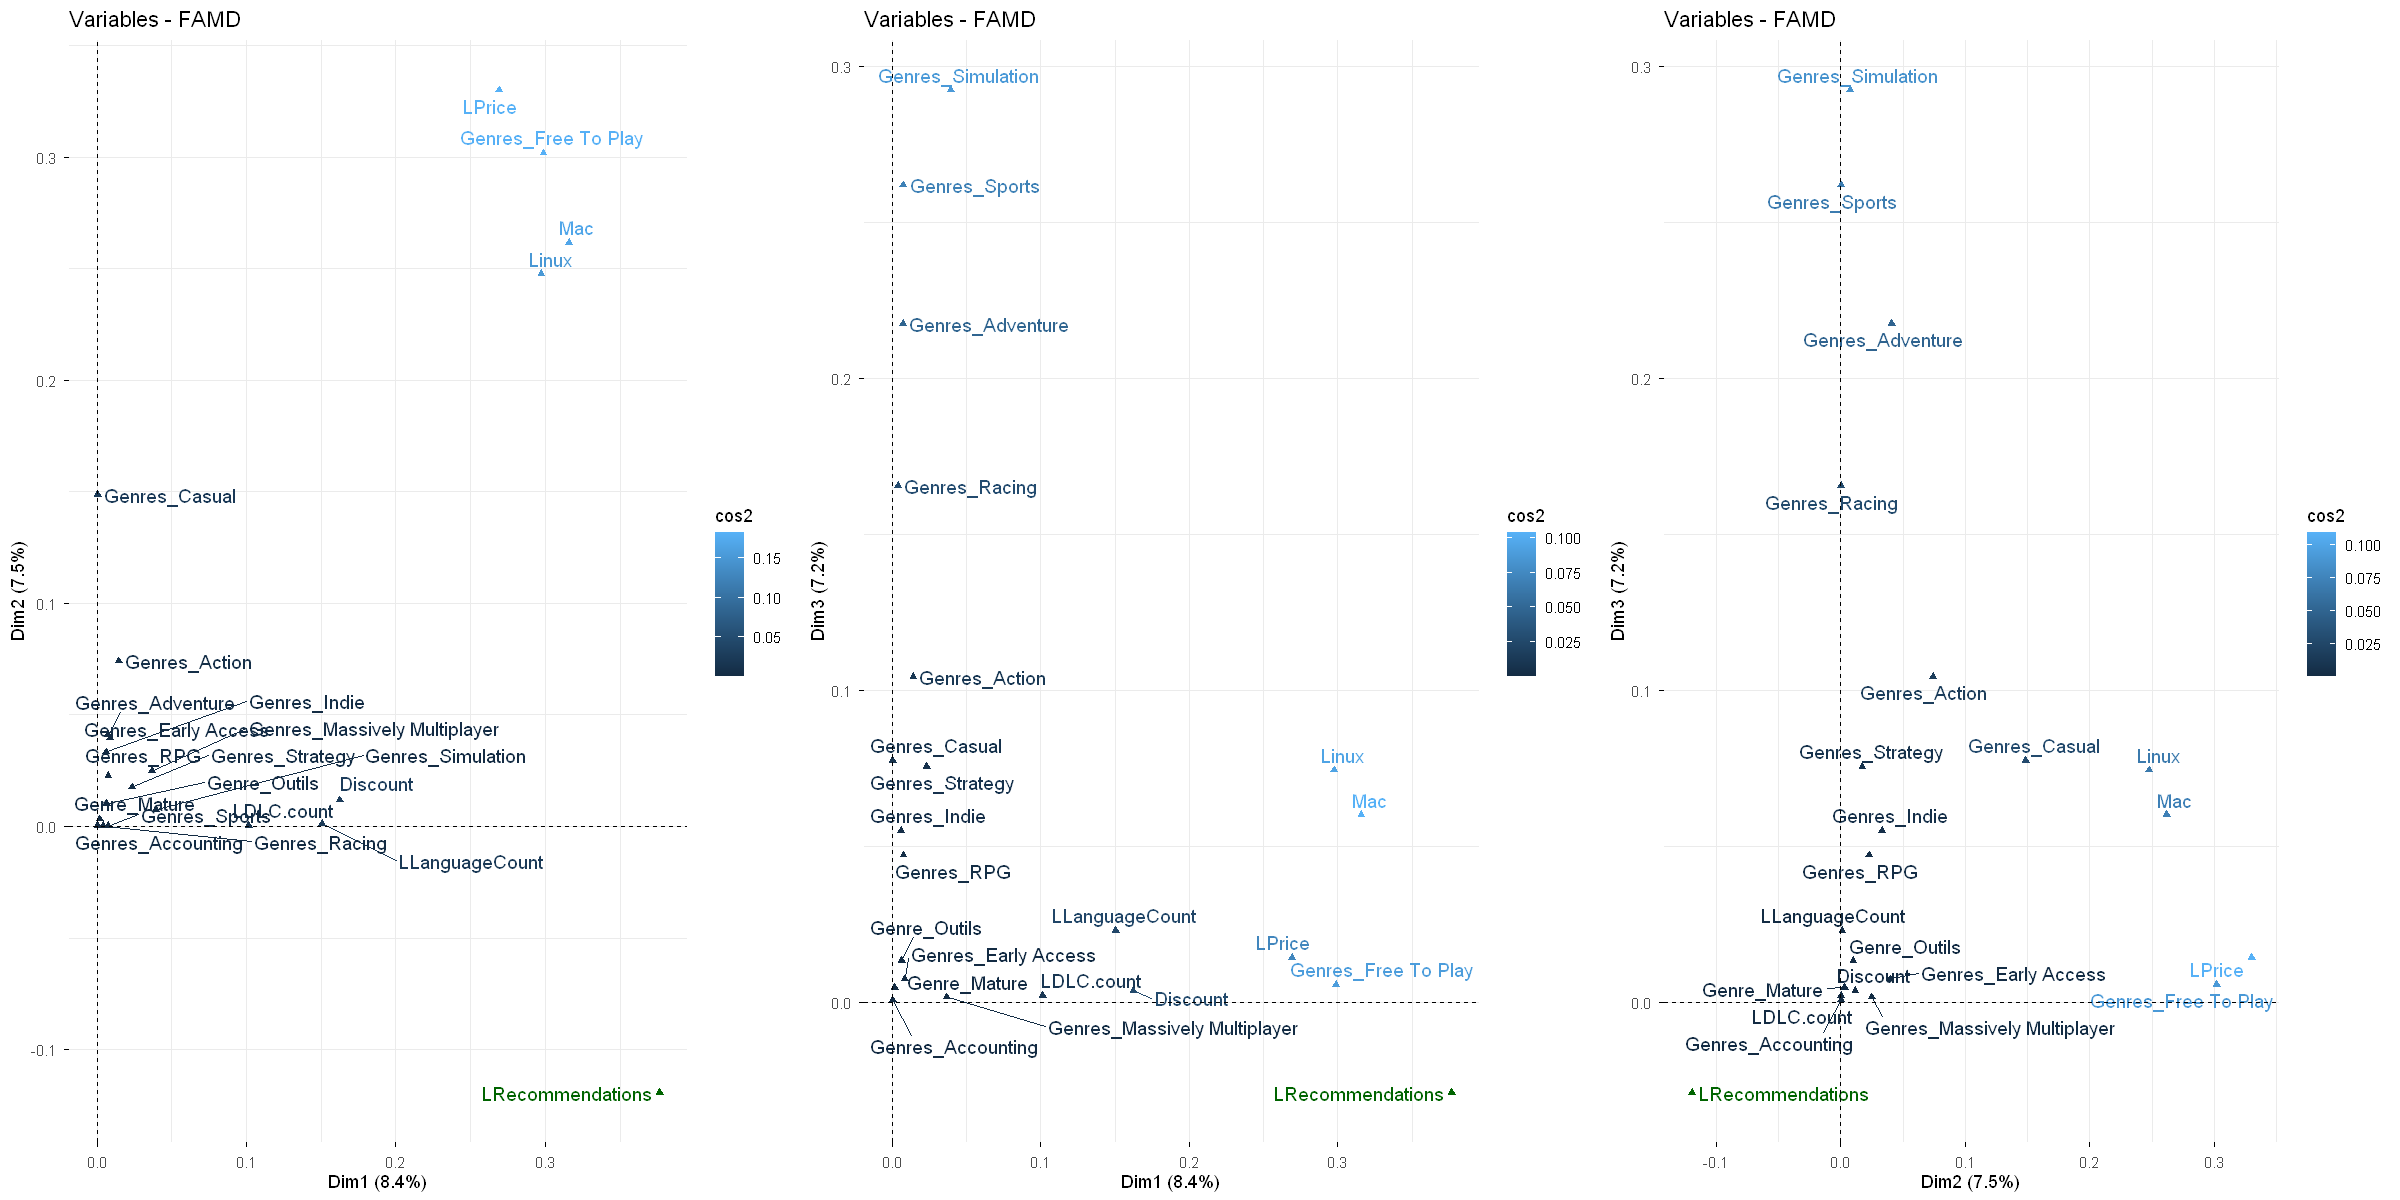

In [139]:
vq1<-fviz_famd_var(res_famd_succes,axes=c(1,2),repel=T,col.var = "cos2")
vq2<-fviz_famd_var(res_famd_succes,axes=c(1,3),repel=T,col.var = "cos2")
vq3<-fviz_famd_var(res_famd_succes,axes=c(2,3),repel=T,col.var = "cos2")

grid.arrange(vq1,vq2,vq3,ncol=3)

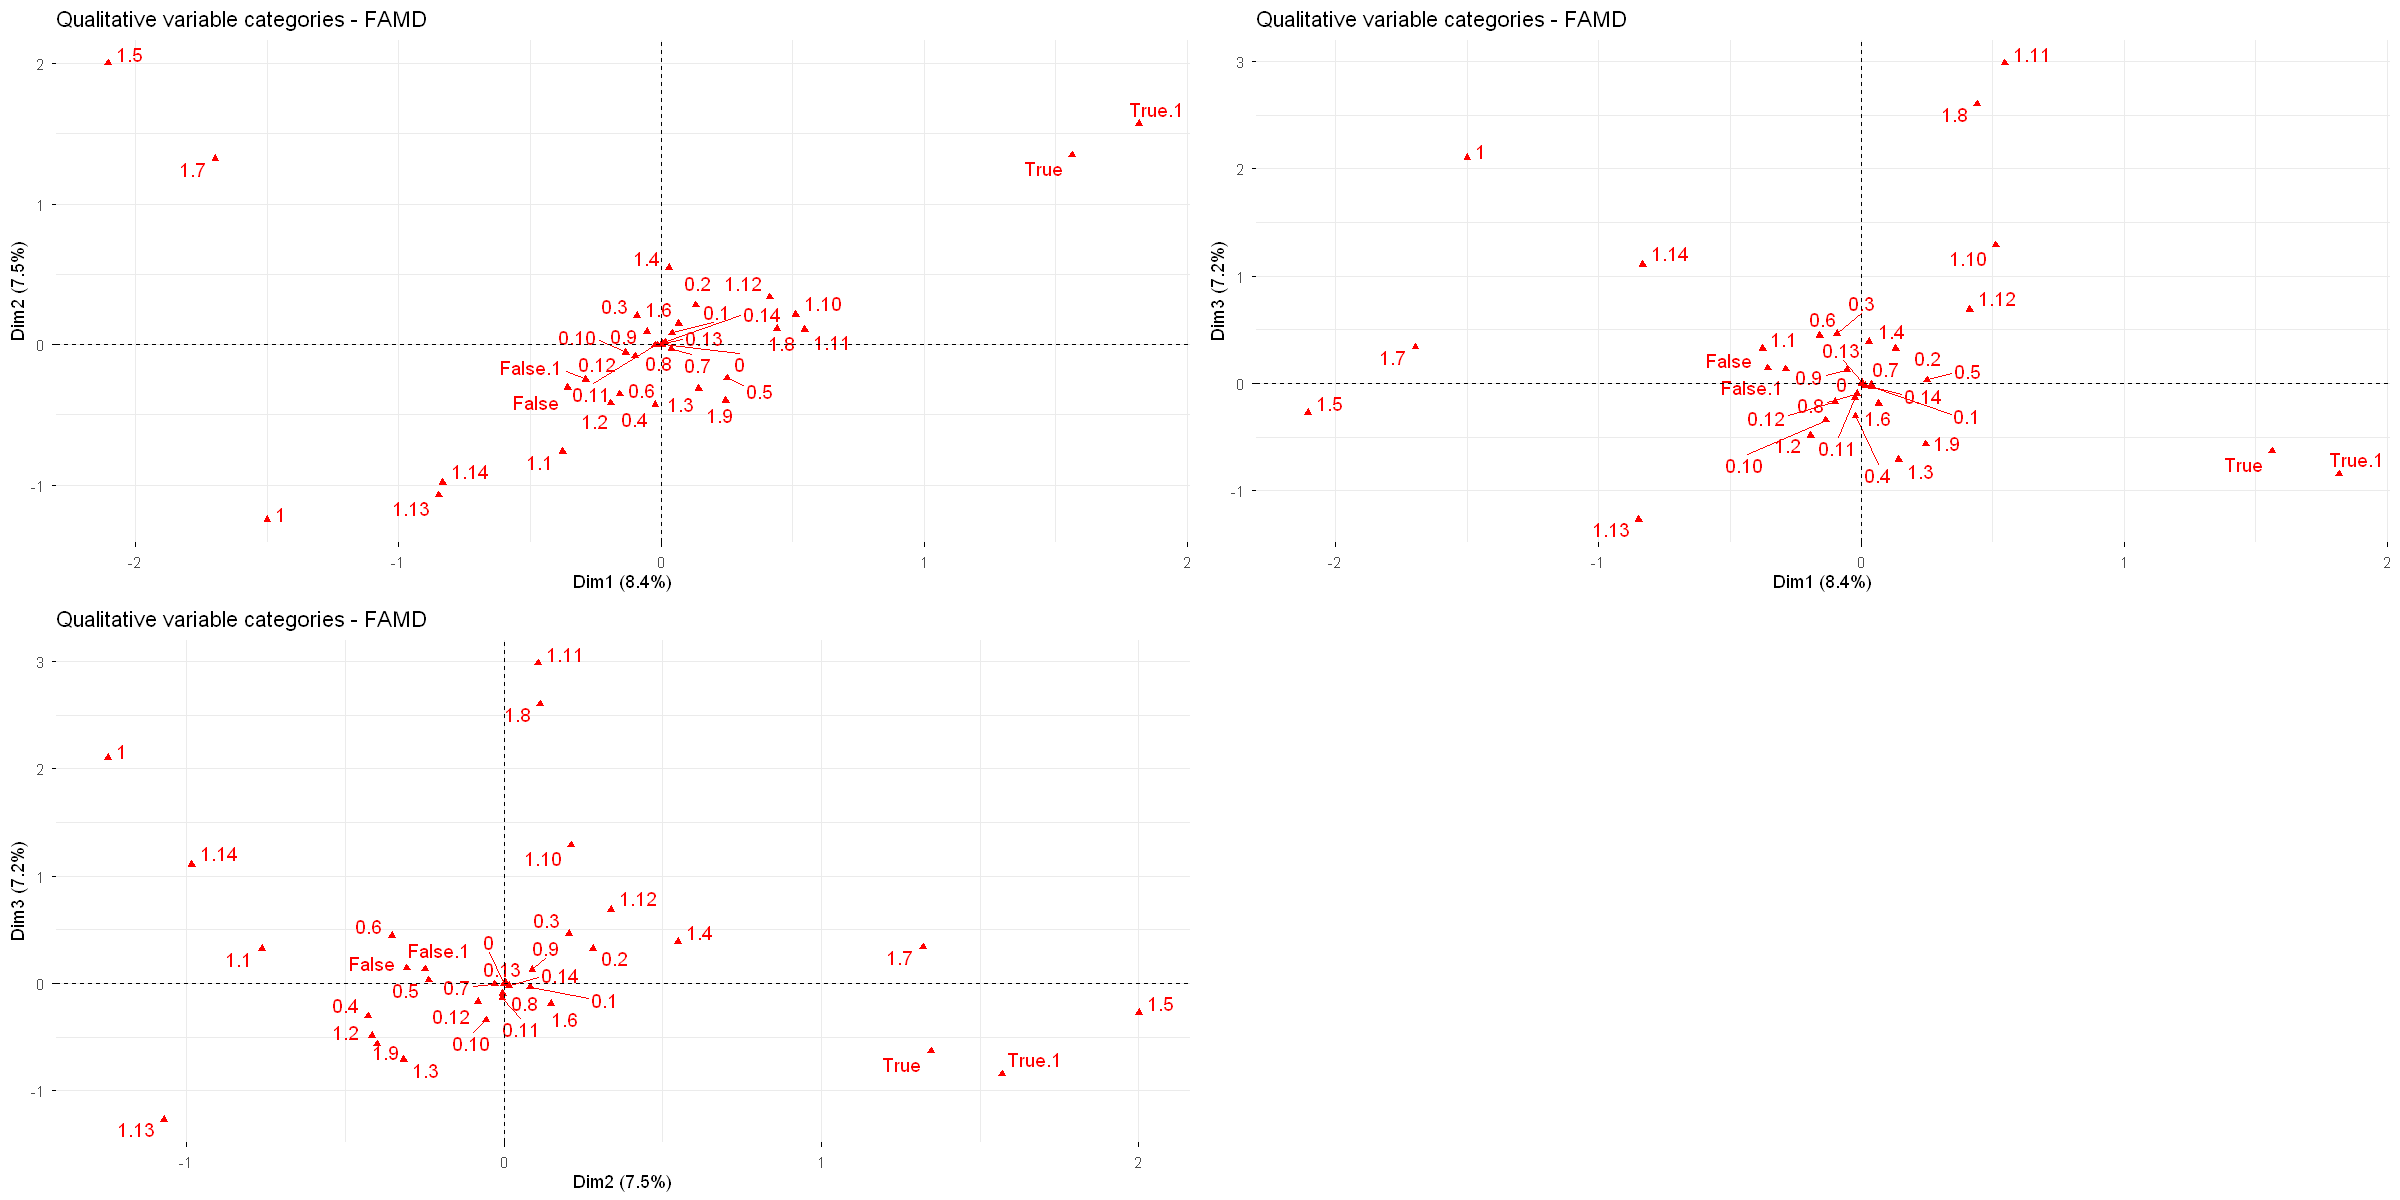

In [140]:
vql1<-fviz_famd_var(res_famd_succes, choice = "quali", repel = TRUE)
vql2<-fviz_famd_var(res_famd_succes, choice = "quali", repel = TRUE,axes=c(1,3))
vql3<-fviz_famd_var(res_famd_succes, choice = "quali", repel = TRUE,axes=c(2,3))
grid.arrange(vql1,vql2,vql3,ncol=2)

Pour la cellule suivante, nous avons garder que c'est deux graphes car c'est ceux montraient un intérêt plus important pour l'étude.

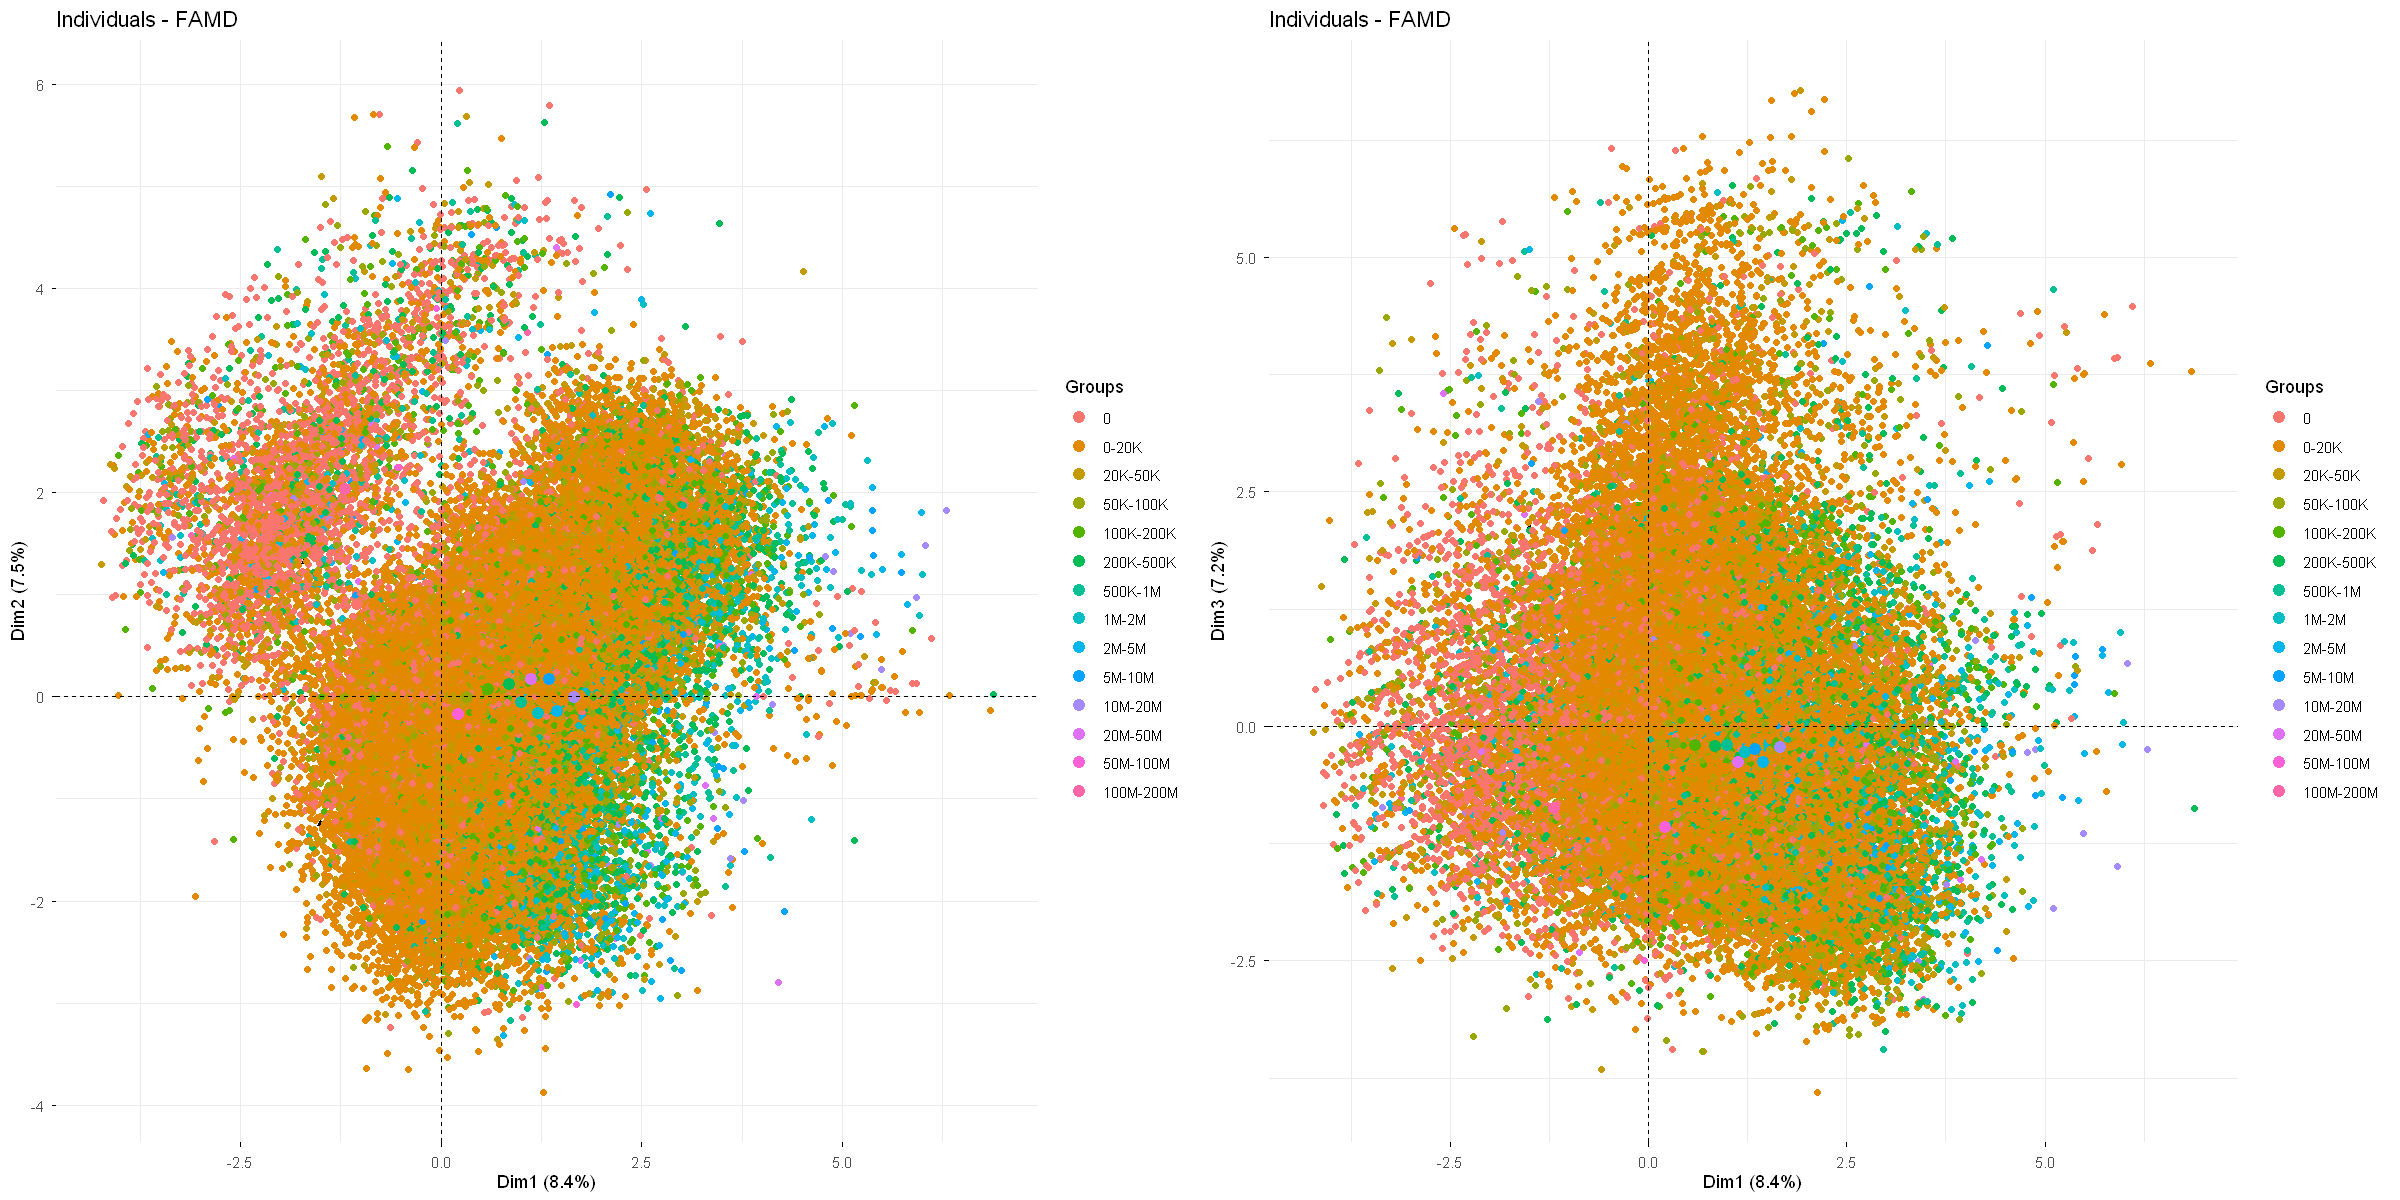

In [141]:
i1<-fviz_famd_ind(res_famd_succes, repel = F,habillage =data_famd_succes$Estimated.owners,label="none",axes=c(1,2))
i2<-fviz_famd_ind(res_famd_succes, repel = F,habillage =data_famd_succes$Estimated.owners,label="none",axes=c(1,3))

grid.arrange(i1,i2,ncol=2)

**Conclusion**: 

Le premier axe d'analyse met en évidence ce qui définit véritablement le succès et l'envergure d'un jeu sur Steam. Visuellement, le graphique des individus révèle une transition : les titres à faible audience (moins de 20 000 joueurs) s'agglutinent sur le côté gauche, tandis que les gros succès commerciaux (de 10 à 200 millions de joueurs) se concentrent systématiquement sur le côté droit. Cette dynamique de réussite, confirmée par le fort volume de recommandations, est directement propulsée par deux éléments concrets : la quantité de langues disponibles et le nombre de contenus additionnels (DLC). Cela démontre que l'ampleur du succès dépend bien moins du genre du jeu que de son passage à l'échelle commerciale, rendu possible par une accessibilité internationale et un suivi régulier du contenu.

Le deuxième axe illustre quant à lui le modèle économique et l'effort technique du studio. Il sépare de façon très nette les productions dites "standards" (généralement exclusives à Windows et à prix classique) des productions "premium". Ces dernières se démarquent par un prix de vente plus élevé, une infrastructure Free-To-Play, ou encore un effort d'intsallation sur les systèmes Mac et Linux. Toutefois, l'analyse montre que cet effort technique et tarifaire sert uniquement à positionner le jeu sur un segment de marché précis. Ce n'est en aucun cas une garantie de ventes : un jeu vendu plus cher ou compatible Linux ne se dirige pas automatiquement vers la zone des grands succès commerciaux.

Pour conclure, le jeu à succès type sur Steam n'est pas défini par son genre (Indie, Action ect..). Il se caractérise avant tout par un investissement massif dans l'internationalisation (beaucoup de langues) et la le nombre l'enrichissement continu du contenu (DLC).Le prix de vente et la disponibilité sur Mac ou Linux sont des choix secondaires : ils différencient le jeu des autres, mais ce n'est pas ce qui fait exploser les ventes.


Maintenant que nous avons réussi à trouver que les variables *Language.count* et *LDLC.count* permettaient aux jeux de devenir connus et d'avoir beaucoup d'utilisateurs (*Estimated.owners*) et de bonnes recommendations(*LRecommendations*) et non pas d'un genre en particulier ou bien du prix du jeux, nous allons rentrer dans la deuxième partie de notre étude: c'est à dire, parmi les jeux vidéos ayant du succès, peut-on établir des classes avec des caractéristiques précises par tranches de succès?

## Etude jeux à succès

**Pour lila**

## Etude de l'évolution du marché des jeux depuis les années 2000

In [168]:


# --- ÉTAPE 2 : Combiner l'année avec ton dataset des 20 genres ---
df_analyse_temps <- cbind(df_genre_mca_100, annee = data_ready$Release.date)

# --- ÉTAPE 3 : Calculer le nombre de sorties par année et par genre ---
evolution_genres <- df_analyse_temps %>%
  # On groupe par année
  group_by(annee) %>%
  # On fait la somme des 1 pour chaque genre
  summarise(across(everything(), sum)) %>%
  # On repasse en format long pour ggplot
  pivot_longer(cols = -annee, names_to = "Genre", values_to = "Nombre_de_jeux")

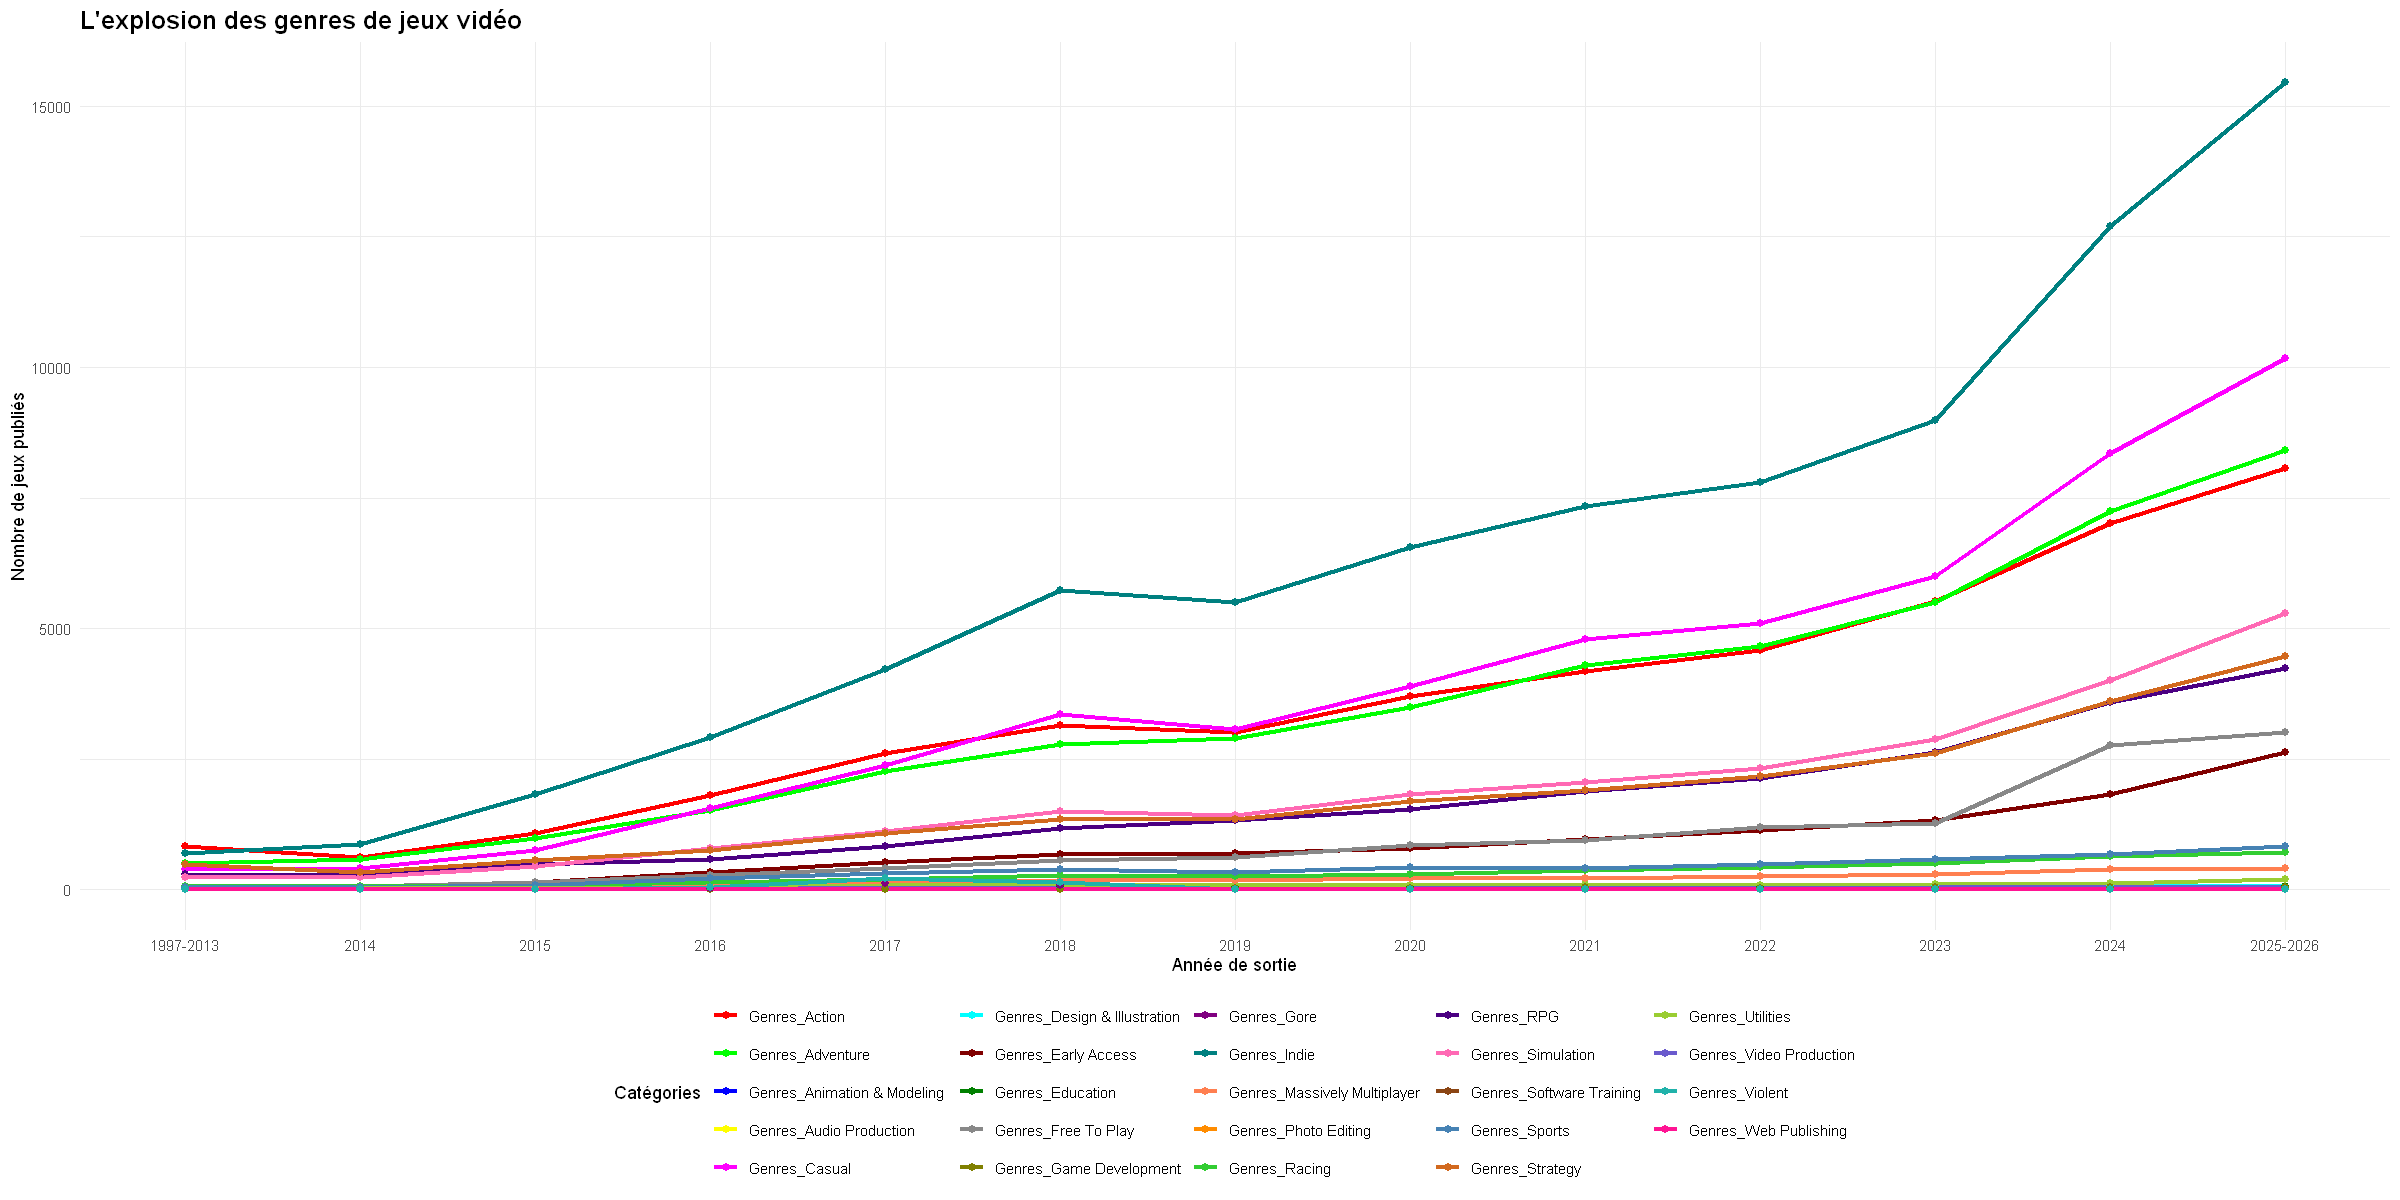

In [169]:
palette_24_couleurs <- c(
  "#FF0000", "#00FF00", "#0000FF", "#FFFF00", "#FF00FF", "#00FFFF", 
  "#800000", "#008000", "#888888", "#808000", "#800080", "#008080", 
  "#FF7F50", "#FF8C00", "#32CD32", "#4B0082", "#FF69B4", "#8B4513", 
  "#4682B4", "#D2691E", "#9ACD32", "#6A5ACD", "#20B2AA", "#FF1493"
)

# 2. Ton graphique
ggplot(evolution_genres, aes(x = annee, y = Nombre_de_jeux, color = Genre, group = Genre)) +
  geom_line(linewidth = 1.2) + 
  geom_point(size = 2) +       
  scale_color_manual(values = palette_24_couleurs) + 
  theme_minimal() +
  labs(
    title = "L'explosion des genres de jeux vidéo ",
    x = "Année de sortie",
    y = "Nombre de jeux publiés",
    color = "Catégories"
  ) +
  theme(
    legend.position = "bottom",
    plot.title = element_text(face = "bold", size = 15)
  )

On remarque une croissance qui débute clairement lors de l'année 2015 pour les genres les plus mainstreams comme Action, Casual, Adventure etc..

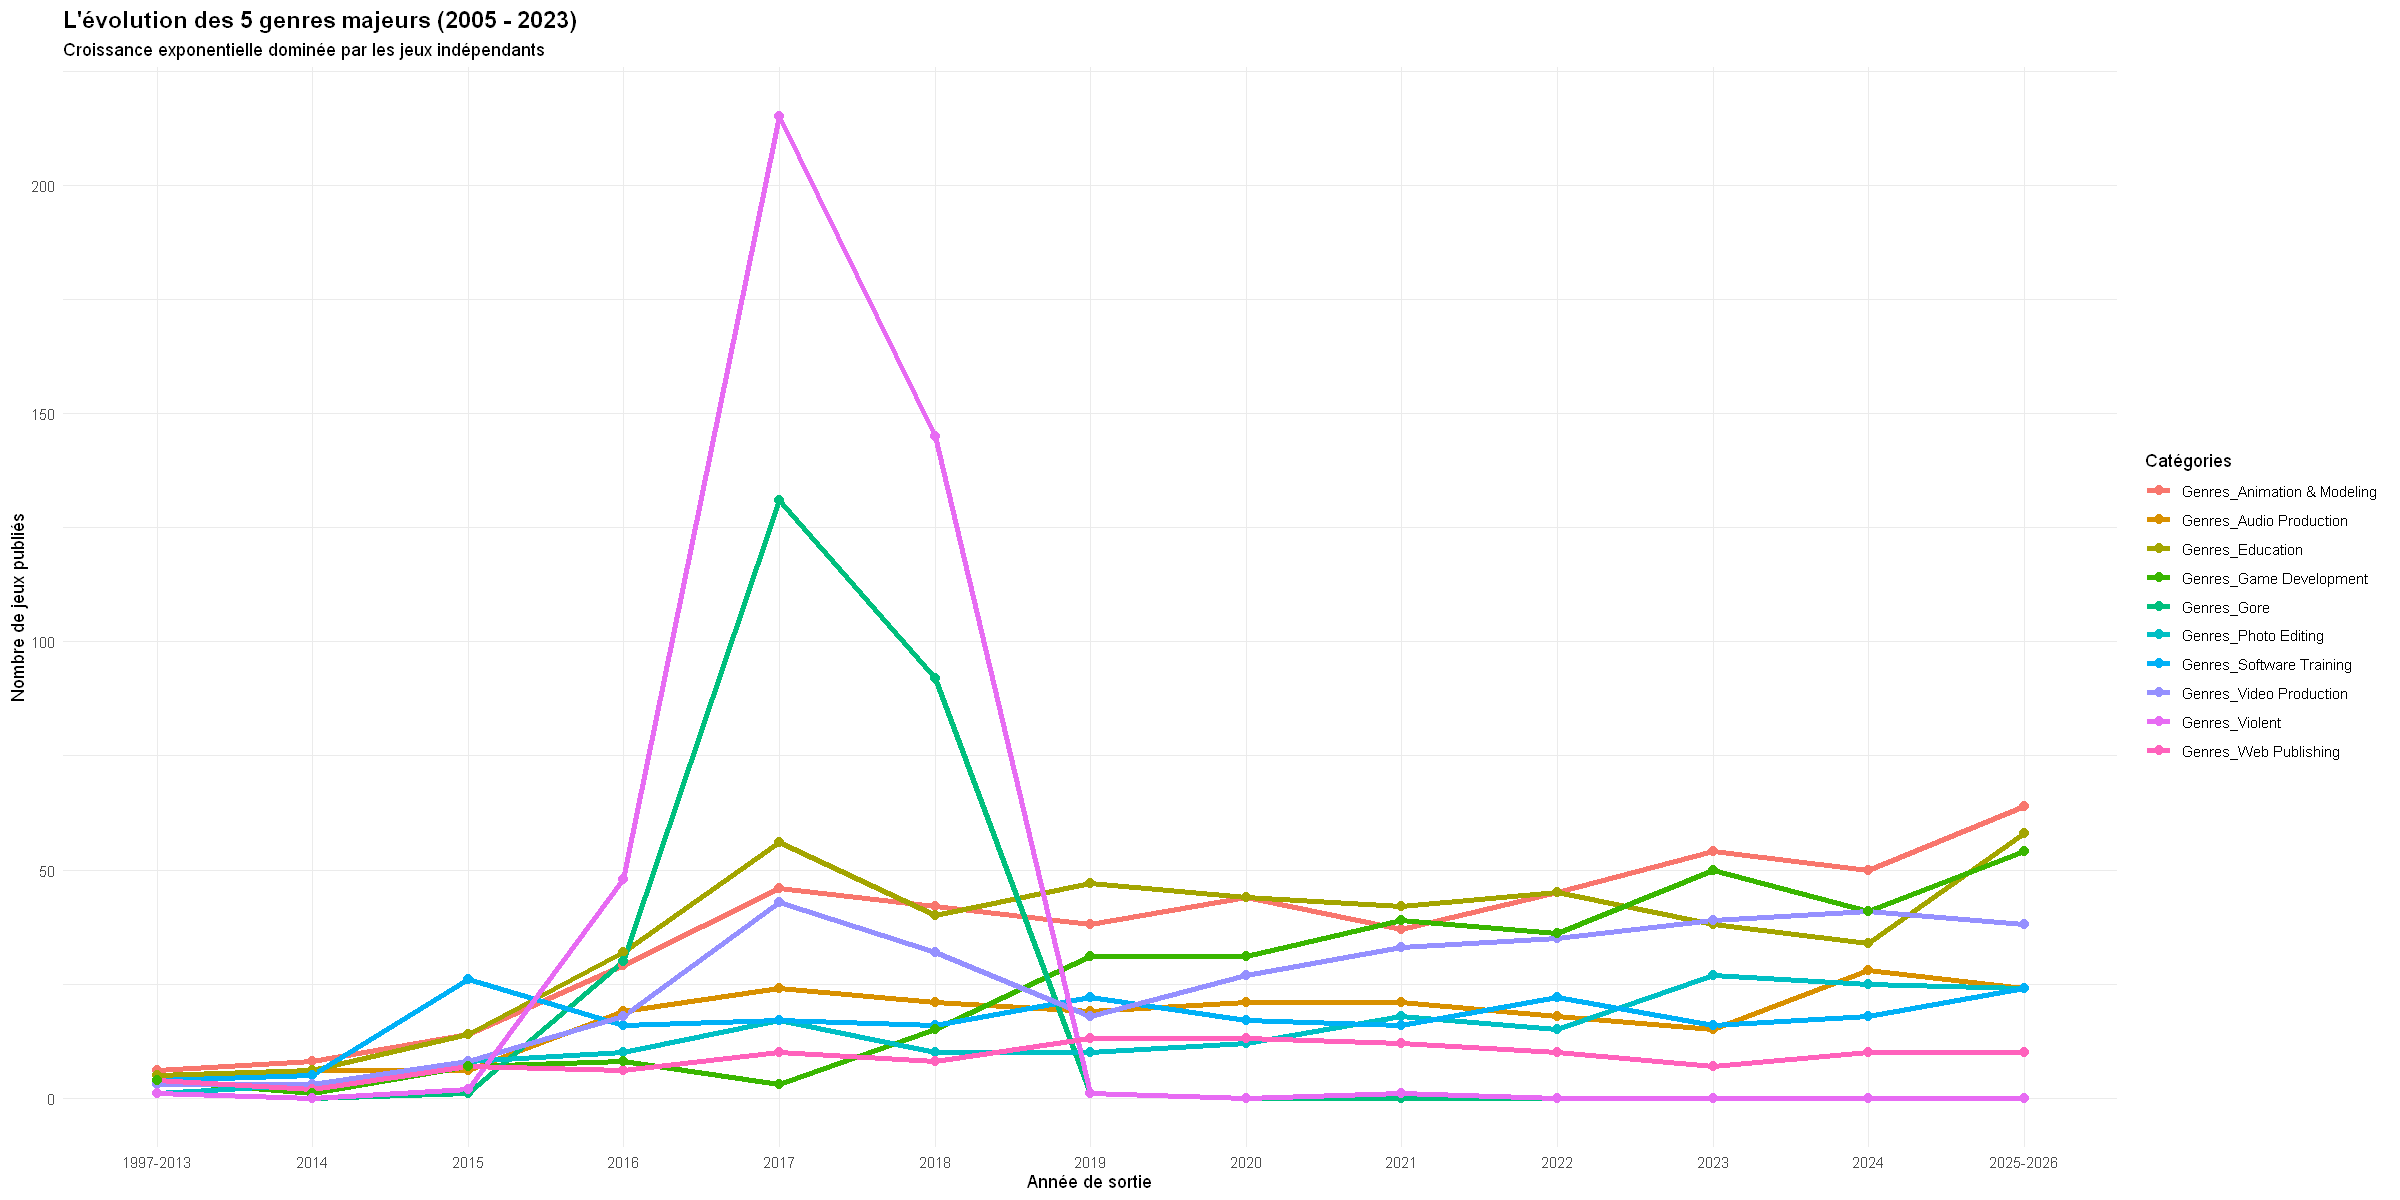

In [170]:

# 1. Trouver les noms des 5 plus petit genres
top_10_noms <- df_genre_mca_100 %>%
  summarise(across(everything(), sum)) %>%
  pivot_longer(everything(), names_to = "Genre", values_to = "Total") %>%
  slice_max(order_by = -Total, n = 10) %>%
  pull(Genre)

# 2. Filtrer les données d'évolution pour ce Top 10
evolution_top10 <- evolution_genres %>%
  filter(Genre %in% top_10_noms) 

# 3. Le graphique épuré
ggplot(evolution_top10, aes(x = annee, y = Nombre_de_jeux, color = Genre, group = Genre)) +
  geom_line(linewidth = 1.5) + # Ligne un peu plus épaisse
  geom_point(size = 2.5) +
  theme_minimal() +
  labs(
    title = "L'évolution des 5 genres majeurs (2005 - 2023)",
    subtitle = "Croissance exponentielle dominée par les jeux indépendants",
    x = "Année de sortie",
    y = "Nombre de jeux publiés",
    color = "Catégories"
  ) +
  theme(
    legend.position = "right",
    plot.title = element_text(face = "bold", size = 14)
  )

on remarque l'explosion des jeux gore et violent autour des années 2017 puis d'un retour à la "normale" après cette période.

A partir de 2023 il y a eu une nette augmentation des nouveaux jeux pour les genres plus communs en revanche pour les jeux plus niches, le nombre de nouveaux jeux restent constantes voire augmentes légèrement

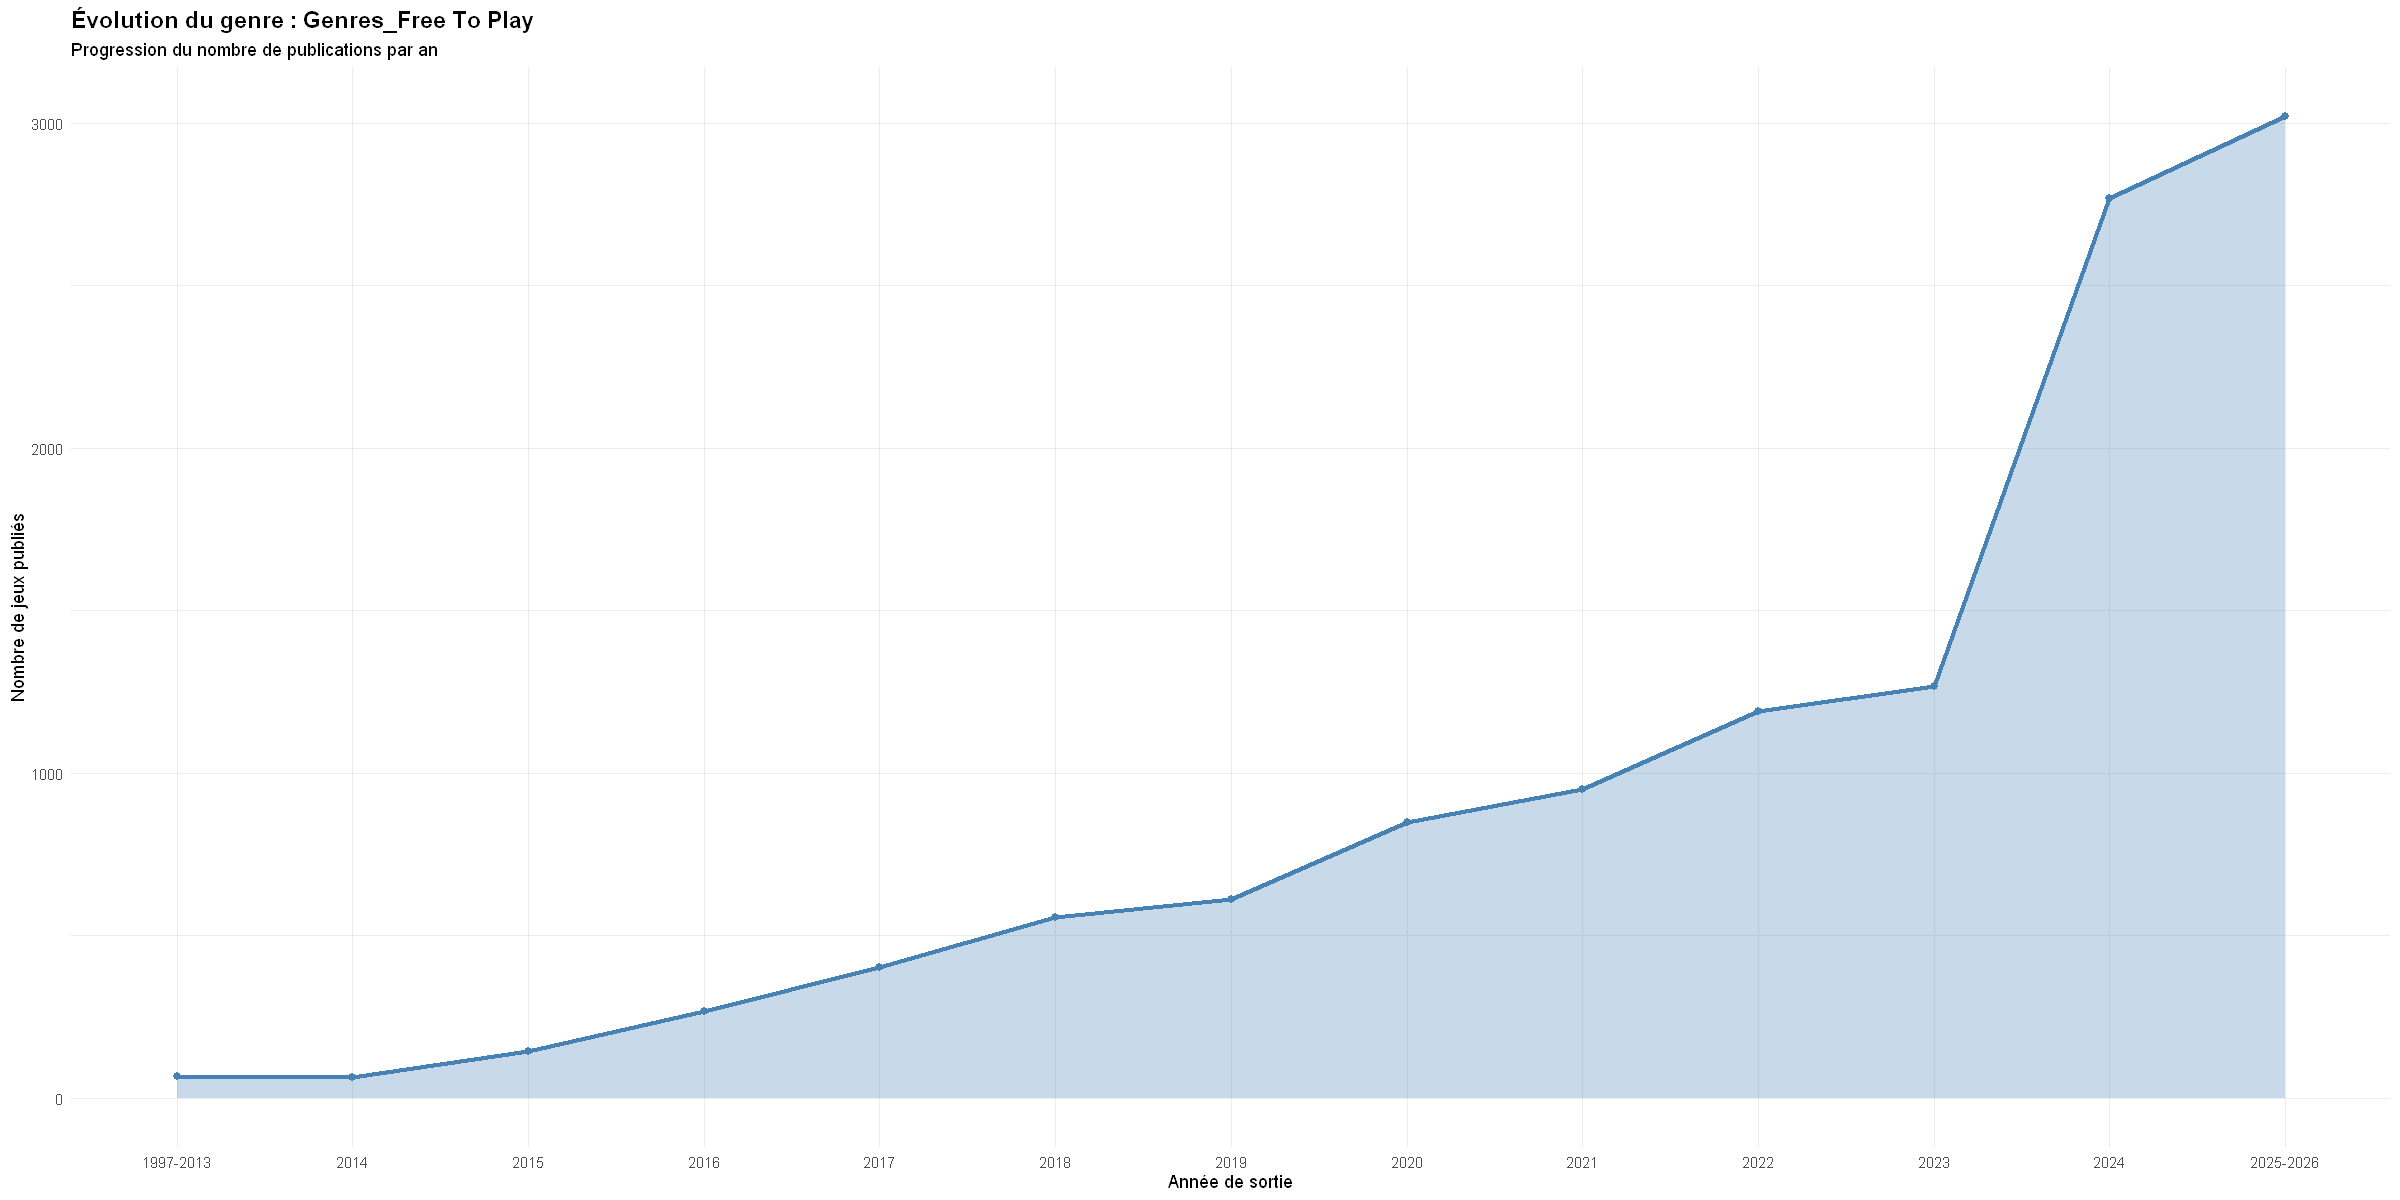

In [173]:
# 1. Choisir le genre que tu veux analyser
mon_genre <- "Genres_Free To Play" 

# 2. Filtrer les données uniquement pour ce genre
evolution_solo <- evolution_genres %>%
  filter(Genre == mon_genre)

# 3. Le graphique simple et efficace
ggplot(evolution_solo, aes(x = annee, y = Nombre_de_jeux, group = 1)) +
  # Une ligne bleue avec une zone ombrée en dessous pour faire "pro"
  geom_area(fill = "steelblue", alpha = 0.3) + 
  geom_line(color = "steelblue", linewidth = 1.2) +
  geom_point(color = "steelblue", size = 2) +
  theme_minimal() +
  labs(
    title = paste("Évolution du genre :", mon_genre),
    subtitle = "Progression du nombre de publications par an",
    x = "Année de sortie",
    y = "Nombre de jeux publiés"
  ) +
  theme(
    plot.title = element_text(face = "bold", size = 14)
  )

on remarque que les jeux gratuits ont exploser entre 2023 et 2024

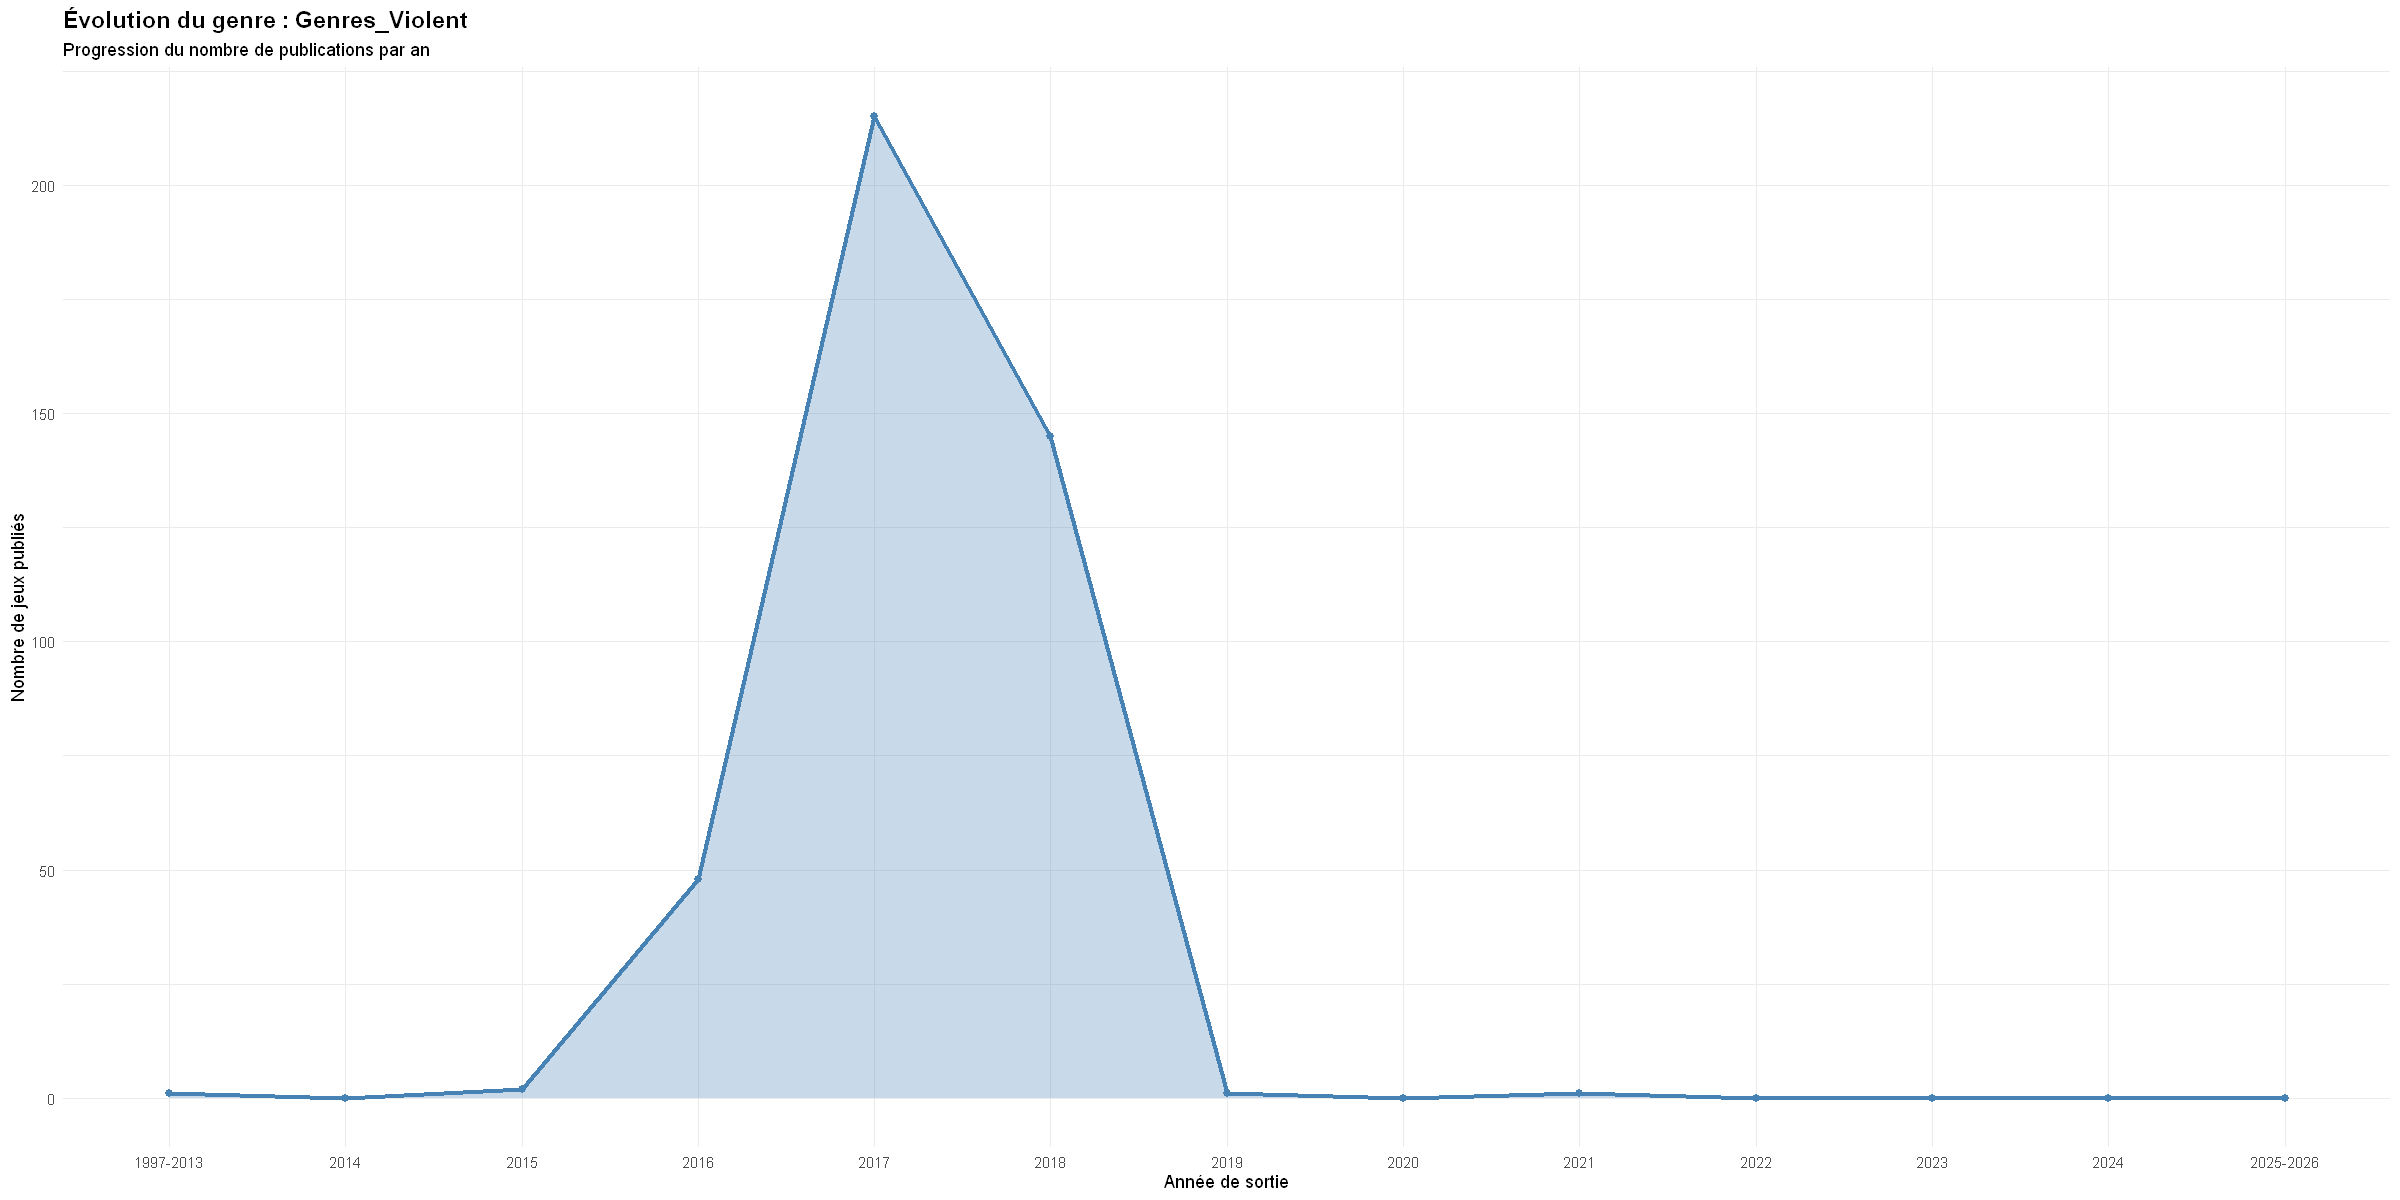

In [190]:
mon_genre <- "Genres_Violent" 

# 2. Filtrer les données uniquement pour ce genre
evolution_solo <- evolution_genres %>%
  filter(Genre == mon_genre)

# 3. Le graphique simple et efficace
ggplot(evolution_solo, aes(x = annee, y = Nombre_de_jeux, group = 1)) +
  # Une ligne bleue avec une zone ombrée en dessous pour faire "pro"
  geom_area(fill = "steelblue", alpha = 0.3) + 
  geom_line(color = "steelblue", linewidth = 1.2) +
  geom_point(color = "steelblue", size = 2) +
  theme_minimal() +
  labs(
    title = paste("Évolution du genre :", mon_genre),
    subtitle = "Progression du nombre de publications par an",
    x = "Année de sortie",
    y = "Nombre de jeux publiés"
  ) +
  theme(
    plot.title = element_text(face = "bold", size = 14)
      )

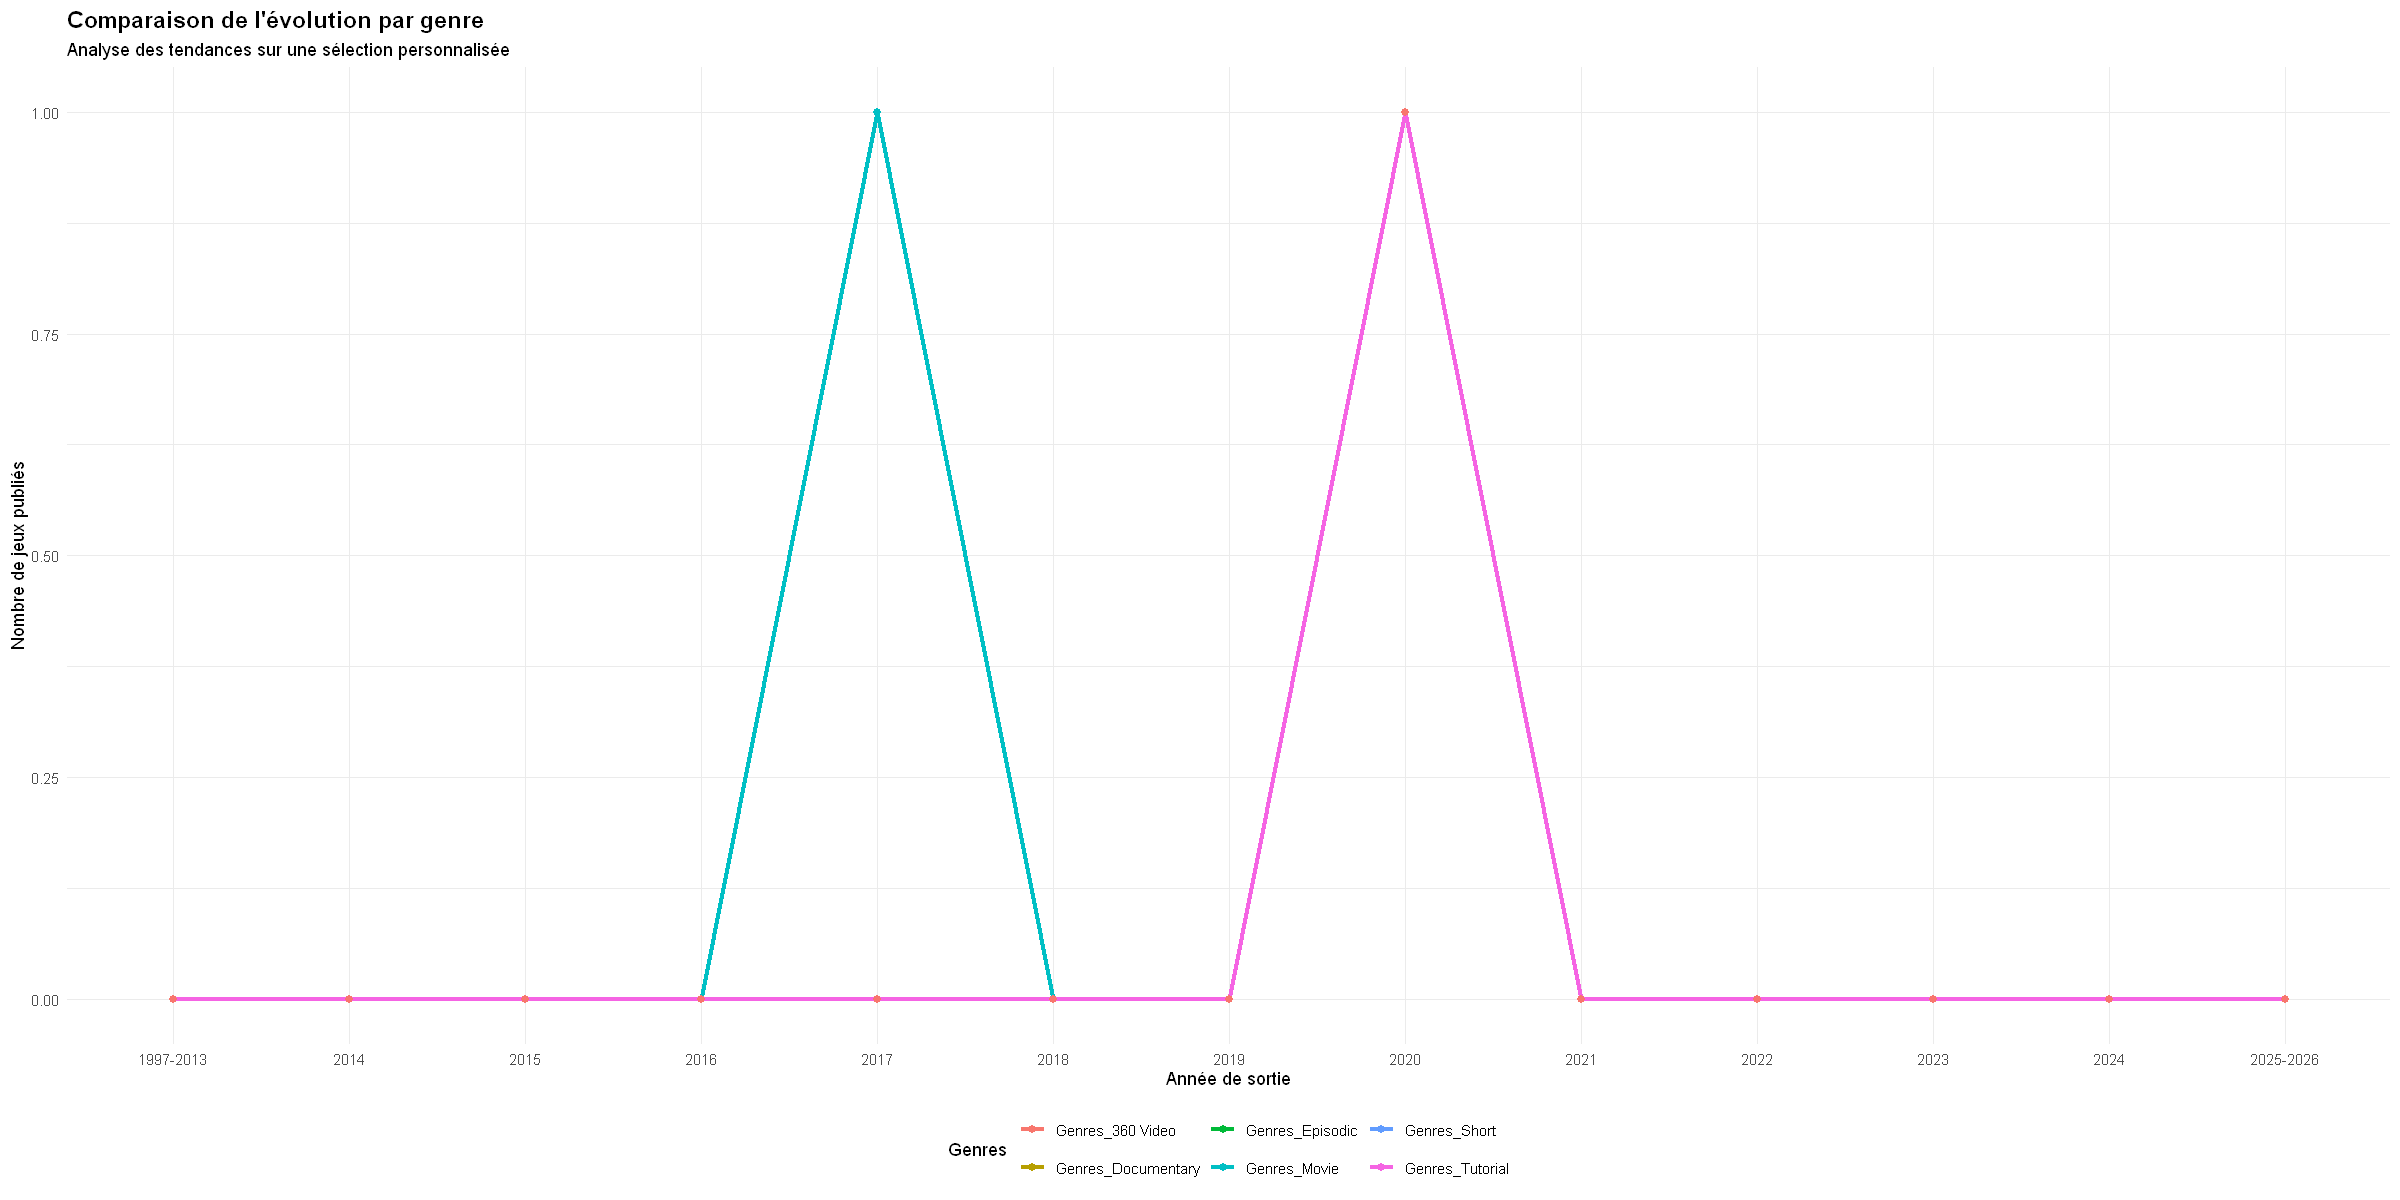

In [197]:
nbr=df_genres %>%
  summarise(across(everything(), sum)) %>%
  pivot_longer(everything(), names_to = "Genre", values_to = "Nombre")


df_genre_mca_etude <- df_genres %>%
  select(any_of(nbr$Genre))
df_analyse_temps_etude <- cbind(df_genre_mca_etude, annee = data_ready$Release.date)
evolution_genres_etude <- df_analyse_temps_etude %>%
  # On groupe par année
  group_by(annee) %>%
  # On fait la somme des 1 pour chaque genre
  summarise(across(everything(), sum)) %>%
  # On repasse en format long pour ggplot
  pivot_longer(cols = -annee, names_to = "Genre", values_to = "Nombre_de_jeux")


mon_genre <- c("Genres_Episodic","Genres_Documentary","Genres_Short","Genres_Movie","Genres_360 Video","Genres_Tutorial")
# 2. Filtrer les données uniquement pour ce genre
evolution_selection <- evolution_genres_etude%>%
  filter(Genre %in% mon_genre)

# 3. Le graphique comparatif
ggplot(evolution_selection, aes(x = annee, y = Nombre_de_jeux, color = Genre, group = Genre)) +
  geom_line(linewidth = 1.2) +
  geom_point(size = 2) +
  theme_minimal() +
  labs(
    title = "Comparaison de l'évolution par genre",
    subtitle = "Analyse des tendances sur une sélection personnalisée",
    x = "Année de sortie",
    y = "Nombre de jeux publiés",
    color = "Genres"
  ) +
  theme(
    legend.position = "bottom",
    plot.title = element_text(face = "bold", size = 14)
  )